In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker as mtick


In [2]:
def process_score_file(csv_file, top_metric='reassembly'):
    """
    Processes a list of CSV files to extract model scores, normalize them, 
    and organize them for heatmap plotting per generation strategy.

    Parameters:
    - csv_file: file paths to CSV score files.
    - max_metrics: list of metrics where higher is better.
    - min_metrics: list of metrics where lower is better.
    - zero_metrics: list of metrics where closer to zero is better.

    Returns:
    - dict of DataFrames: {generation_strategy: normalized DataFrame of scores}
    """

    # Dictionary to store results per generation strategy
    final_df = []

    df = pd.read_csv(csv_file)
    print('-' * 80)
    print(f"Processing {csv_file}")
    print('-' * 80)
    
    # Extract model name
    model_name = df["model_name"].iloc[0] if "model_name" in df.columns else csv_file
    
    # Identify all generation strategies based on column names
    strategies = set(col.split("_pred_n")[0] for col in df.columns if "_pred_n" in col)
    
    print(f"Processing {model_name} with {len(strategies)} strategies")
    
    for strategy in strategies:
        # Extract all relevant metric columns for this strategy
        strategy_columns = [col for col in df.columns if col.startswith(strategy + "_pred_n")]

        # Construct a set of all metrics that have "_pred_nN_" in their name
        num_preds = len(set(col.split("_pred_n")[1][0] for col in strategy_columns))

        metric_names = set(col.split("_pred_n")[1][2:] for col in strategy_columns)

        # Remove the "empty" metric name, associated to the prediction SMILES
        metric_names.discard("")
        
        if "search" in strategy or num_preds > 1:
            # Among the predictions for a given strategy, select the best one based on the top_metric argument
            best_pred = df[[f"{strategy}_pred_n{i}_{top_metric}" for i in range(num_preds)]].idxmax(axis=1)
            
            # Extract the index of the best prediction
            best_pred_idx = best_pred.apply(lambda x: int(x.split("_pred_n")[-1][0]))

            # Add the indexes to the DataFrame
            df['best_pred_idx'] = best_pred_idx

        for metric in metric_names:
            top_1 = df[strategy + "_pred_n0_" + metric]

            if num_preds > 1:
                top_5 = df.apply(lambda x: x[strategy + f"_pred_n{x['best_pred_idx']}_" + metric], axis=1)
            else:
                top_5 = None

            row = {
                'model_name': model_name,
                'strategy': strategy,
                'metric': metric,
                'top_n': 1,
                'fixed': True if 'fixed' in metric else False,
            }
            for reduce in ['mean', 'max', 'min', 'std']:
                row['reduce'] = reduce
                row['value'] = top_1.dropna().agg(reduce)
                final_df.append(row.copy())
            
            if top_5 is not None:
                row = {
                    'model_name': model_name,
                    'strategy': strategy,
                    'metric': metric,
                    'top_n': num_preds,
                    'fixed': True if 'fixed' in metric else False,
                }
                for reduce in ['mean', 'max', 'min', 'std']:
                    row['reduce'] = reduce
                    row['value'] = top_5.dropna().agg(reduce)
                    final_df.append(row.copy())

    return pd.DataFrame(final_df)


# Get all files in the logs directory that ends with "-scores.csv"
csv_files = [f"../logs/{file}" for file in os.listdir("../logs") if file.endswith("-scores.csv")]

score_df = pd.DataFrame()

# Process the files
for csv_file in tqdm(csv_files, desc="Processing files"):
    processed_score_file = csv_file.replace("-scores.csv", "-processed_scores.csv")
    if not os.path.exists(processed_score_file):
        df = process_score_file(csv_file)
        df.to_csv(processed_score_file, index=False)
    else:
        df = pd.read_csv(processed_score_file).reset_index(drop=True)

    score_df = pd.concat([score_df, df], ignore_index=True)

score_df

Processing files: 100%|██████████| 26/26 [00:00<00:00, 85.40it/s]


,model_name,strategy,metric,top_n,fixed,reduce,value
0,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,diverse_beam_search_decoding,e3_graph_edit_distance,1,False,mean,inf
1,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,diverse_beam_search_decoding,e3_graph_edit_distance,1,False,max,inf
2,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,diverse_beam_search_decoding,e3_graph_edit_distance,1,False,min,0.0
3,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,diverse_beam_search_decoding,e3_graph_edit_distance,1,False,std,NaN
4,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,diverse_beam_search_decoding,e3_graph_edit_distance,5,False,mean,inf
...,...,...,...,...,...,...,...
63435,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,beam_search_decoding,e3_heavy_atoms_difference_norm_fixed,1,True,std,0.14189948429094654
63436,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,beam_search_decoding,e3_heavy_atoms_difference_norm_fixed,5,True,mean,0.9794019054340155
63437,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,beam_search_decoding,e3_heavy_atoms_difference_norm_fixed,5,True,max,1.0
63438,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,beam_search_decoding,e3_heavy_atoms_difference_norm_fixed,5,True,min,0.0


## Compare Models

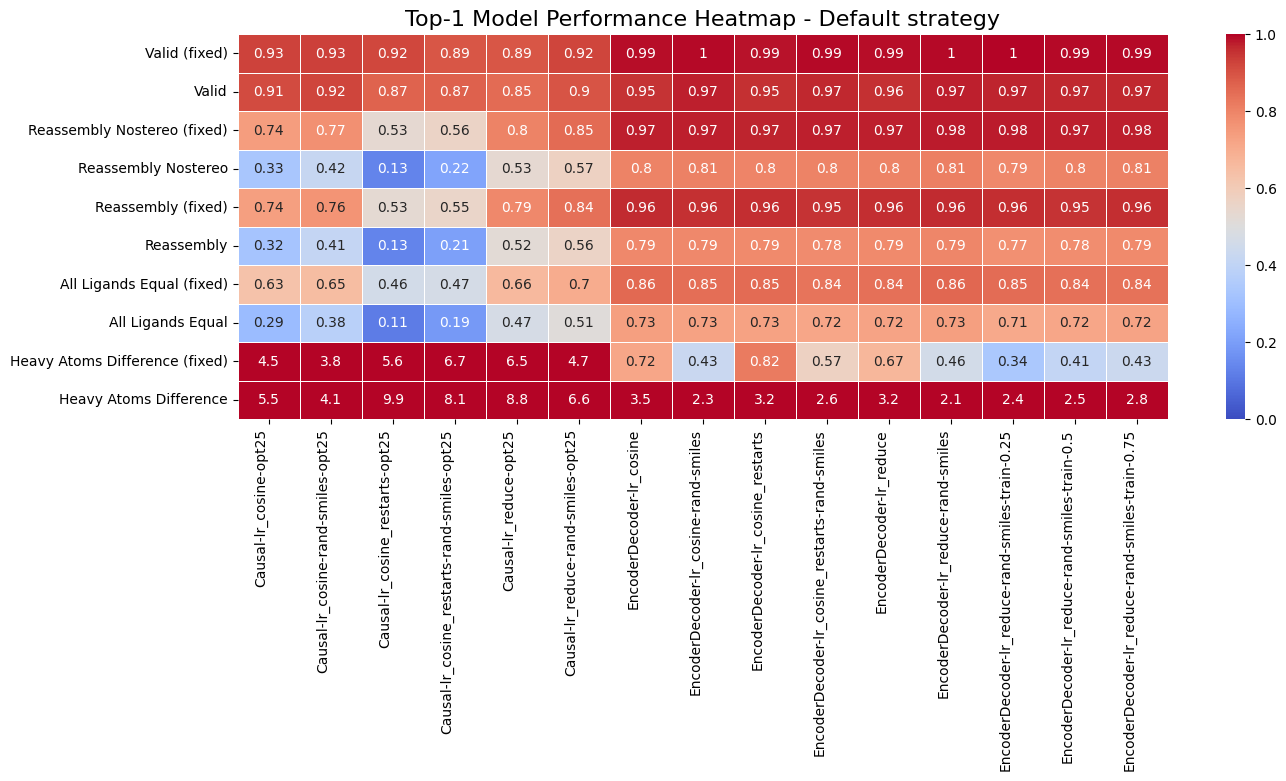

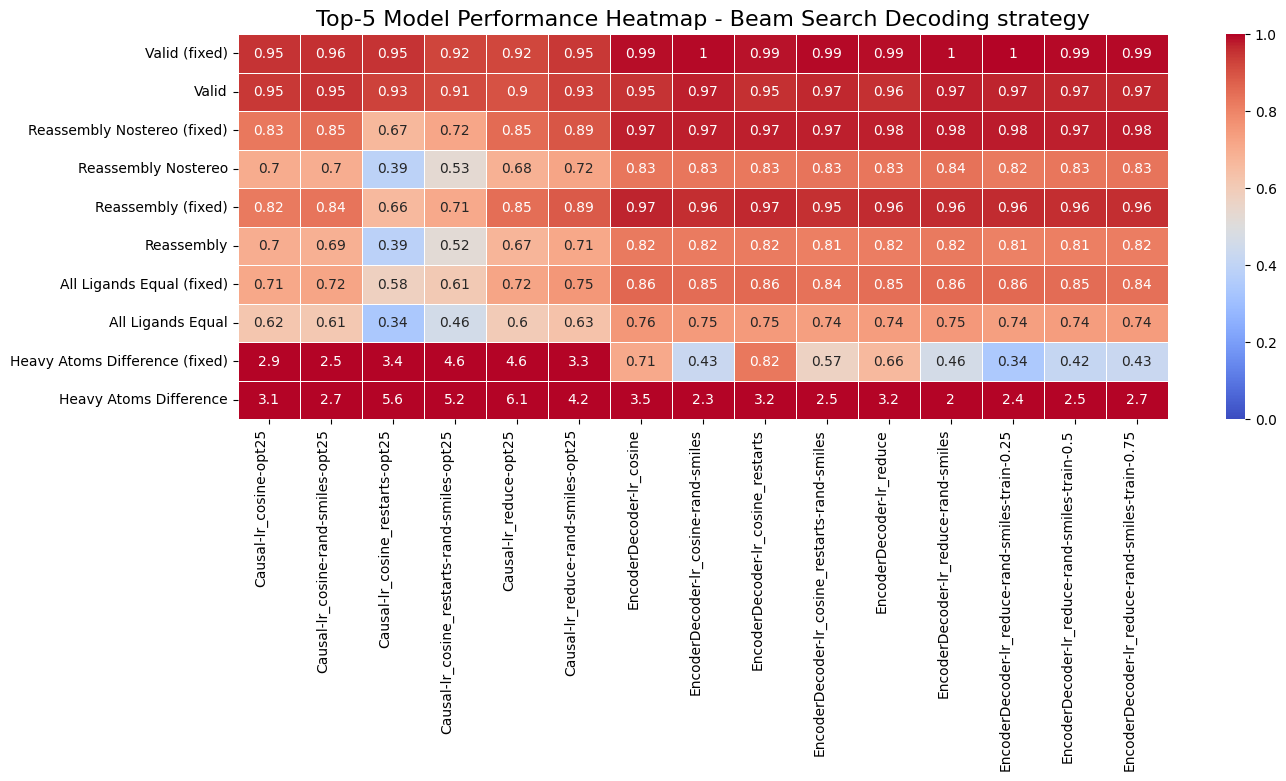

In [4]:
def plot_model_performance_heatmap_from_df(df, title="Model Performance Heatmap", figsize=(20, 20)):
    """
    Plots a heatmap to compare models based on multiple metrics using a DataFrame.

    Parameters:
    - df: Pandas DataFrame where rows are metrics, columns are models, and values are scores.
    - title: str, title of the plot

    Example of expected input:
        index (metrics) → ["valid", "reassembly", "metric3"]
        columns (models) → ["M1", "M2", "M3"]
    """
    # Ensure all data in the DataFrame is numeric
    df = df.apply(pd.to_numeric, errors='coerce')

    plt.figure(figsize=figsize)
    sns.heatmap(df, annot=True, cmap="coolwarm", vmin=0, vmax=1, linewidths=0.5, cbar=True)

    # Labels and Title
    plt.xlabel("Models", fontsize=14)
    plt.ylabel("Metrics", fontsize=14)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=90, ha="right")
    plt.yticks(rotation=0)
    plt.xlabel(None)
    plt.ylabel(None)

    # Show the plot
    plt.show()


import pandas as pd

# Create a DataFrame in the correct format
df_scores = pd.DataFrame({
    "M1": [0.9, 0.95, 0.92],
    "M2": [0.65, 0.78, 0.81],
    "M3": [0.08, 0.80, 0.76]
}, index=["valid", "reassembly", "metric3"])

# display(df_scores)
# # Call the plotting function
# plot_model_performance_heatmap_from_df(df_scores)

# Re-arrenge the DataFrame to have the metrics as rows and the models as columns
for strategy in score_df['strategy'].unique():
    if strategy != 'default':
        continue
    # Isolate the generation strategy
    df = score_df[score_df['strategy'] == strategy].copy()

    # Isolate the Top-1 and Mean values
    df = df[df['reduce'] == 'mean']
    df = df[df['top_n'] == 1]
    # df = df[df['fixed'] == False]
    
    # Only include metrics: valid, reassembly, all_ligands_equal, heavy_atoms_difference
    metrics_to_plot = ['valid', 'reassembly', 'reassembly_nostereo', 'all_ligands_equal', 'heavy_atoms_difference']
    metrics_to_plot += [f"{metric}_fixed" for metric in metrics_to_plot]
    df = df[df['metric'].isin(metrics_to_plot)]

    df['metric'] = df['metric'].str.split("_").str.join(" ").str.title()
    df['metric'] = df['metric'].str.replace("Fixed", "(fixed)")

    df = df[['model_name', 'metric', 'value']]
    
    # Remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-" from the model_name
    df['model_name'] = df['model_name'].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "", regex=False)

    # Rename only the model name "EncoderDecoder-lr_reduce-opt25" to "EncoderDecoder-lr_reduce"
    df['model_name'] = df['model_name'].str.replace("EncoderDecoder-lr_reduce-opt25-rand-smiles", "EncoderDecoder-opt25", regex=False)
    df['model_name'] = df['model_name'].str.replace("EncoderDecoder-lr_reduce-opt25", "EncoderDecoder-lr_reduce", regex=False)

    # Remove entries with model_name containing both "EncoderDecoder" and "-opt25"
    df = df[~df['model_name'].str.contains("EncoderDecoder") | ~df['model_name'].str.contains("-opt25")]
    # Remove all model_name containing "e3-wh-labels"
    df = df[~df['model_name'].str.contains("e3-wh-labels")]

    # Melt the dataframe so that the metrics are in the rows and the unique models are in the columns
    df = df.pivot(index='metric', columns='model_name', values='value')

    # Drop rows with NaN and inf values
    df = df.infer_objects(copy=False).replace([float('inf'), -float('inf')], float('nan'))
    df = df.dropna()

    # Reorder the index, i.e., metric, by putting all metrics with "Heavy Atoms" at the end
    df = df.reindex(sorted(df.index, key=lambda x: (x.split(" ")[0] != "Heavy", x), reverse=True), axis=0)
    
    plot_model_performance_heatmap_from_df(df, title=f"Top-1 Model Performance Heatmap - {strategy.title()} strategy", figsize=(15, 5))
    

for strategy in score_df['strategy'].unique():
    if strategy != 'beam_search_decoding':
        continue
    # Isolate the generation strategy
    df = score_df[score_df['strategy'] == strategy].copy()

    # Isolate the Top-1 and Mean values
    df = df[df['reduce'] == 'mean']
    df = df[df['top_n'] == 5]
    # df = df[df['fixed'] == False]

    # Only include metrics: valid, reassembly, all_ligands_equal, heavy_atoms_difference
    metrics_to_plot = ['valid', 'reassembly', 'reassembly_nostereo', 'all_ligands_equal', 'heavy_atoms_difference']
    metrics_to_plot += [f"{metric}_fixed" for metric in metrics_to_plot]
    df = df[df['metric'].isin(metrics_to_plot)]

    df['metric'] = df['metric'].str.split("_").str.join(" ").str.title()
    df['metric'] = df['metric'].str.replace("Fixed", "(fixed)")

    df = df[['model_name', 'metric', 'value']]
    
    # Remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-" from the model_name
    df['model_name'] = df['model_name'].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")
    
    # Rename only the model name "EncoderDecoder-lr_reduce-opt25" to "EncoderDecoder-lr_reduce"
    df['model_name'] = df['model_name'].str.replace("EncoderDecoder-lr_reduce-opt25-rand-smiles", "EncoderDecoder-opt25", regex=False)
    df['model_name'] = df['model_name'].str.replace("EncoderDecoder-lr_reduce-opt25", "EncoderDecoder-lr_reduce", regex=False)
 
    # Remove entries with model_name containing both "EncoderDecoder" and "-opt25"
    df = df[~df['model_name'].str.contains("EncoderDecoder") | ~df['model_name'].str.contains("-opt25")]
    # Remove all model_name containing "e3-wh-labels"
    df = df[~df['model_name'].str.contains("e3-wh-labels")]
    
    # Melt the dataframe so that the metrics are in the rows and the unique models are in the columns
    df = df.pivot(index='metric', columns='model_name', values='value')

    # Drop rows with NaN and inf values
    df = df.infer_objects(copy=False).replace([float('inf'), -float('inf')], float('nan'))
    df = df.dropna()
    
    # Reorder the index, i.e., metric, by putting all metrics with "Heavy Atoms" at the end
    df = df.reindex(sorted(df.index, key=lambda x: (x.split(" ")[0] != "Heavy", x), reverse=True), axis=0)
    
    plot_model_performance_heatmap_from_df(df, title=f"Top-5 Model Performance Heatmap - {' '.join(strategy.split('_')).title()} strategy", figsize=(15, 5))

## Compare Generation Strategies

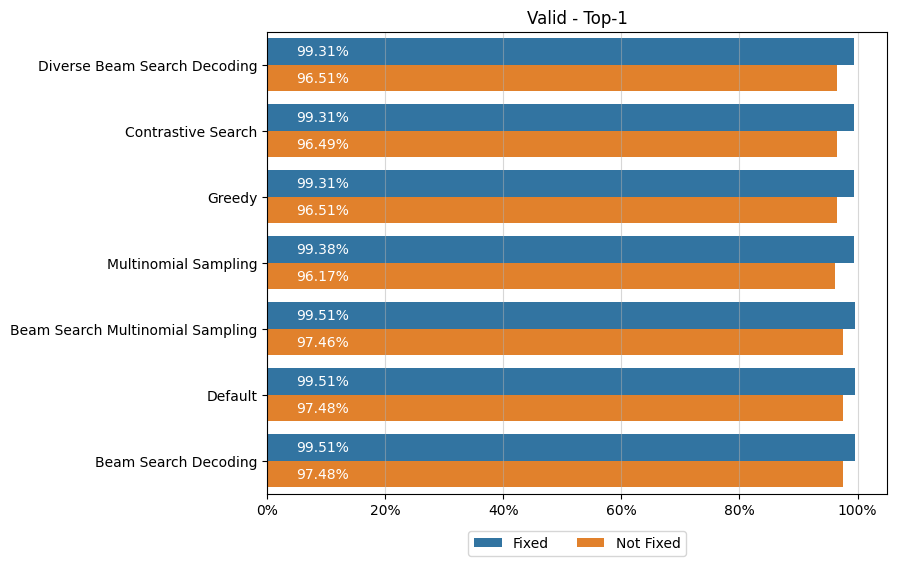

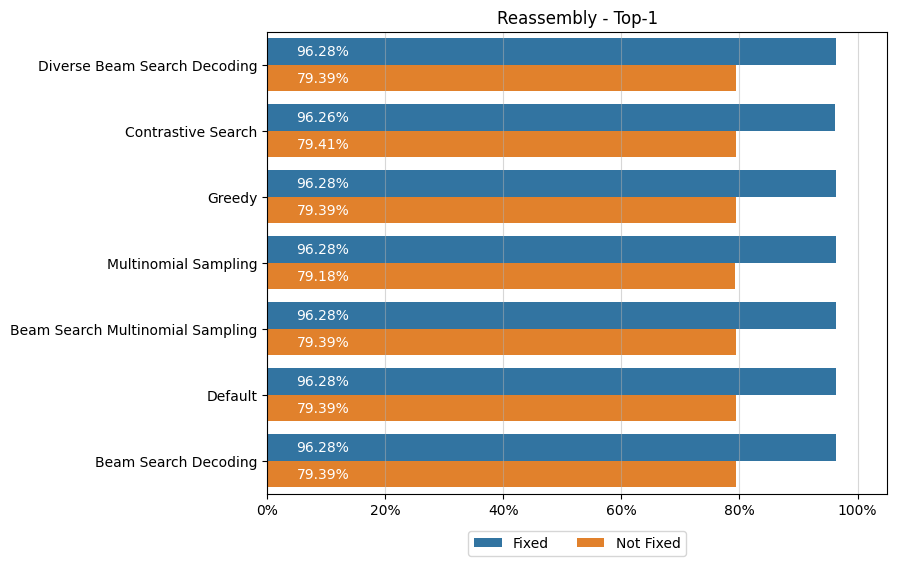

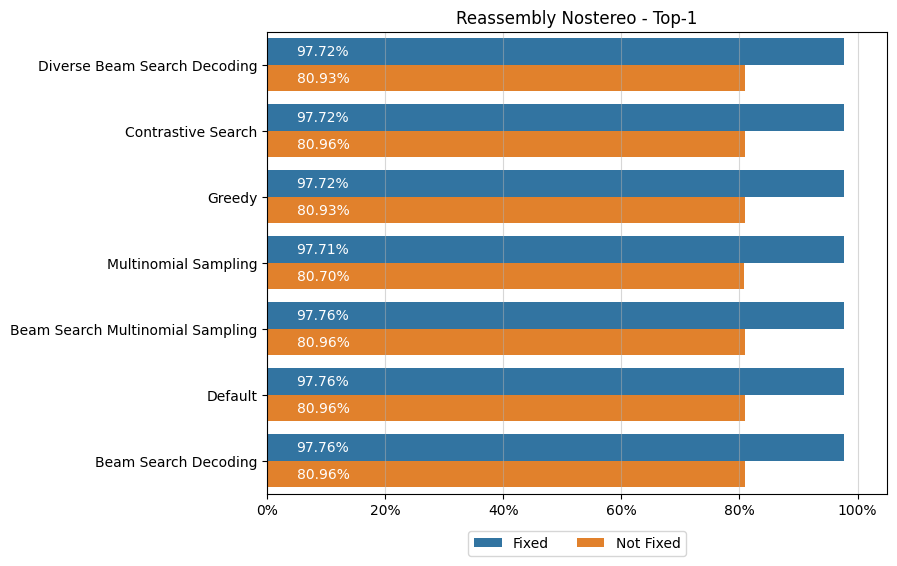

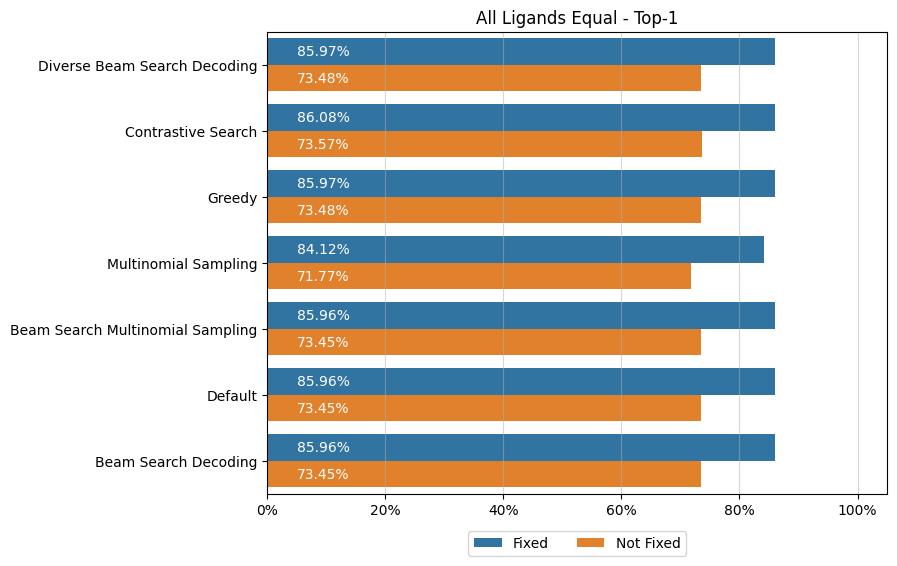

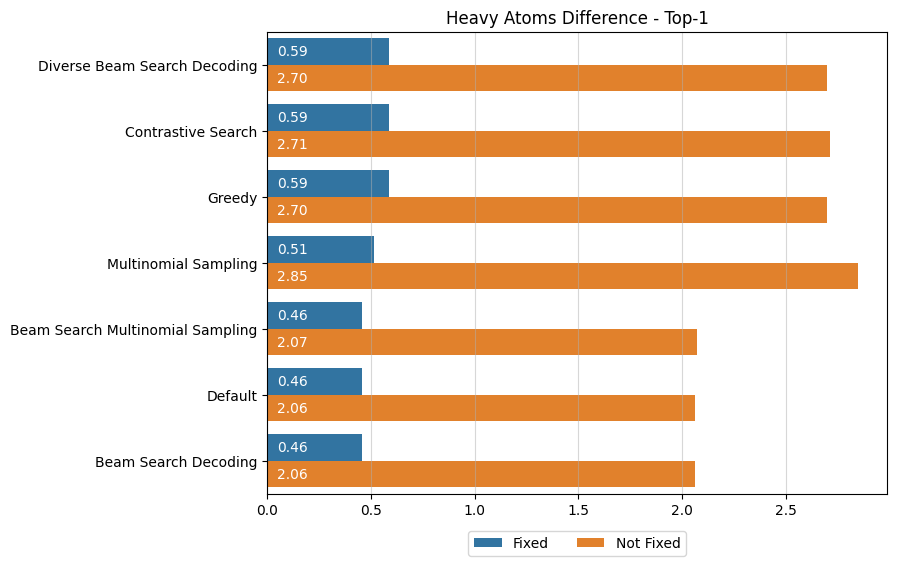

In [5]:
for metric in ['valid', 'reassembly', 'reassembly_nostereo', 'all_ligands_equal', 'heavy_atoms_difference']:
    # Isolate the best model
    df = score_df[score_df['model_name'].str.contains("-EncoderDecoder-lr_reduce", regex=False)].copy()
    df = df[~df['model_name'].str.contains("-opt25", regex=False)]
    df['model_name'] = df['model_name'].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")
    # Select only the one equal to "EncoderDecoder-lr_reduce-rand-smiles"
    df = df[df['model_name'] == "EncoderDecoder-lr_reduce-rand-smiles"]
    
    # Isolate the generation strategy
    df = df[(df['metric'] == metric) | (df['metric'] == metric + "_fixed")]
    df = df[df['reduce'] == 'mean']
    df = df[df['top_n'] == 1]
    df['value'] = df['value'].astype(float)

    # Title the strategies
    df['strategy'] = df['strategy'].str.split("_").str.join(" ").str.title()
    # Rename the "fixed" column from True/False to "Fixed"/"Not Fixed"
    df['fixed'] = df['fixed'].replace({True: "Fixed", False: "Not Fixed"})

    # display(df)
    
    # Bar plot the "value" on the x-axis, "strategy" on the y-axis and "fixed" as hue
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(data=df, y='strategy', x='value', hue='fixed')
    metric_title = " ".join(metric.split("_")).title()
    plt.title(f"{metric_title} - Top-1")
    plt.ylabel("")
    plt.xlabel("")
    plt.grid(axis='x', alpha=0.5)
    
    # Draw the values on the bars at the center
    for p in ax.patches:
        if p.get_width() == 0:
            continue
        if metric != 'heavy_atoms_difference':
            text = f"{p.get_width():.2%}"
        else:
            text = f"{p.get_width():.2f}"
        ax.annotate(text, (0.05, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=10, color='white')
    
    # If metric is not "heavy_atoms_difference", set the x-axis to be a percentage
    if metric != 'heavy_atoms_difference':
        plt.xlim(0, 1.05)
        plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
    # Place the legend outside the plot, on the bottom with two columns. Then remove the title
    plt.legend(title=None, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    plt.show()

## Metrics for Best Model

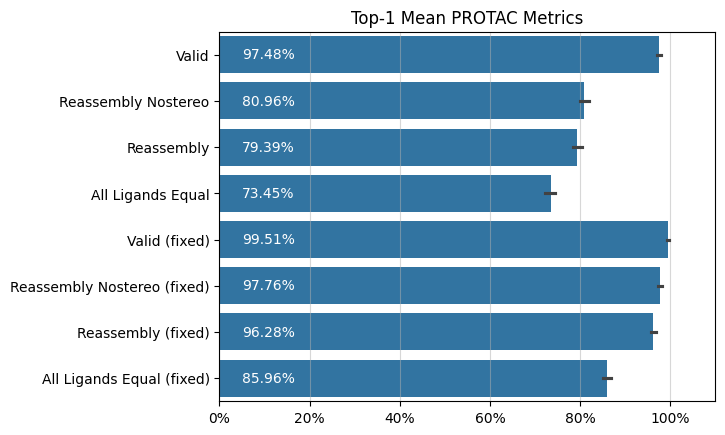

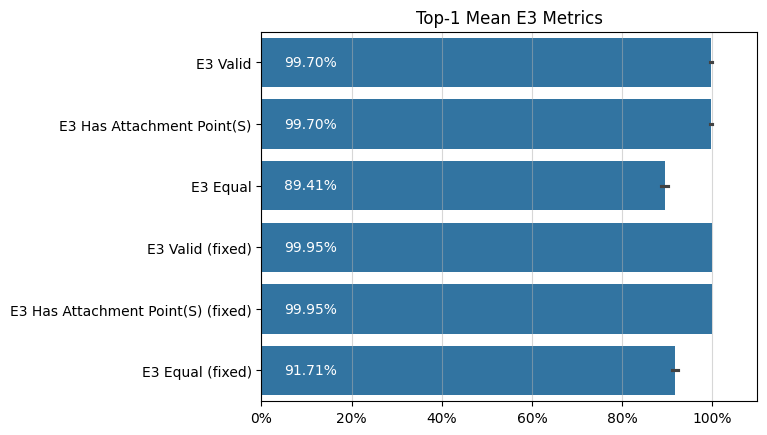

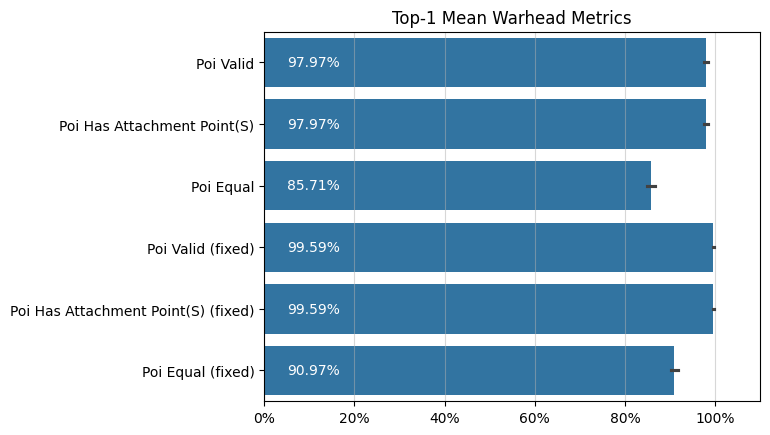

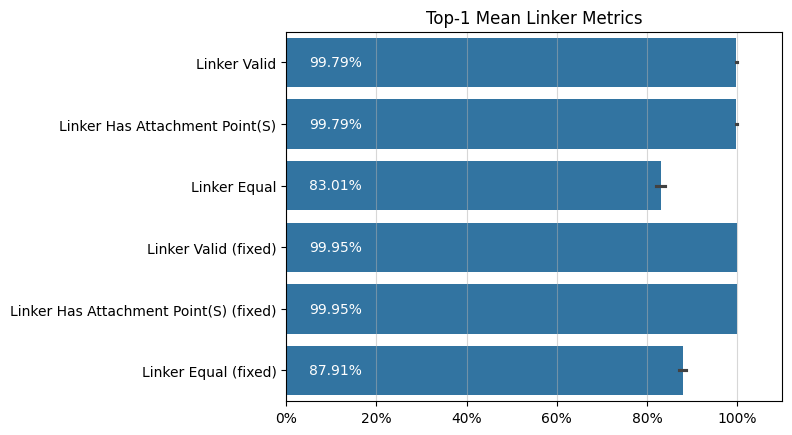

In [ ]:
for ligand in ['protac', 'e3', 'poi', 'linker']:
    csv_file = "../logs/PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles-scores.csv"
    df = pd.read_csv(csv_file)

    # Get all columns that start with "default_pred_n"
    columns = [col for col in df.columns if col.startswith("default_pred_n")]

    df = df[columns]

    # Remove the "default_pred_n0_" from the column names
    df.columns = df.columns.str.replace("default_pred_n0_", "")

    # Filter columns with "heavy_atoms_difference" and "num_fragments" and "has_three_substructures" and "is_fixed"
    df = df[df.columns[~df.columns.str.contains("heavy_atoms_difference|num_fragments|has_three_substructures|is_fixed|graph")]]

    # Filter all columns that do not contain "e3" or "poi" or "linker"
    if ligand == 'protac':
        df = df[df.columns[~df.columns.str.contains("e3|poi|linker")]]
        title = "Top-1 Mean PROTAC Metrics"
    elif ligand == 'e3':
        df = df[df.columns[df.columns.str.contains("e3")]]
        title = "Top-1 Mean E3 Metrics"
    elif ligand == 'poi':
        df = df[df.columns[df.columns.str.contains("poi_")]]
        title = "Top-1 Mean Warhead Metrics"
    elif ligand == 'linker':
        df = df[df.columns[df.columns.str.contains("linker")]]
        title = "Top-1 Mean Linker Metrics"

    # Remove the "default_pred_n0" column
    df = df[df.columns[~df.columns.str.contains("default_pred_n0")]]

    # Title case the column names
    df.columns = df.columns.str.split("_").str.join(" ").str.title()
    # Remove the "fixed" from the column names
    df.columns = df.columns.str.replace("Fixed", "(fixed)")
    
    # Sort columns from non containing "(fixed)" first and then the ones containing "(fixed)"
    df = df.reindex(sorted(df.columns, key=lambda x: (x.split(" ")[-1] != "(fixed)", x), reverse=True), axis=1)

    # First convert boolean values to numeric (True = 1, False = 0)
    df = df.astype(float)

    # Bar-plot the values of the DataFrame
    # plt.figure(figsize=(20, 10))
    ax = sns.barplot(data=df, orient='h', errorbar='ci', color='C0')
    plt.xlabel("")
    plt.ylabel("")
    plt.title(title)
    plt.xlim(0, 1.1)
    plt.grid(axis='x', alpha=0.5)
    # For each bar in the plot, add the value at x=0.5, use ax.patches to get the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.2%}", (0.05, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=10, color='white')

    # Convert the x-axis to percentage
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
    plt.show()

In [ ]:
score_df['strategy'].unique()

array(['diverse_beam_search_decoding', 'contrastive_search', 'greedy',
       'multinomial_sampling', 'beam_search_multinomial_sampling',
       'default', 'beam_search_decoding'], dtype=object)

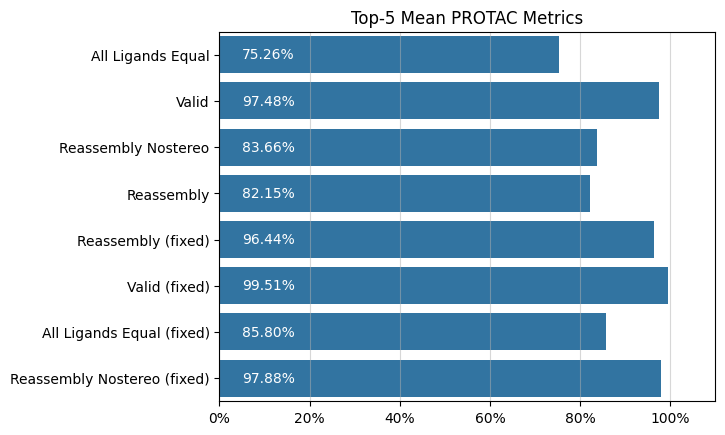

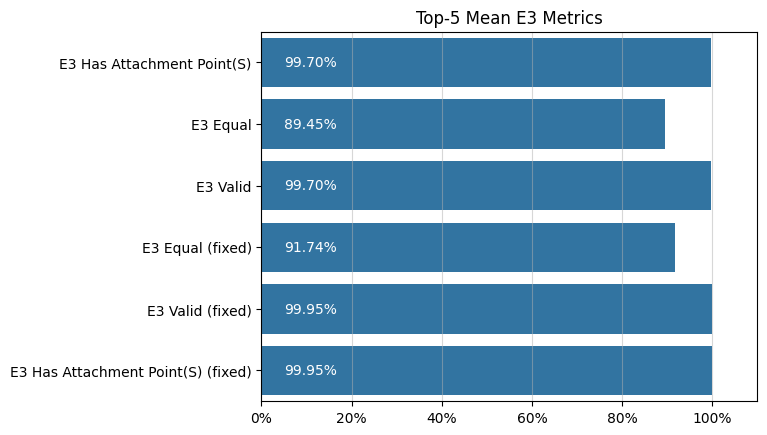

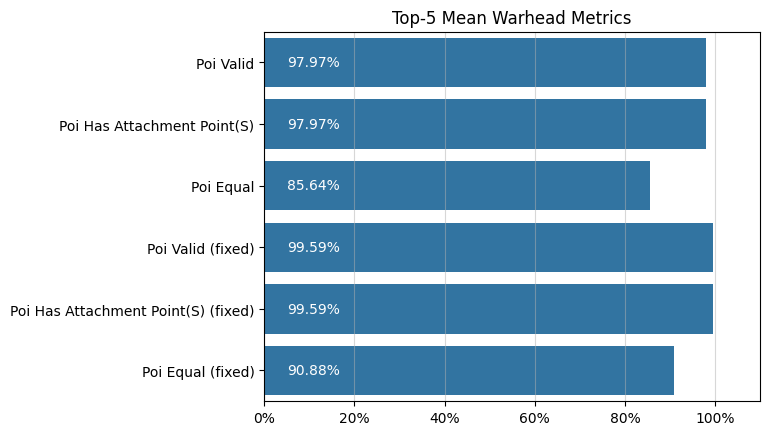

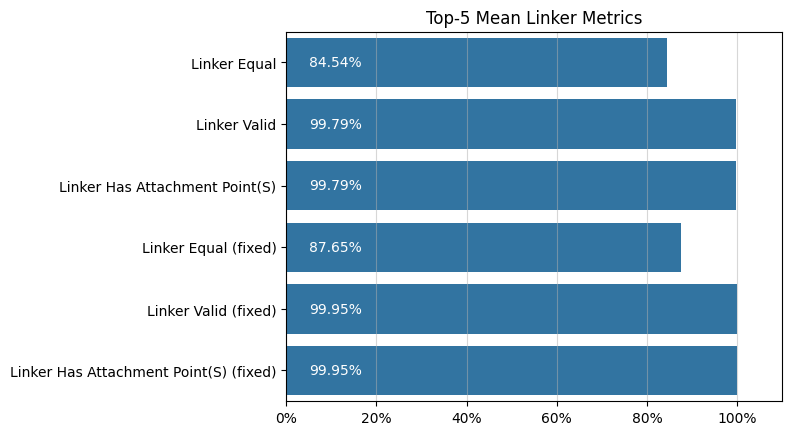

In [ ]:
best_strategy = 'beam_search_decoding'

for ligand in ['protac', 'e3', 'poi', 'linker']:
    df = score_df[score_df['strategy'] == best_strategy].copy()
    df = df[df['model_name'].str.contains("EncoderDecoder-lr_reduce-rand-smiles", regex=False)]
    df = df[~df['model_name'].str.contains("-train", regex=False)]
    df = df[df['reduce'] == 'mean']
    df = df[~df['metric'].str.contains("graph", regex=False)]
    df = df[~df['metric'].str.contains("heavy_atoms", regex=False)]
    df = df[~df['metric'].str.contains("is_fixed", regex=False)]
    df = df[~df['metric'].str.contains("num_fragments", regex=False)]
    df = df[~df['metric'].str.contains("has_three_substructures", regex=False)]
    df = df[~df['metric'].str.contains("has_all_attachment_points", regex=False)]
    df = df[df['top_n'] == 5]
    
    if ligand == 'protac':
        df = df[~(df['metric'].str.contains("e3_") | df['metric'].str.contains("poi_") | df['metric'].str.contains("linker"))]
        title = "Top-5 Mean PROTAC Metrics"
    elif ligand == 'e3':
        df = df[df['metric'].str.contains("e3_")]
        title = "Top-5 Mean E3 Metrics"
    elif ligand == 'poi':
        df = df[df['metric'].str.contains("poi_")]
        title = "Top-5 Mean Warhead Metrics"
    elif ligand == 'linker':
        df = df[df['metric'].str.contains("linker_")]
        title = "Top-5 Mean Linker Metrics"
        
    # Title case the metric names
    df['metric'] = df['metric'].str.split("_").str.join(" ").str.title()
    # Replace the "fixed" from the metric names
    df['metric'] = df['metric'].str.replace("Fixed", "(fixed)")
    
    # Convert value column to numeric
    df['value'] = df['value'].astype(float)

    # Sort the metrics from non containing "(fixed)" first and then the ones containing "(fixed)"
    df = df.sort_values(by=['metric'], key=lambda x: x.str.contains("(fixed)", regex=False), ascending=True)

    # Bar-plot the values of the DataFrame
    # plt.figure(figsize=(20, 10))
    ax = sns.barplot(data=df, orient='h', color='C0', x='value', y='metric')
    plt.xlabel("")
    plt.ylabel("")
    plt.title(title)
    plt.xlim(0, 1.1)
    plt.grid(axis='x', alpha=0.5)
    # For each bar in the plot, add the value at x=0.5, use ax.patches to get the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.2%}", (0.05, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=10, color='white')

    # Convert the x-axis to percentage
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
    plt.show()

    # display(df)

## Data Efficiency

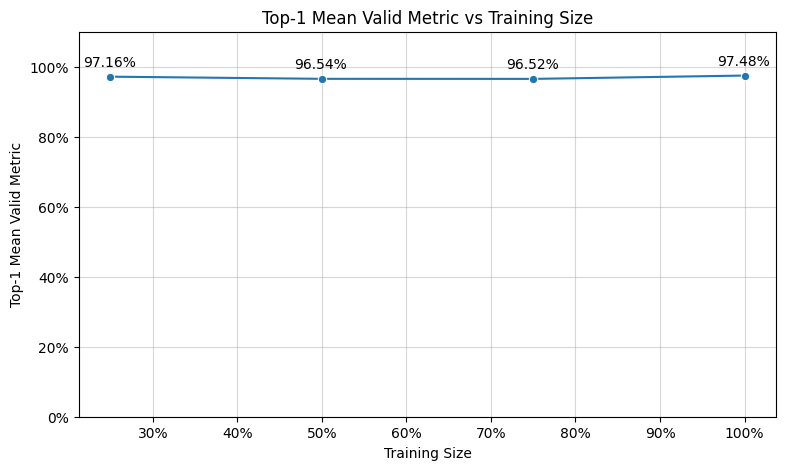

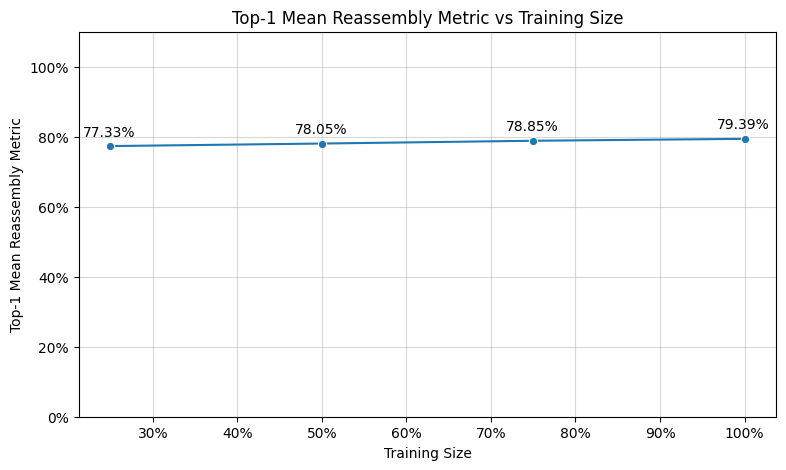

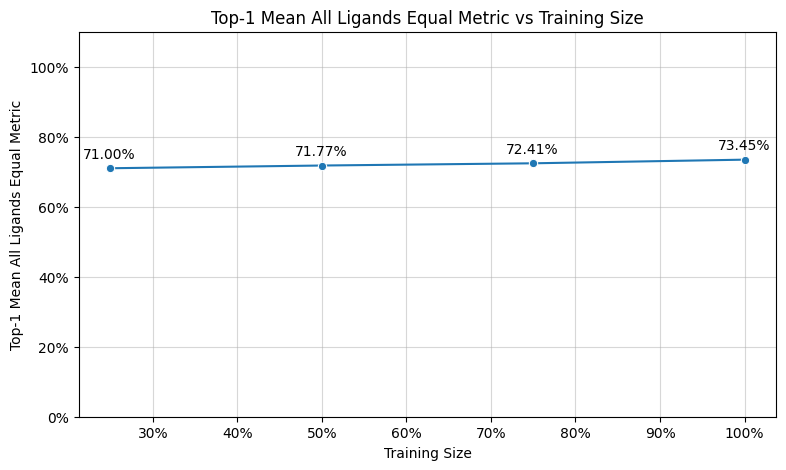

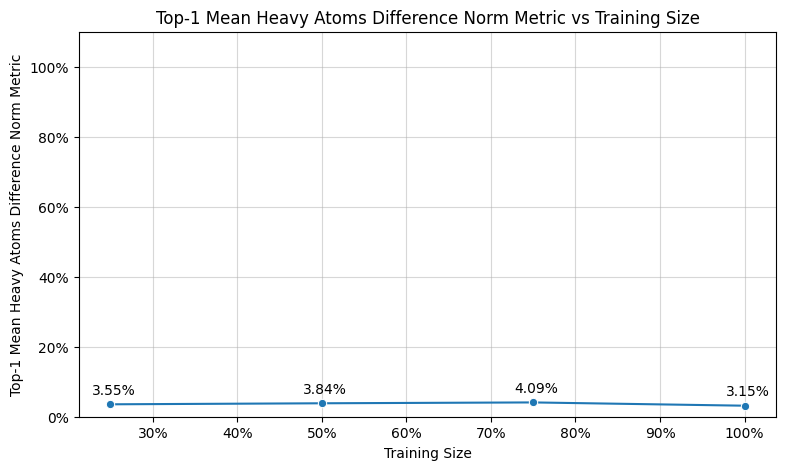

In [ ]:
for metric in ['valid', 'reassembly', 'all_ligands_equal', 'heavy_atoms_difference_norm']:

    df = score_df[score_df['model_name'].str.contains("-EncoderDecoder-lr_reduce", regex=False)].copy()
    df = df[~df['model_name'].str.contains("-opt25", regex=False)]

    # Remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-" from the model_name
    df['model_name'] = df['model_name'].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")

    # According to the model_name, add a new column with the training size, if empty, set it to 1
    # Example: array(['EncoderDecoder-lr_reduce-rand-smiles-train-0.5',
    #    'EncoderDecoder-lr_reduce-rand-smiles',
    df['training_size'] = df['model_name'].str.extract(r"(\d\.\d+)").astype(float)
    df['training_size'] = df['training_size'].fillna(1.0)

    # Plot the curve of the top-1 mean reassembly metric of the y-axis, with the training size on the x-axis
    df = df[df['metric'] == metric]
    df = df[df['reduce'] == 'mean']
    df = df[df['top_n'] == 1]
    df = df[df['strategy'] == 'default']

    df = df.infer_objects(copy=False).replace([float('inf'), -float('inf')], float('nan'))
    df = df.dropna()

    df = df.apply(pd.to_numeric, errors='coerce')

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=df, x='training_size', y='value', marker='o')

    metric_name = " ".join(metric.split("_")).title()
    plt.title(f"Top-1 Mean {metric_name} Metric vs Training Size")
    plt.xlabel("Training Size")
    plt.ylabel(f"Top-1 Mean {metric_name} Metric")
    plt.ylim(0, 1.1)
    plt.grid(axis='both', alpha=0.5)
    # Convert the x-axis and y-axis to percentage
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
    # Add the metric values only on the plot close to the marker points
    for i, row in df.iterrows():
        plt.text(row['training_size'] + 0.03, row['value'] + 0.02, f"{row['value']:.2%}", ha='right', va='bottom')
    plt.show()

## Venn-Diagrams of Failed Predictions

In [ ]:
import datasets
from typing import Optional

def split_prediction(
        pred: str,
        poi_attachment_id: int = 1,
        e3_attachment_id: int = 2,
) -> Optional[dict[str, str]]:
    """ Split a PROTAC SMILES prediction into its three substructures.

    Args:
        pred (str): The SMILES of the PROTAC molecule.
        poi_attachment_id (int): The attachment point ID for the POI substructure.
        e3_attachment_id (int): The attachment point ID for the E3 substructure.

    Returns:
        dict[str, str] | None: A dictionary (with keys: 'e3', 'linker', 'poi') containing the SMILES notations for the POI, linker, and E3 substructures, or None if the prediction is invalid
    """
    ret = {k: None for k in ['poi', 'linker', 'e3']}
    if pred is None:
        return ret

    ligands = pred.split('.')
    # if len(ligands) != 3:
    #     return ret

    for ligand in ligands:
        if f'[*:{poi_attachment_id}]' in ligand and f'[*:{e3_attachment_id}]' not in ligand:
            ret['poi'] = ligand
        elif f'[*:{e3_attachment_id}]' in ligand and f'[*:{poi_attachment_id}]' not in ligand:
            ret['e3'] = ligand
        elif f'[*:{poi_attachment_id}]' in ligand and f'[*:{e3_attachment_id}]' in ligand:
            ret['linker'] = ligand
    return ret

# def split_row(row):
#     ret = row.to_dict()
#     label_smiles = row['labels']
#     split = split_prediction(label_smiles)
#     ret['e3_label'] = split['e3']
#     ret['linker_label'] = split['linker']
#     ret['poi_label'] = split['poi']
#     return ret

def split_row(sample):
    label_smiles = sample['labels']
    split = split_prediction(label_smiles)
    sample['e3_label'] = split['e3']
    sample['linker_label'] = split['linker']
    sample['poi_label'] = split['poi']
    return sample


train_df = datasets.load_dataset("ailab-bio/PROTAC-Splitter-Dataset", "clustered", split="train")
train_df = train_df.map(split_row, num_proc=8).to_pandas()
train_df

Map (num_proc=8):   0%|          | 0/1297604 [00:00<?, ? examples/s]

,text,labels,e3_label,linker_label,poi_label
0,CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N...,O=C1CCC(C2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.CN(...,O=C1CCC(C2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1,CN(CCOCCNC(=O)CN[*:2])C(C)(C)C=C(C#N)C(=O)[*:1],CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N...
1,Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2...,CC(C)(C)[C@H](NC(=O)C1(C#N)CC1)C(=O)N1C[C@H](O...,CC(C)(C)[C@H](NC(=O)C1(C#N)CC1)C(=O)N1C[C@H](O...,O=C(CCn1cc(CCC[*:1])nn1)[*:2],Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2...
2,CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)...,CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)...,CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)...,O=C(CCCCCCCCCCC[*:1])[*:2],Cc1ccc(C(=O)Nc2ccc(CN3CCN(C[*:1])CC3)c(C(F)(F)...
3,CC(C)c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C...,CC(C)c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C...,CC(C)c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C...,O=C(N/N=C/c1ccc(OCCOCCOCCOCCOCCOCC(=O)[*:2])cc...,CN1CCN(c2ccc(-c3cc(C(=O)[*:1])ccc3F)cc2NC(=O)c...
4,CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc(OCC...,CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc([*:...,CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc([*:...,O=C(CO[*:2])[*:1],C[C@@H]1OCC2(CCN(c3cnc(Sc4cccc(N[*:1])c4Cl)c(N...
...,...,...,...,...,...
1297599,Nc1ncnc2c1c(-c1ccc(-c3ccccc3)cc1)nn2C1CCCN(C(=...,O=C1CCC(N2C(=O)c3cccc(OCC(=O)[*:2])c3C2=O)C(=O...,O=C1CCC(N2C(=O)c3cccc(OCC(=O)[*:2])c3C2=O)C(=O)N1,O=C(CON=[*:1])NCCOCCOCCOCCO[*:2],Nc1ncnc2c1c(-c1ccc(-c3ccccc3)cc1)nn2C1CCCN(C(=...
1297600,CNC(C)C(=O)NC(C(=O)N1CCCC1c1cncc(-n2ccc3c(C(=O...,CNC(C)C(=O)NC(C(=O)N1CCCC1c1cncc(-n2ccc3c(C(=O...,CNC(C)C(=O)NC(C(=O)N1CCCC1c1cncc(-n2ccc3c(C(=O...,C(#C[*:1])c1cnn([*:2])c1,Nc1ncnc2c1c(-c1ccc(-c3ccccc3)cc1)nn2[C@@H]1CCC...
1297601,Cc1ncsc1-c1ccc(CNC(=O)[C@H]2C[C@H](O)CN2C(=O)[...,Cc1ncsc1-c1ccc(CNC(=O)[C@H]2C[C@H](O)CN2C(=O)[...,Cc1ncsc1-c1ccc(CNC(=O)[C@H]2C[C@H](O)CN2C(=O)[...,O=C(CON=[*:1])NCCOCCOCCOC[*:2],C[C@H]1CC2(CCN(c3ccc(C(=O)N4CCN(C[*:1])CC4)cc3...
1297602,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NNCCOCCN...,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,O=C(NCCOCCN[*:2])c1ccc([*:1])cc1,CC1CC2(CCN(c3ccc(C(=O)N4CCN(C[*:1])CC4)cc3)CC2...


In [ ]:
# def is_wrong(row):
#     row = row.to_dict()
#     e3, linker, poi = row['labels'].split('.')
#     split = split_prediction(row['labels'])

#     row['e3_wrong'] = e3 != split['e3']
#     row['linker_wrong'] = linker != split['linker']
#     row['poi_wrong'] = poi != split['poi']

#     if row['e3_wrong']:
#         print(f"E3: {e3} != {split['e3']}")
#     if row['linker_wrong']:
#         print(f"Linker: {linker} != {split['linker']}")
#     if row['poi_wrong']:
#         print(f"POI: {poi} != {split['poi']}")
#     if row['e3_wrong'] or row['linker_wrong'] or row['poi_wrong']:
#         print('-' * 80)

#     return row

# tmp = train_df.progress_apply(is_wrong, axis=1, result_type='expand')
# tmp[['e3_wrong', 'linker_wrong', 'poi_wrong']].describe()

In [ ]:
csv_file = '../logs/PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles-scores.csv'
df = pd.read_csv(csv_file)

# Select all columns that start with "default_pred_n"
columns = ["protac_smiles", "label_smiles"]
columns += [col for col in df.columns if col.startswith("default_pred_n")]
df = df[columns]

# Rename the columns starting with "default_pred_n0_" to ""
df.columns = df.columns.str.replace("default_pred_n0_", "", regex=False)
df.columns = df.columns.str.replace("default_pred_n0", "prediction_smiles", regex=False)

def split_row(row):
    prediction_smiles = row['prediction_smiles']
    label_smiles = row['label_smiles']
    pred_split = split_prediction(prediction_smiles)
    label_split = split_prediction(label_smiles)
    ret = row.to_dict()
    ret['e3'] = pred_split['e3']
    ret['linker'] = pred_split['linker']
    ret['poi'] = pred_split['poi']
    ret['e3_label'] = label_split['e3']
    ret['linker_label'] = label_split['linker']
    ret['poi_label'] = label_split['poi']
    return ret

df = df.progress_apply(split_row, axis=1, result_type='expand')

# Get all rows where <metric> is False
venn_dfs = {   
    "no_reassembly_top_1": df[~df["reassembly"]].copy(),
    "no_all_equal_top_1": df[~df["all_ligands_equal"]].copy(),
    "no_reassembly_fixed_top_1": df[~df["reassembly_fixed"]].copy(),
    "no_all_equal_fixed_top_1": df[~df["all_ligands_equal_fixed"]].copy(),
}
# "reassembly_top_1": df[df["reassembly"]],
# "all_equal_top_1": df[df["all_ligands_equal"]],
# "reassembly_fixed_top_1": df[df["reassembly_fixed"]],
# "all_equal_fixed_top_1": df[df["all_ligands_equal_fixed"]],

Splitting labels: 100%|██████████| 5668/5668 [00:00<00:00, 6273.37it/s]


Number of failed predictions: 1168 for metric: no_reassembly_top_1
Fail predictions with unseen E3: 239
Fail predictions with unseen Linker: 447
Fail predictions with unseen Warhead: 558


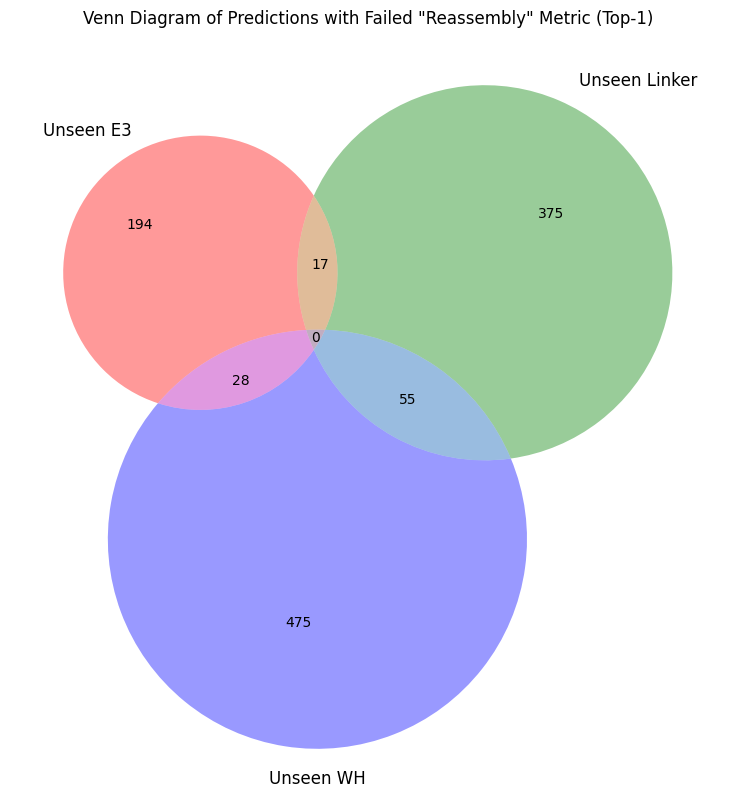

Number of failed predictions: 1505 for metric: no_all_equal_top_1
Fail predictions with unseen E3: 239
Fail predictions with unseen Linker: 559
Fail predictions with unseen Warhead: 563


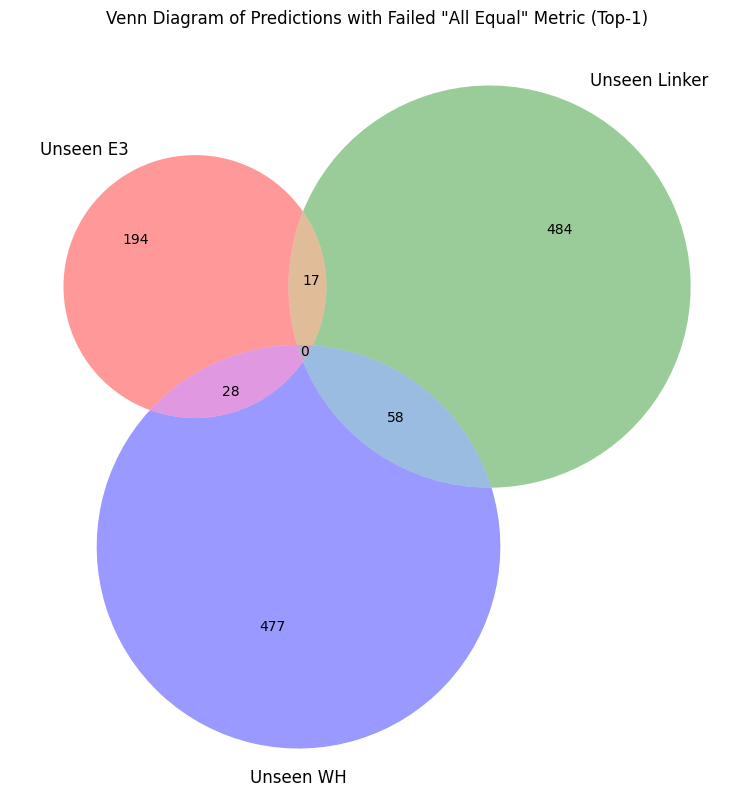

Number of failed predictions: 211 for metric: no_reassembly_fixed_top_1
Fail predictions with unseen E3: 93
Fail predictions with unseen Linker: 52
Fail predictions with unseen Warhead: 120


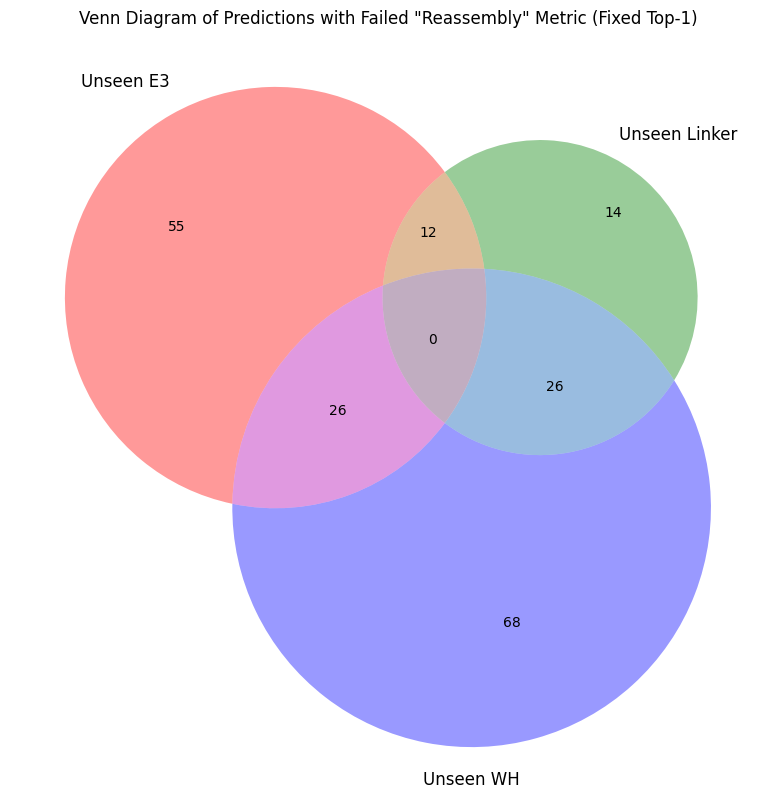

Number of failed predictions: 796 for metric: no_all_equal_fixed_top_1
Fail predictions with unseen E3: 111
Fail predictions with unseen Linker: 255
Fail predictions with unseen Warhead: 274


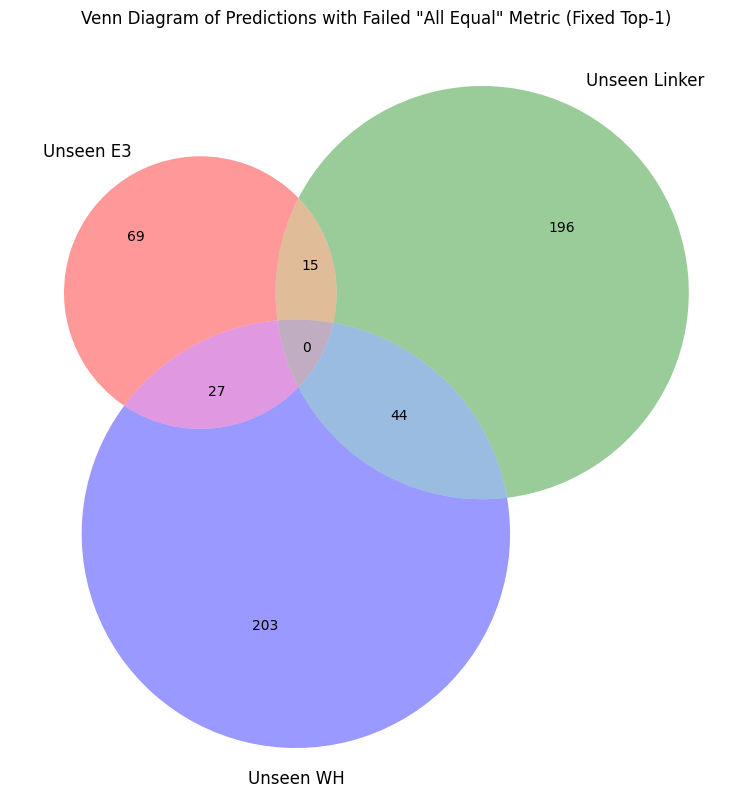

In [ ]:
from matplotlib_venn import venn3

train_e3 = set(train_df['e3_label'].unique())
train_lk = set(train_df['linker_label'].unique())
train_wh = set(train_df['poi_label'].unique())

for df_name, df in venn_dfs.items():
    print(f"Number of failed predictions: {len(df)} for metric: {df_name}")
    # Get all protac_smiles in df with e3_smiles in unseen_e3
    fail_preds_with_unseen_e3 = set(df[~(df['e3_label'].isin(train_e3))]['protac_smiles'])
    fail_preds_with_unseen_lk = set(df[~(df['linker_label'].isin(train_lk))]['protac_smiles'])
    fail_preds_with_unseen_wh = set(df[~(df['poi_label'].isin(train_wh))]['protac_smiles'])

    print(f"Fail predictions with unseen E3: {len(fail_preds_with_unseen_e3)}")
    print(f"Fail predictions with unseen Linker: {len(fail_preds_with_unseen_lk)}")
    print(f"Fail predictions with unseen Warhead: {len(fail_preds_with_unseen_wh)}")

    # all_unseen_preds = df[df['e3_label'].isin(unseen_e3) & df['linker_label'].isin(unseen_lk) & df['poi_label'].isin(unseen_wh)]
    # display(all_unseen_preds[['protac_smiles', 'e3_label', 'linker_label', 'poi_label']])

    # Create the Venn diagram
    plt.figure(figsize=(10, 10))
    venn3((fail_preds_with_unseen_e3, fail_preds_with_unseen_lk, fail_preds_with_unseen_wh), ('Unseen E3', 'Unseen Linker', 'Unseen WH'))
    df_name = " ".join(df_name.split("_")).title().replace("No ", "Failed \"").replace(" Fixed Top 1", "\" Metric (Fixed Top-1)").replace(" Top 1", "\" Metric (Top-1)")
    plt.title(f"Venn Diagram of Predictions with {df_name}")
    plt.show()


Number of failed predictions: 1168 for metric: no_reassembly_top_1
Fail predictions with unseen E3: 929
Fail predictions with unseen Linker: 721
Fail predictions with unseen Warhead: 610


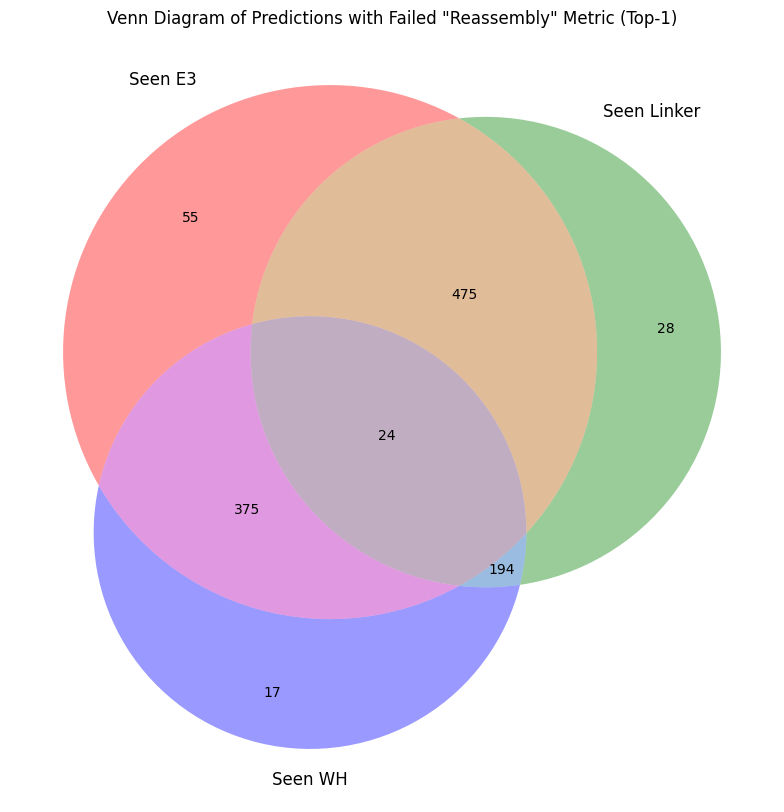

Number of failed predictions: 1505 for metric: no_all_equal_top_1
Fail predictions with unseen E3: 1266
Fail predictions with unseen Linker: 946
Fail predictions with unseen Warhead: 942


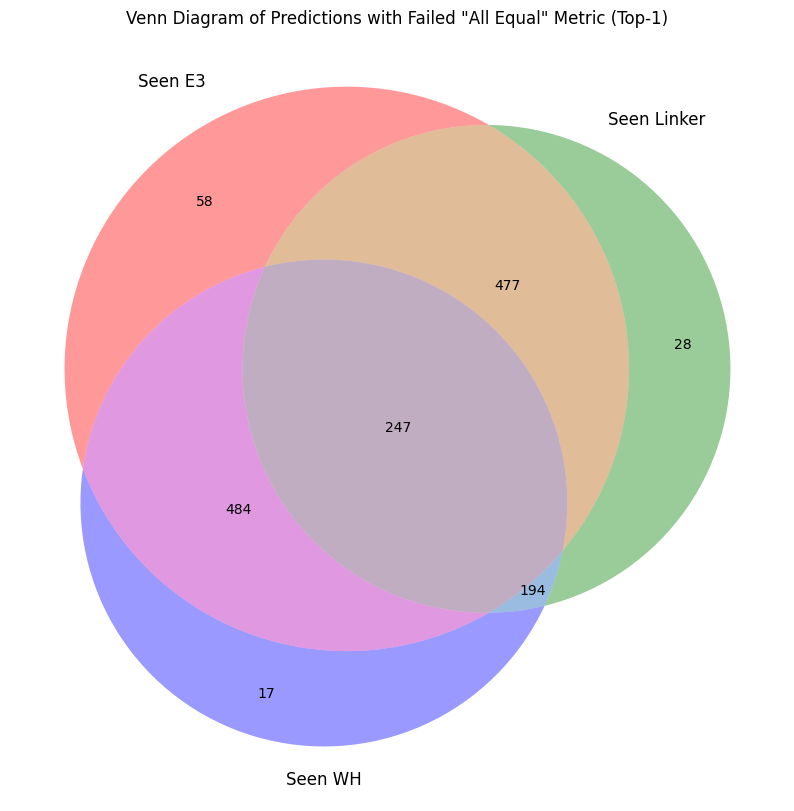

Number of failed predictions: 211 for metric: no_reassembly_fixed_top_1
Fail predictions with unseen E3: 118
Fail predictions with unseen Linker: 159
Fail predictions with unseen Warhead: 91


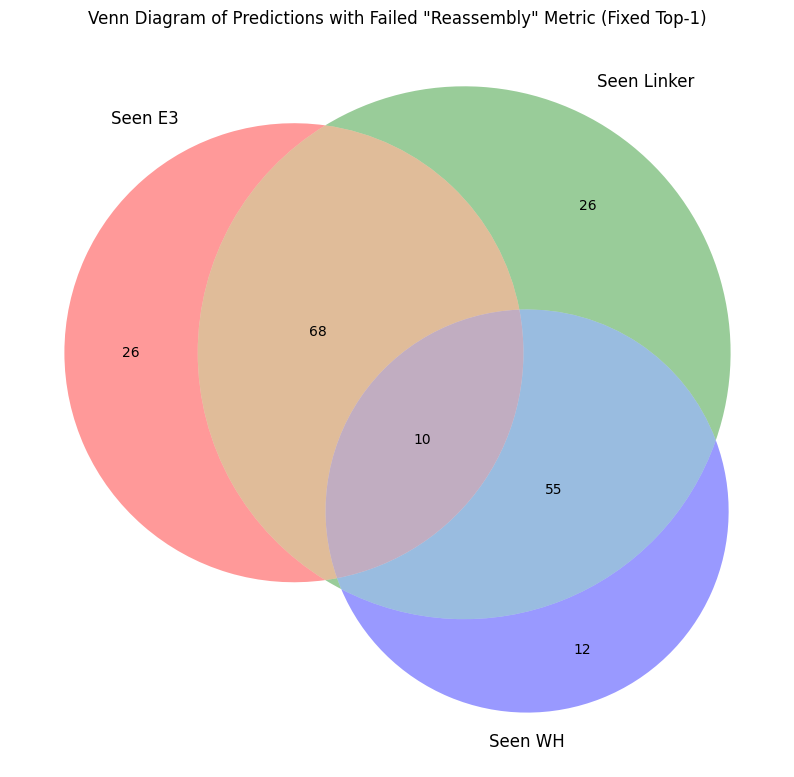

Number of failed predictions: 796 for metric: no_all_equal_fixed_top_1
Fail predictions with unseen E3: 685
Fail predictions with unseen Linker: 541
Fail predictions with unseen Warhead: 522


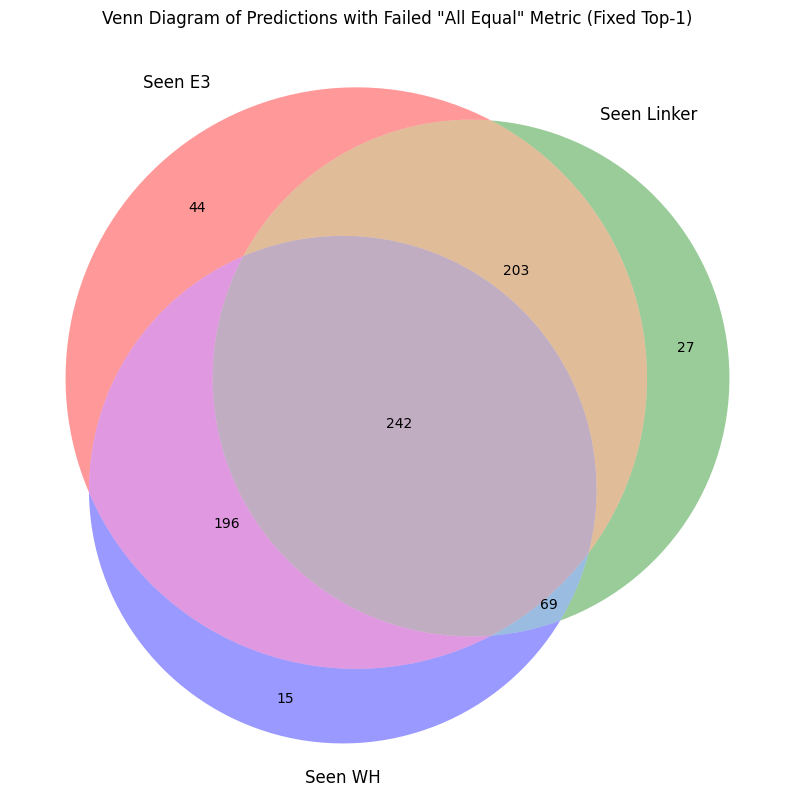

In [ ]:
from matplotlib_venn import venn3

train_e3 = set(train_df['e3_label'].unique())
train_lk = set(train_df['linker_label'].unique())
train_wh = set(train_df['poi_label'].unique())

for df_name, df in venn_dfs.items():
    
    print(f"Number of failed predictions: {len(df)} for metric: {df_name}")

    # Get all protac_smiles in df with e3_smiles in unseen_e3
    fail_preds_with_seen_e3 = set(df[df['e3_label'].isin(train_e3)]['protac_smiles'])
    fail_preds_with_seen_lk = set(df[df['linker_label'].isin(train_lk)]['protac_smiles'])
    fail_preds_with_seen_wh = set(df[df['poi_label'].isin(train_wh)]['protac_smiles'])

    print(f"Fail predictions with unseen E3: {len(fail_preds_with_seen_e3)}")
    print(f"Fail predictions with unseen Linker: {len(fail_preds_with_seen_lk)}")
    print(f"Fail predictions with unseen Warhead: {len(fail_preds_with_seen_wh)}")

    # Create the Venn diagram
    plt.figure(figsize=(10, 10))
    venn3((fail_preds_with_seen_e3, fail_preds_with_seen_lk, fail_preds_with_seen_wh), ('Seen E3', 'Seen Linker', 'Seen WH'))
    df_name = " ".join(df_name.split("_")).title().replace("No ", "Failed \"").replace(" Fixed Top 1", "\" Metric (Fixed Top-1)").replace(" Top 1", "\" Metric (Top-1)")
    plt.title(f"Venn Diagram of Predictions with {df_name}")
    plt.show()

### Venn Diagram of the Datasets

In [503]:
def split_row(sample):
    label_smiles = sample['labels']
    split = split_prediction(label_smiles)
    sample['e3_label'] = split['e3']
    sample['linker_label'] = split['linker']
    sample['poi_label'] = split['poi']
    return sample

ds = datasets.load_dataset("ailab-bio/PROTAC-Splitter-Dataset", "clustered")
ds = ds.map(split_row, num_proc=8)

train_df = ds['train'].to_pandas()
val_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()
held_out_df = ds['held_out'].to_pandas()

Map (num_proc=8):   0%|          | 0/11315 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/11296 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/5670 [00:00<?, ? examples/s]

In [504]:
def is_in_train(sample, e3_unique, linker_unique, poi_unique):
    sample['e3_in_train'] = sample['e3_label'] in e3_unique
    sample['linker_in_train'] = sample['linker_label'] in linker_unique
    sample['poi_in_train'] = sample['poi_label'] in poi_unique
    return sample

e3_unique = train_df['e3_label'].unique()
linker_unique = train_df['linker_label'].unique()
poi_unique = train_df['poi_label'].unique()

ds['validation'] = ds['validation'].map(lambda x: is_in_train(x, e3_unique, linker_unique, poi_unique), num_proc=8)
ds['test'] = ds['test'].map(lambda x: is_in_train(x, e3_unique, linker_unique, poi_unique), num_proc=8)
ds['held_out'] = ds['held_out'].map(lambda x: is_in_train(x, e3_unique, linker_unique, poi_unique), num_proc=8)

Map (num_proc=8):   0%|          | 0/11315 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/11296 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/5670 [00:00<?, ? examples/s]

In [505]:
df = ds['held_out'].to_pandas()
df[~df['e3_in_train']]

,text,labels,e3_label,linker_label,poi_label,e3_in_train,linker_in_train,poi_in_train
20,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,COc1cc(C(=O)[*:2])ccc1NC(=O)[C@@H]1N[C@@H](CC(...,COc1cc(C(=O)[*:2])ccc1NC(=O)[C@@H]1N[C@@H](CC(...,C(CCCCCN[*:2])CCCCC[*:1],C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,False,False,True
164,Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@...,Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)[*:2...,Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)[*:2...,Cc1ncsc1-c1ccc([C@H](CC(=O)N2CCC(N3CCC(C#C[*:1...,CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]...,False,True,True
165,Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@...,Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)[*:2...,Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)[*:2...,Cc1ncsc1-c1ccc([C@H](CC(=O)N2CCC(C#C[*:1])CC2)...,CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]...,False,False,True
254,COc1cc(C(=O)NCCOCCOCCOCCNC(=O)C[C@@H]2N=C(c3cc...,COc1cc(C(=O)[*:2])ccc1NC(=O)[C@@H]1N[C@@H](CC(...,COc1cc(C(=O)[*:2])ccc1NC(=O)[C@@H]1N[C@@H](CC(...,C(COCCOCCOCCN[*:2])N[*:1],Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@@H](CC(=O)[*:1...,False,True,True
258,Cc1cc(C(C(=O)N2C[C@H](O)CC2C(=O)NC(CC(=O)N2CCC...,Cc1cc(C(C(=O)N2C[C@H](O)CC2C(=O)[*:2])C(C)C)on...,Cc1cc(C(C(=O)N2C[C@H](O)CC2C(=O)[*:2])C(C)C)on1,Cc1ncsc1-c1ccc(C(CC(=O)N2CCC(N3CCC(C#C[*:1])CC...,CC1(C)C(NC(=O)c2ccc([*:1])cc2)C(C)(C)C1Oc1ccc(...,False,True,True
...,...,...,...,...,...,...,...,...
5489,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,O=C(CO[*:2])NCCOCCO[*:1],CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C...,False,True,False
5499,CN[C@@H](C)C(=O)N[C@H]1CN(C(=O)c2cnc(N3CCN(CCC...,CN[C@@H](C)C(=O)N[C@H]1CN([*:2])CC[C@H]2CC[C@@...,CN[C@@H](C)C(=O)N[C@H]1CN([*:2])CC[C@H]2CC[C@@...,O=C(c1cnc(N2CCN(CCC[*:1])CC2)cn1)[*:2],Cc1[nH]nc(Nc2ncnc3cc(O[*:1])c(S(=O)(=O)C(C)(C)...,False,True,True
5525,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,O=C(CO[*:2])NCCOCCOCCOCCO[*:1],CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C...,False,True,False
5526,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,CC1=C(/C=C/C(C)=C/C=C/C(C)=C/C(=O)O)C(C)(C)CC/...,O=C(CO[*:2])NCCOCCOCCOC[*:1],O=c1cc(-c2ccc([*:1])cc2)oc2ccc3ccccc3c12,False,True,False


NOTE: For a PROTAC in the held-out set, we can have the scenario of all its three ligands to be in the training set, despite the entire PROTAC not being in the train set. It is indeed possible to

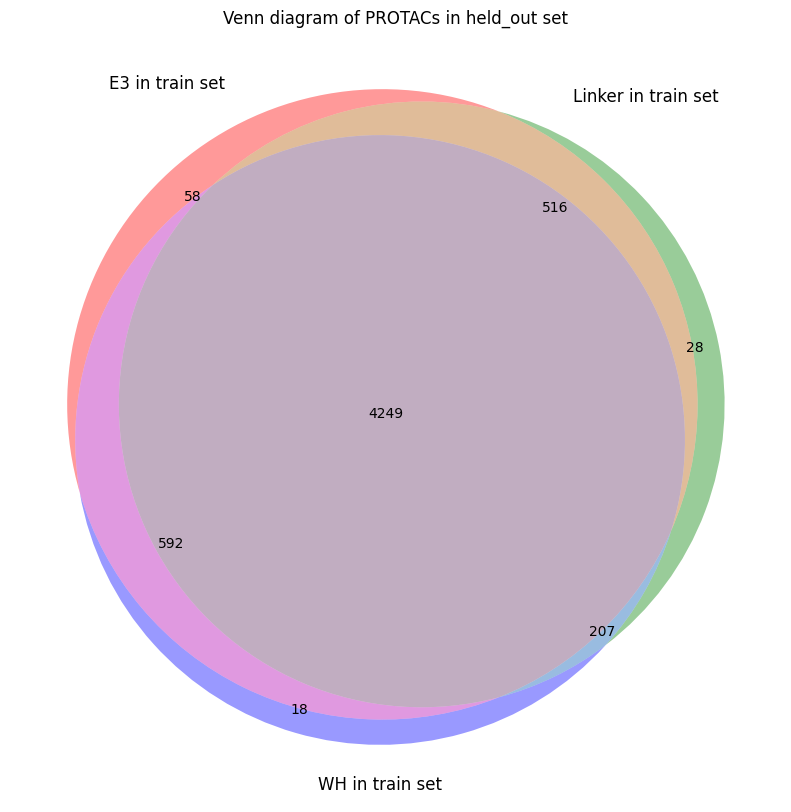

0
--------------------------------------------------------------------------------


Filter:   0%|          | 0/11315 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1795 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11315 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1051 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11315 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1875 [00:00<?, ? examples/s]

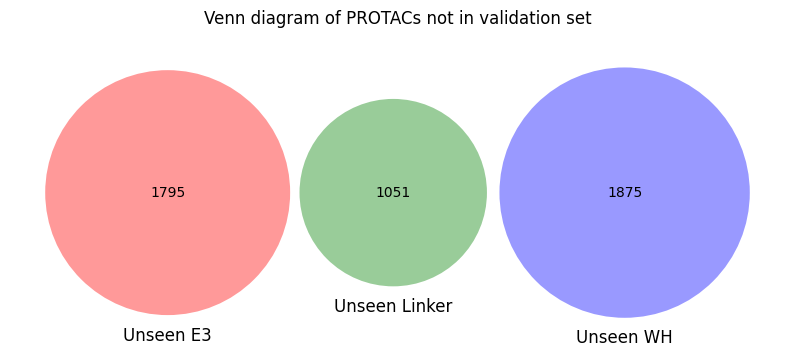

Filter:   0%|          | 0/11296 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1810 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11296 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1037 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11296 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1889 [00:00<?, ? examples/s]

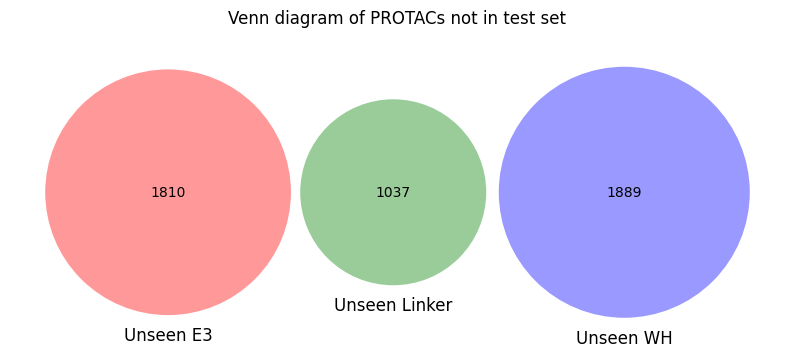

Filter:   0%|          | 0/5670 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/255 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5670 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/670 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5670 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/604 [00:00<?, ? examples/s]

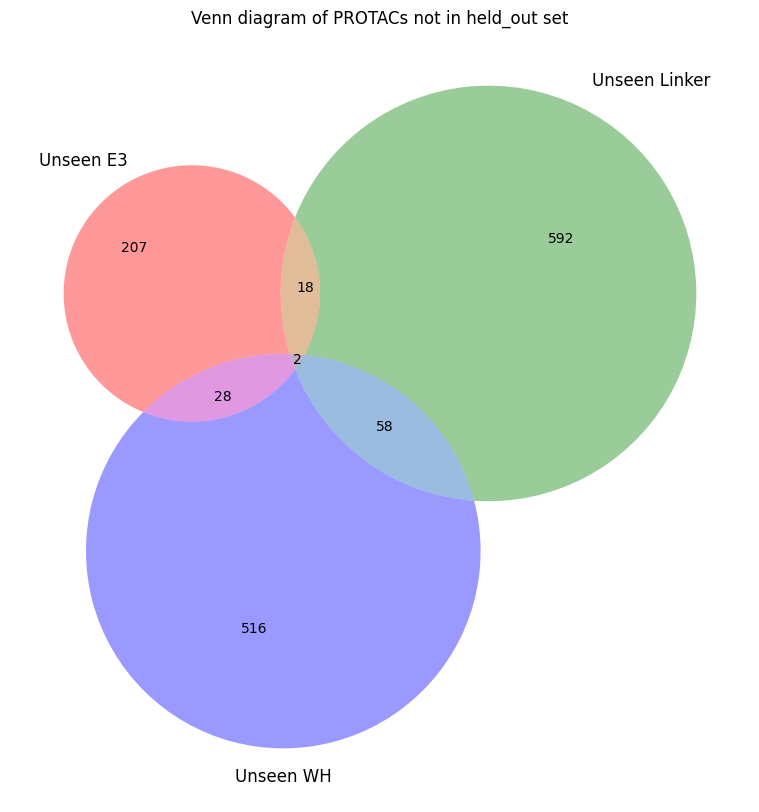

In [ ]:
for split in ['held_out']: # ['validation', 'test', 'held_out']:
    protac_sets = {}
    for ligand in ['e3', 'linker', 'poi']:
        protac_sets[ligand] = set(ds[split].filter(lambda x: x[f'{ligand}_in_train'], desc=None).unique('text'))

    # Create the Venn diagram
    plt.figure(figsize=(10, 10))
    venn3((protac_sets['e3'], protac_sets['linker'], protac_sets['poi']), ('E3 in train set', 'Linker in train set', 'WH in train set'))
    # df_name = " ".join(df_name.split("_")).title().replace("No ", "Failed \"").replace(" Fixed Top 1", "\" Metric (Fixed Top-1)").replace(" Top 1", "\" Metric (Top-1)")
    plt.title(f"Venn diagram of PROTACs in {split} set")
    plt.show()

print('-' * 80)

for split in ['validation', 'test', 'held_out']:
    protac_sets = {}
    for ligand in ['e3', 'linker', 'poi']:
        protac_sets[ligand] = set(ds[split].filter(lambda x: not x[f'{ligand}_in_train'], desc=None).unique('text'))

    # Create the Venn diagram
    plt.figure(figsize=(10, 10))
    venn3((protac_sets['e3'], protac_sets['linker'], protac_sets['poi']), ('Unseen E3', 'Unseen Linker', 'Unseen WH'))
    # df_name = " ".join(df_name.split("_")).title().replace("No ", "Failed \"").replace(" Fixed Top 1", "\" Metric (Fixed Top-1)").replace(" Top 1", "\" Metric (Top-1)")
    plt.title(f"Venn diagram of PROTACs not in {split} set")
    plt.show()

## Likelihoods Analysis

In [ ]:
score_file = "../logs/PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles-scores_with_perplexity.csv"
preds_file = '../logs/PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles-preds_with_perplexity.csv'

# NOTE: I've updated the prediction script, there is no need to merge the two anymore.
# df_scores = pd.read_csv(score_file)
# df_preds = pd.read_csv(preds_file)
# # Merge the preds column "default_prob_n0" to the scores DataFrame based on the "protac_smiles" column
# df = pd.merge(df_scores, df_preds[['protac_smiles', 'default_prob_n0', 'default_perplexity_n0']], on='protac_smiles', how='inner')

df = pd.read_csv(score_file)
df

,protac_smiles,label_smiles,default_pred_n0,default_prob_n0,default_perplexity_n0,model_name,default_pred_n0_has_three_substructures,default_pred_n0_has_all_attachment_points,default_pred_n0_num_fragments,default_pred_n0_valid,...,default_pred_n0_poi_heavy_atoms_difference_fixed,default_pred_n0_poi_heavy_atoms_difference_norm_fixed,default_pred_n0_linker_valid_fixed,default_pred_n0_linker_equal_fixed,default_pred_n0_linker_has_attachment_point(s)_fixed,default_pred_n0_linker_graph_edit_distance_fixed,default_pred_n0_linker_graph_edit_distance_norm_fixed,default_pred_n0_linker_heavy_atoms_difference_fixed,default_pred_n0_linker_heavy_atoms_difference_norm_fixed,default_pred_n0_is_fixed
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,1.000000,1.000000,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,0,0.000000,True,True,True,0.0,0.000000,0,0.000000,True
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,0.999966,1.000034,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,0,0.000000,True,True,True,0.0,0.000000,0,0.000000,True
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,0.997904,1.002100,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,6,0.092308,True,False,True,13.0,0.333333,-6,-0.857143,True
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,0.997008,1.003001,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,6,0.092308,True,False,True,13.0,0.302326,-6,-0.750000,True
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,0.997100,1.002909,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,6,0.092308,True,False,True,13.0,0.276596,-6,-0.666667,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5663,O=C1CCC(N2Cc3c(NC(=O)COCCOCCNCCNc4nonc4/C(=N\O...,O/N=C(/Nc1ccc(F)c(Br)c1)c1nonc1[*:1].O=C(COCCO...,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1.O=C(CO...,0.990774,1.009312,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,-4,-0.235294,True,False,True,8.0,0.190476,4,0.307692,True
5664,O=C1CCC(N2C(=O)c3cccc(NC(=O)COCCOCCOCCOCCOCCNC...,O/N=C(\Nc1ccc(F)c(Br)c1)c1nonc1[*:1].O=C(COCCO...,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1.O=...,0.997788,1.002216,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,0,0.000000,True,True,True,0.0,0.000000,0,0.000000,True
5665,O=C1CCC(N2C(=O)c3cccc(NC(=O)COCCOCCOCCOCCOCCNC...,O=C(COCCOCCOCCOCCOCCNCCN[*:1])[*:2].O=C1CCC(N2...,O=C1CCC(N2C(=O)c3cccc(N[*:2])c3C2=O)C(=O)N1.O=...,0.998656,1.001346,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,0,0.000000,True,True,True,0.0,0.000000,0,0.000000,True
5666,O=C1CCC(N2Cc3c(NC(=O)COCCOCCOCCOCCNCCNc4nonc4/...,O/N=C(/Nc1ccc(F)c(Br)c1)c1nonc1[*:1].O=C(COCCO...,O=C1CCC(N2Cc3c(N[*:2])cccc3C2=O)C(=O)N1.O=C(CO...,0.999414,1.000586,/mimer/NOBACKUP/groups/naiss2023-6-290/stefano...,True,True,3,True,...,0,0.000000,True,True,True,0.0,0.000000,0,0.000000,True


In [ ]:
df['default_prob_n0'].describe()

count    5668.000000
mean        0.998125
std         0.004139
min         0.962131
25%         0.998283
50%         0.999995
75%         1.000000
max         1.000000
Name: default_prob_n0, dtype: float64

In [ ]:
df['default_perplexity_n0'].describe()

count    5668.000000
mean        1.001896
std         0.004212
min         1.000000
25%         1.000000
50%         1.000005
75%         1.001720
max         1.039360
Name: default_perplexity_n0, dtype: float64

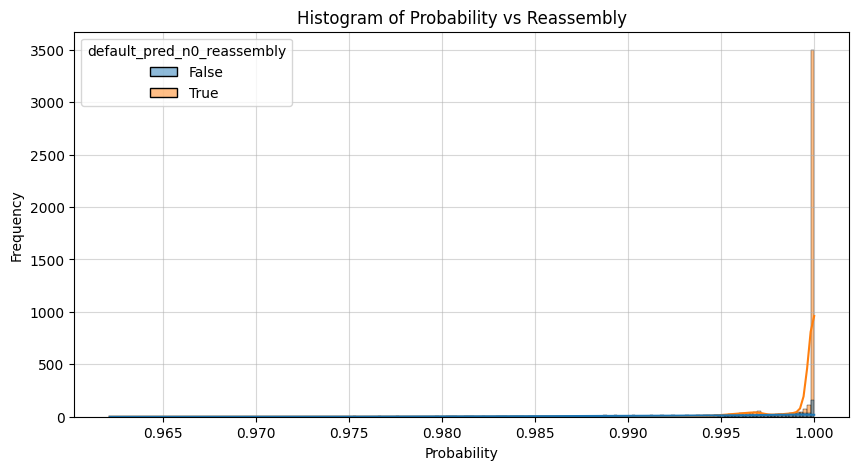

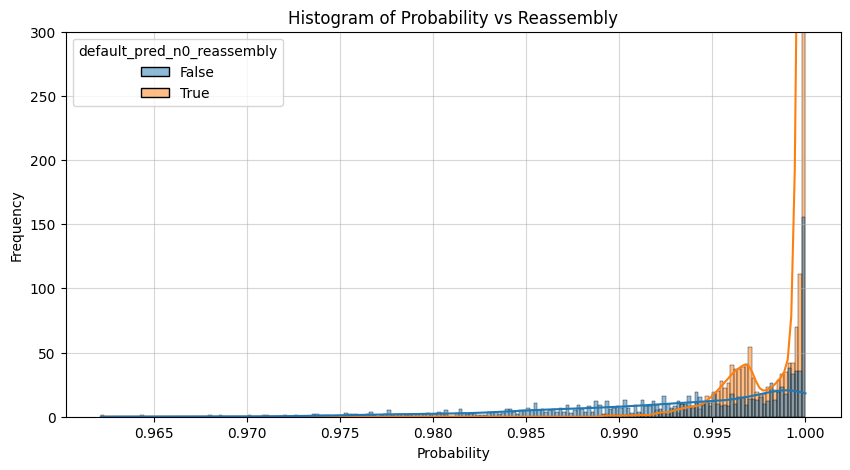

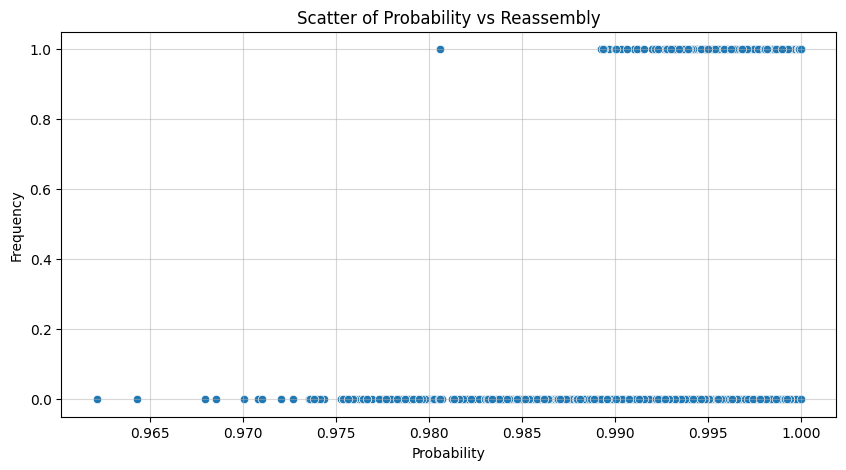

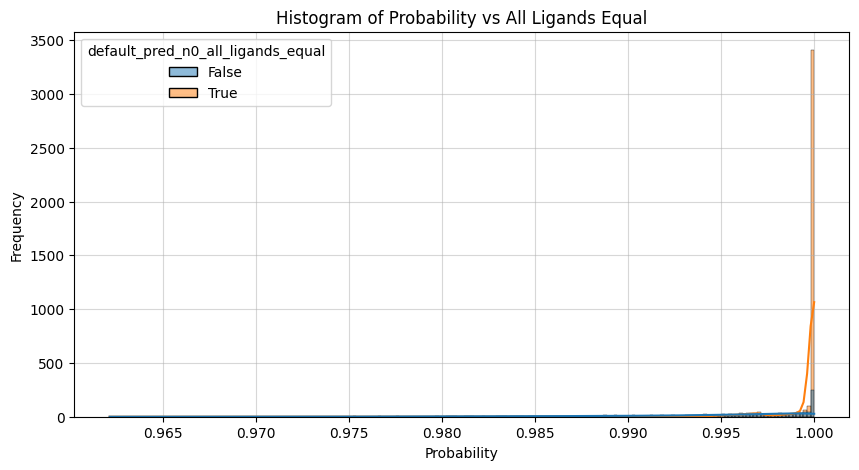

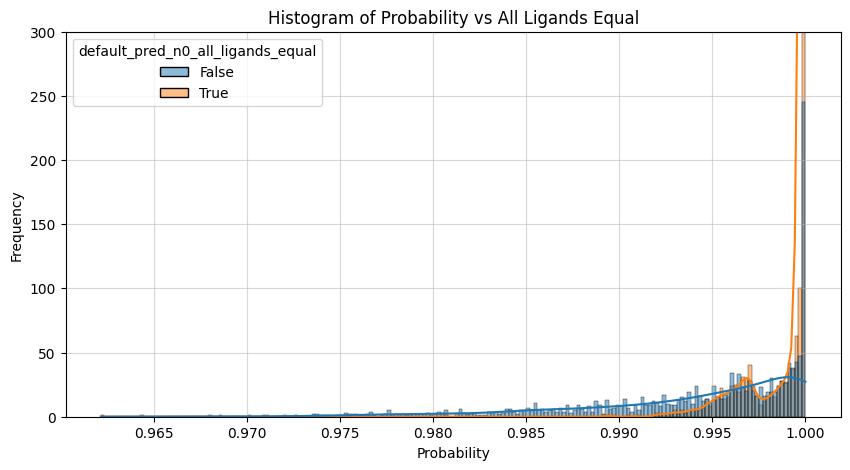

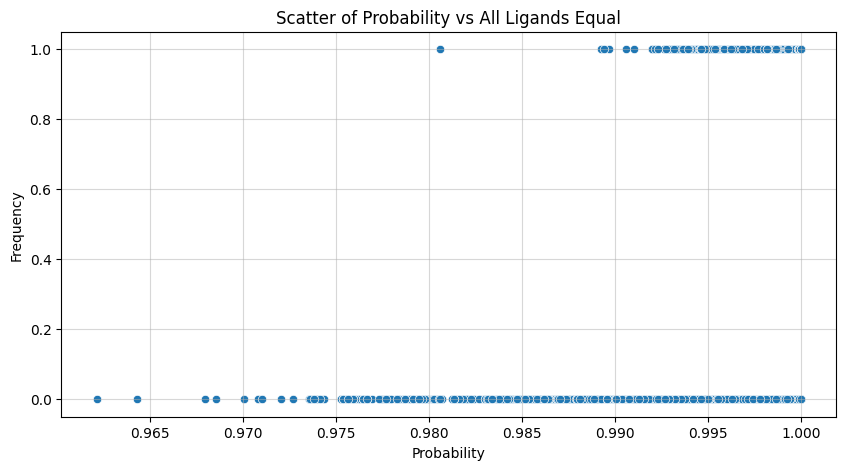

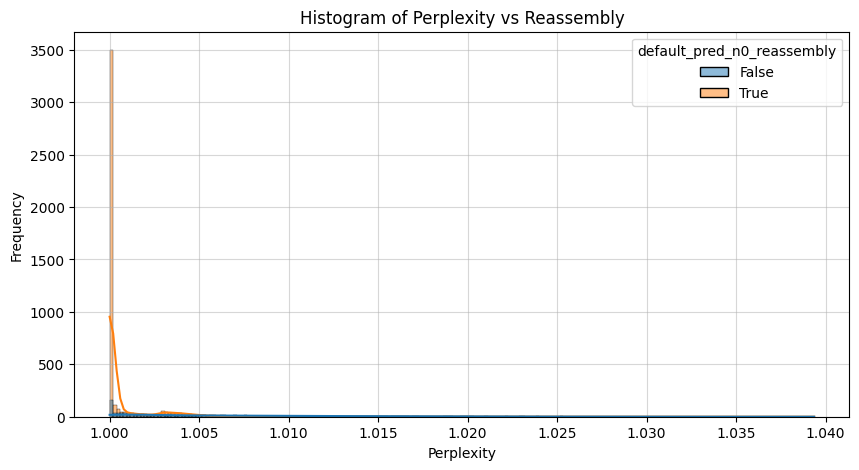

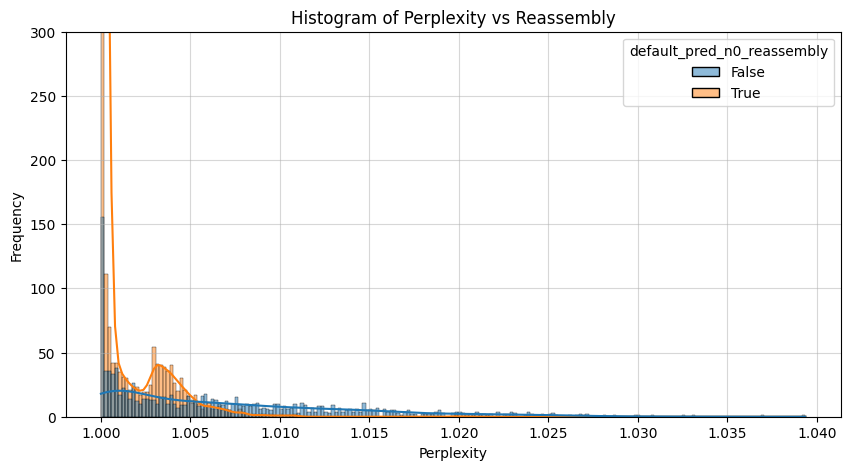

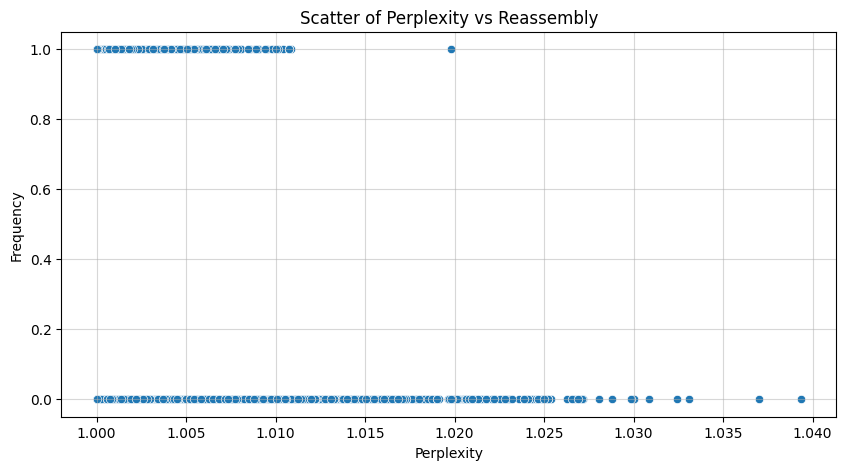

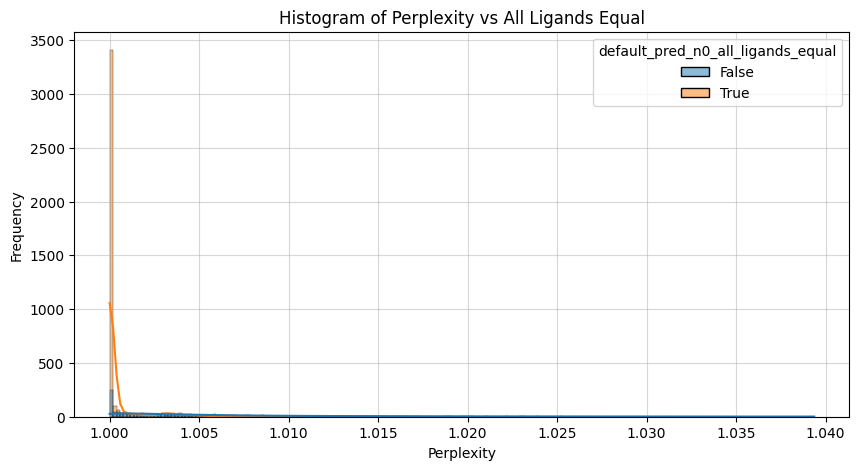

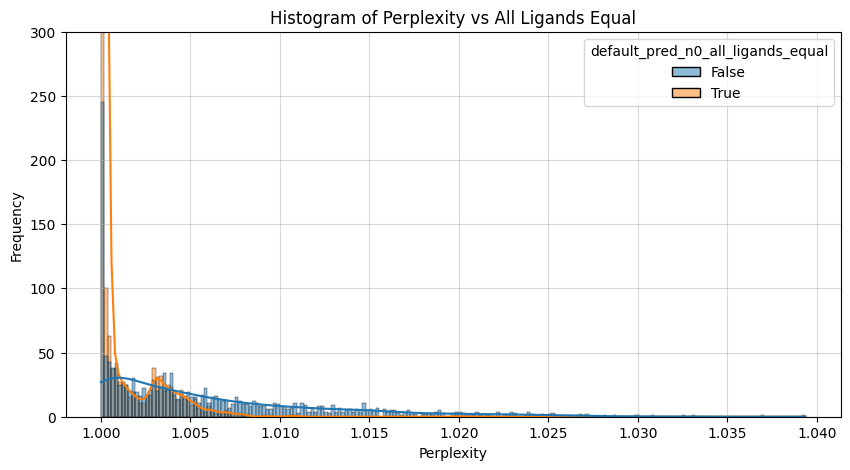

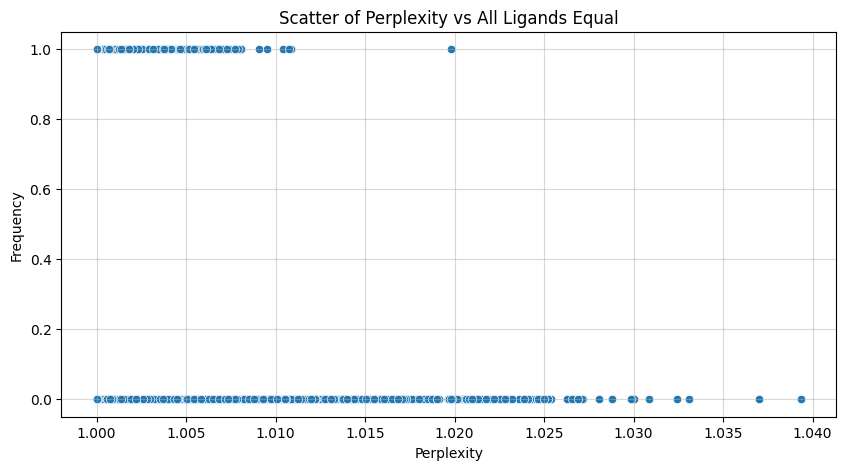

In [ ]:
# Plot the histogram of the "default_pred_n0_reassembly" column versus the "default_prob_n0" column on the x-axis
for x_metric in ['default_prob_n0', 'default_perplexity_n0']:
    for hue_metric in ['default_pred_n0_reassembly', 'default_pred_n0_all_ligands_equal']:
        plt.figure(figsize=(10, 5))
        sns.histplot(data=df, x=x_metric, hue=hue_metric, kde=True)

        x_label = "Perplexity" if 'perplexity' in x_metric else "Probability"
        hue_label = "Reassembly" if 'reassembly' in hue_metric else "All Ligands Equal"
        plt.xlabel(x_label)
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {x_label} vs {hue_label}")
        plt.grid(axis='both', alpha=0.5)
        # Change the legend title to hue_label
        plt.show()

        plt.figure(figsize=(10, 5))
        sns.histplot(data=df, x=x_metric, hue=hue_metric, kde=True)
        plt.xlabel(x_label)
        plt.ylabel("Frequency")
        plt.title(f"Histogram of {x_label} vs {hue_label}")
        plt.grid(axis='both', alpha=0.5)
        plt.ylim(0, 300)
        plt.show()

        plt.figure(figsize=(10, 5))
        sns.scatterplot(data=df, x=x_metric, y=hue_metric)
        plt.xlabel(x_label)
        plt.ylabel("Frequency")
        plt.title(f"Scatter of {x_label} vs {hue_label}")
        plt.grid(axis='both', alpha=0.5)
        plt.show()

Train samples per class: [ 934 3600]
Test samples per class: [234 900]


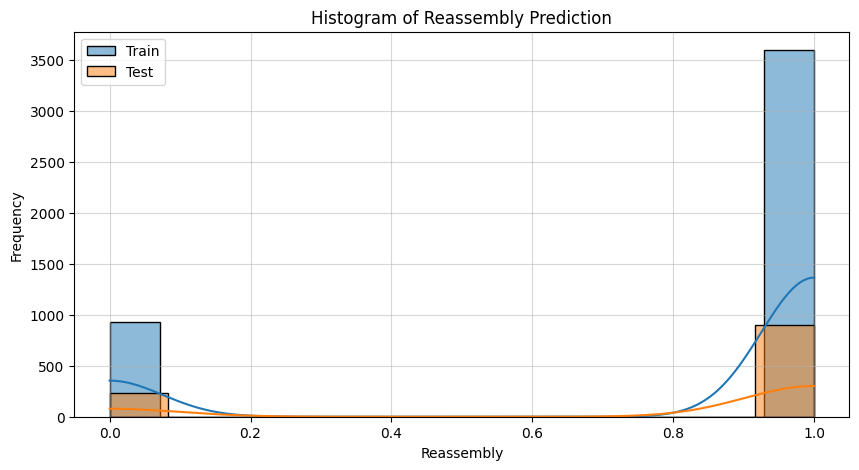

Model accuracy: 0.87 (dummy: 0.79)
Model F1-score: 0.92 (dummy: 0.88)
Model ROC-AUC:  0.73 (dummy: 0.50)
Threshold value: 0.9945835075370105 (-intercept / coef)
Threshold value: 0.9945792900668727 (at likelihood: 0.5)


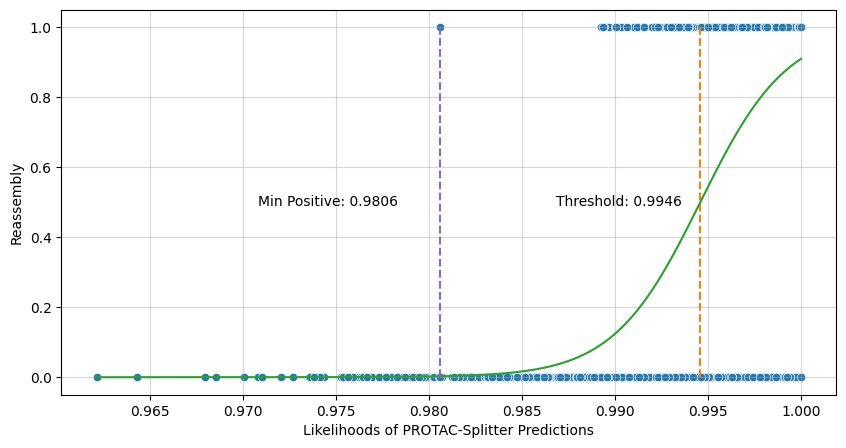

'\nModel accuracy: 0.88\nModel F1-score: 0.93\nModel ROC-AUC:  0.73\nThreshold value: 0.9946123541139846 (-intercept / coef)\nThreshold value: 0.9946171971293422 (at likelihood: 0.501)\n\nSMOTE\nModel accuracy: 0.84\nModel F1-score: 0.89\nModel ROC-AUC:  0.77\nThreshold value: 0.9977714828615153 (-intercept / coef)\nThreshold value: 0.9977634833143041 (at likelihood: 0.499)\n\nADASYN\nModel accuracy: 0.83\nModel F1-score: 0.89\nModel ROC-AUC:  0.79\nThreshold value: 0.9984547086315599 (-intercept / coef)\nThreshold value: 0.9984458104387537 (at likelihood: 0.499)\n'

In [ ]:
# Fit a logistic regression model to predict the threshold value for the "default_prob_n0" column
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.dummy import DummyClassifier

# Split the data into training and testing sets
X = df['default_prob_n0'].values.reshape(-1, 1)
y = df['default_pred_n0_reassembly']
# Balance the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Oversample the minority class
# X_train, y_train = SMOTE(k_neighbors=5, random_state=42).fit_resample(X_train, y_train)
# X_train, y_train = ADASYN(n_neighbors=5, random_state=42).fit_resample(X_train, y_train)

# Print the number of samples per class of the y train and test sets
print(f"Train samples per class: {np.bincount(y_train)}")
print(f"Test samples per class: {np.bincount(y_test)}")

# Plot the True/False values of the y train and test sets
plt.figure(figsize=(10, 5))
sns.histplot(y_train, color='C0', label='Train', kde=True)
sns.histplot(y_test, color='C1', label='Test', kde=True)
plt.xlabel("Reassembly")
plt.ylabel("Frequency")
plt.title("Histogram of Reassembly Prediction")
plt.grid(axis='both', alpha=0.5)
plt.legend()
plt.show()

# Fit the logistic regression model
model = LogisticRegressionCV(cv=5, random_state=42, max_iter=1000, tol=1e-7, Cs=100)
model.fit(X_train, y_train)

# Get the model score
accuracy = model.score(X_test, y_test)
f1score = f1_score(y_test, model.predict(X_test))
roc_auc = roc_auc_score(y_test, model.predict(X_test))

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_accuracy = dummy.score(X_test, y_test)
dummy_f1score = f1_score(y_test, dummy.predict(X_test))
dummy_roc_auc = roc_auc_score(y_test, dummy.predict(X_test))

print(f"Model accuracy: {accuracy:.2f} (dummy: {dummy_accuracy:.2f})")
print(f"Model F1-score: {f1score:.2f} (dummy: {dummy_f1score:.2f})")
print(f"Model ROC-AUC:  {roc_auc:.2f} (dummy: {dummy_roc_auc:.2f})")

x = np.linspace(min(df['default_prob_n0']), max(df['default_prob_n0']), 1000)
y = model.predict_proba(x.reshape(-1, 1))[:, 1]

# Find the y-value closest to 0.5
y_closest = np.abs(y - 0.5)
idx = np.argmin(y_closest)
x_threshold = x[idx]
y_threshold = y[idx]

# Get the value of X for which the model predicts a 50% probability
threshold = -model.intercept_[0] / model.coef_[0][0]

print(f"Threshold value: {threshold} (-intercept / coef)")
print(f"Threshold value: {x_threshold} (at likelihood: {y_threshold:.3})")

# Plot the logistic regression curve over the scatter points
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='default_prob_n0', y='default_pred_n0_reassembly')
plt.plot([threshold, threshold], [0, 1], 'C1--')
plt.plot(x, y, color='C2')
# Print the threshold value on the plot
plt.text(threshold - threshold / 1e3, 0.5, f"Threshold: {threshold:.4f}", ha='right', va='center')

min_pos_threshold = df[df['default_pred_n0_reassembly'] == 1]['default_prob_n0'].min()
plt.plot([min_pos_threshold, min_pos_threshold], [0, 1], 'C4--')
plt.text(min_pos_threshold - min_pos_threshold / 1e2, 0.5, f"Min Positive: {min_pos_threshold:.4f}", ha='left', va='center')

plt.xlabel("Likelihoods of PROTAC-Splitter Predictions")
plt.ylabel("Reassembly")
plt.title("")
plt.grid(axis='both', alpha=0.5)
plt.show()

'''
Model accuracy: 0.88
Model F1-score: 0.93
Model ROC-AUC:  0.73
Threshold value: 0.9946123541139846 (-intercept / coef)
Threshold value: 0.9946171971293422 (at likelihood: 0.501)

SMOTE
Model accuracy: 0.84
Model F1-score: 0.89
Model ROC-AUC:  0.77
Threshold value: 0.9977714828615153 (-intercept / coef)
Threshold value: 0.9977634833143041 (at likelihood: 0.499)

ADASYN
Model accuracy: 0.83
Model F1-score: 0.89
Model ROC-AUC:  0.79
Threshold value: 0.9984547086315599 (-intercept / coef)
Threshold value: 0.9984458104387537 (at likelihood: 0.499)
'''

## Display Failed Predictions

In [ ]:
from protac_splitter.display_utils import (
    safe_display,
    get_mapped_protac_img,
    display_mol,
)
from rdkit import Chem
from rdkit.Chem import Draw

def split_row(row):    
    ligands = split_prediction(row['default_pred_n0'])
    label_ligands = split_prediction(row['label_smiles'])
    
    ret = row.to_dict()
    ret['e3'] = ligands['e3']
    ret['linker'] = ligands['linker']
    ret['poi'] = ligands['poi']
    ret['e3_label'] = label_ligands['e3']
    ret['linker_label'] = label_ligands['linker']
    ret['poi_label'] = label_ligands['poi']
    return ret

def is_in_train(row, train_e3, train_lk, train_wh):
    ret = row.to_dict()
    ret['e3_in_train'] = ret['e3_label'] in train_e3
    ret['linker_in_train'] = ret['linker_label'] in train_lk
    ret['poi_in_train'] = ret['poi_label'] in train_wh
    return ret

score_file = "../logs/PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles-scores.csv"
df_scores = pd.read_csv(score_file)

metric = 'default_pred_n0_reassembly_fixed'
failed_reassembly = df_scores[~df_scores[metric]]

train_e3 = set(train_df['e3_label'].unique())
train_lk = set(train_df['linker_label'].unique())
train_wh = set(train_df['poi_label'].unique())

failed_reassembly = failed_reassembly.progress_apply(split_row, axis=1, result_type='expand')
failed_reassembly = failed_reassembly.progress_apply(lambda x: is_in_train(x, train_e3, train_lk, train_wh), axis=1, result_type='expand')
failed_reassembly[['e3_in_train', 'linker_in_train', 'poi_in_train']]

Splitting labels: 100%|██████████| 211/211 [00:00<00:00, 561.82it/s]


,e3_in_train,linker_in_train,poi_in_train
1,False,True,True
2,False,True,True
5,False,False,True
7,False,True,True
162,False,False,True
...,...,...,...
5342,True,False,False
5460,True,False,False
5461,True,False,False
5596,True,False,False


In [ ]:
failed_reassembly[['e3_in_train', 'linker_in_train', 'poi_in_train']].describe()

,e3_in_train,linker_in_train,poi_in_train
count,211,211,211
unique,2,2,2
top,True,True,False
freq,118,159,120


--------------------------------------------------------------------------------
Number of failed reassembly predictions with only e3 not in train: 55 (26.07% of failing, 0.97% of total)
--------------------------------------------------------------------------------
PROTAC:  CC(C)CC(NC(=O)C(O)C(N)Cc1ccccc1)C(=O)NCCCCCC(=O)Nc1ccc(NC(=O)CCCCCCC(=O)NO)cc1
Ligands: CC(C)CC(NC(=O)C(O)C(N)Cc1ccccc1)C(=O)[*:2].O=C(CCCCCCC(=O)[*:1])Nc1ccc(NC(=O)CCCCCN[*:2])cc1.ON[*:1]
Pred:    O=C1CCC(c2ccc([*:2])cc2)C(=O)N1.O=C(CCCCCCC(=O)[*:1])Nc1ccc(NC(=O)CCCCCN[*:2])cc1.NC(Cc1ccccc1)C(=O)C(NC(=O)C(C(C)C)N(Cc1ccccc1)OC)N(C)C(=O)[*:1]


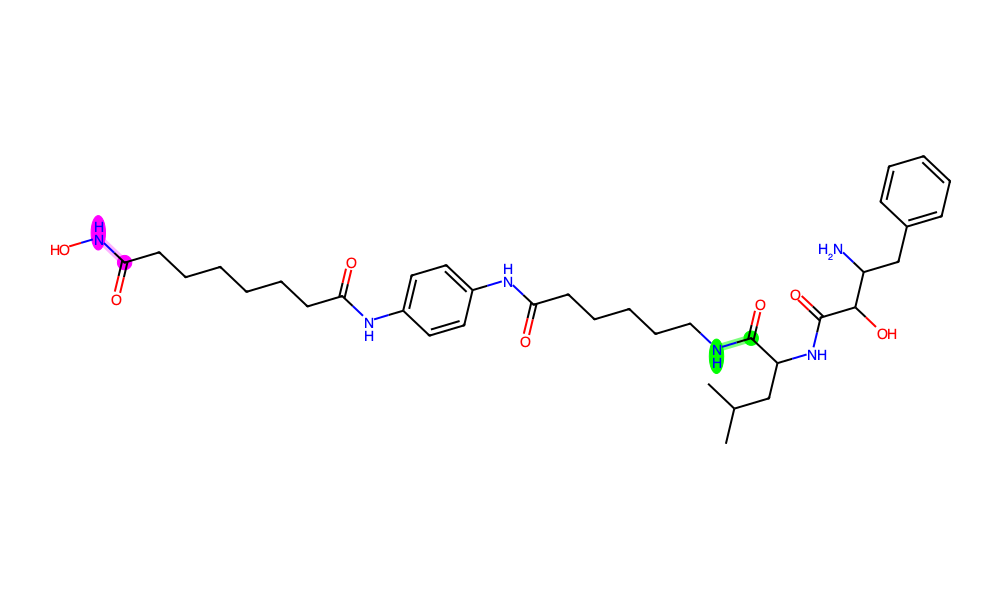

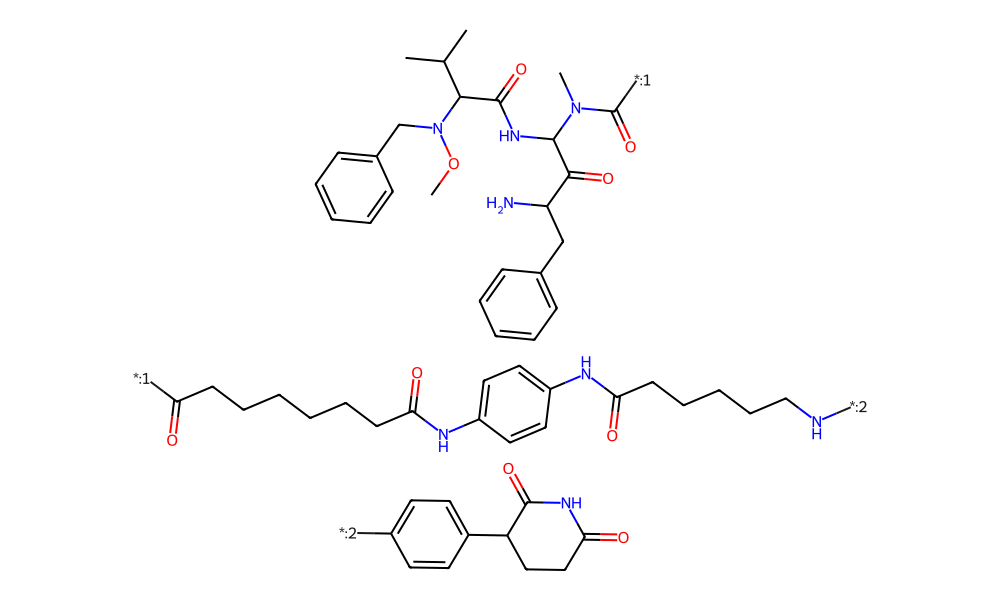

----------------------------------------------------------------------------------------------------
PROTAC:  CN[C@@H](C)C(=O)N[C@H]1CCO[C@H]2CC(C)(C)[C@@H](C(=O)N[C@@H]3CCCc4cc(OCCOCCOCC(=O)N5CCN(CC[C@H](CSc6ccccc6)Nc6ccc(S(=O)(=O)NC(=O)c7ccc(N8CCN(CC9=C(c%10ccc(Cl)cc%10)CCC(C)(C)C9)CC8)cc7)cc6S(=O)(=O)C(F)(F)F)CC5)ccc43)N2C1=O
Ligands: CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCN([*:1])CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1.CN[C@@H](C)C(=O)N[C@H]1CCO[C@H]2CC(C)(C)[C@@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O.O=C(COCCOCCO[*:2])[*:1]
Pred:    CN[C@H](C)C(=O)N[C@@H]1CCO[C@@H]2CC(C)(C)[C@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O.O=C(COCCOCCO[*:2])[*:1].CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCN([*:1])CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1


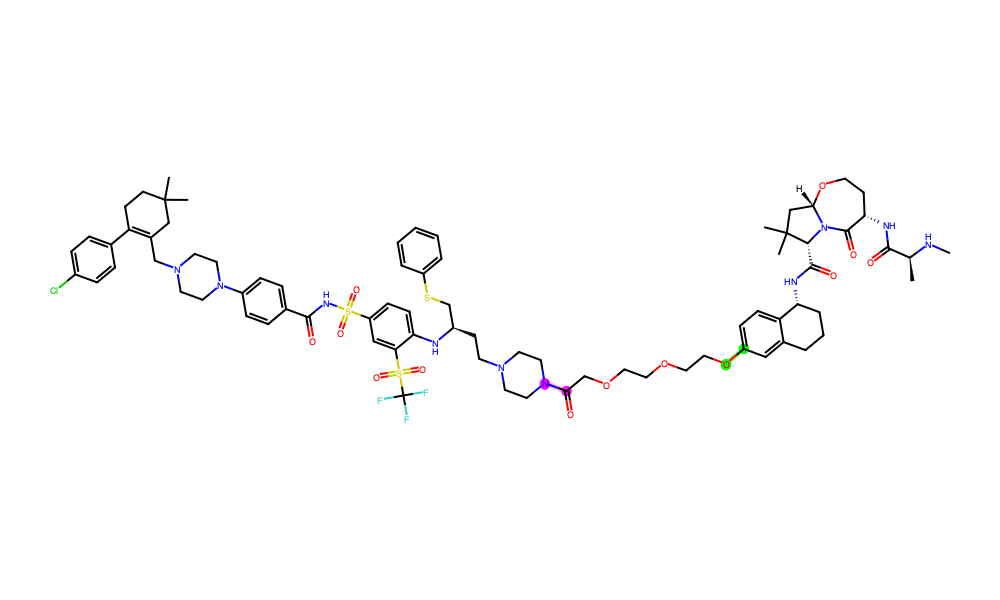

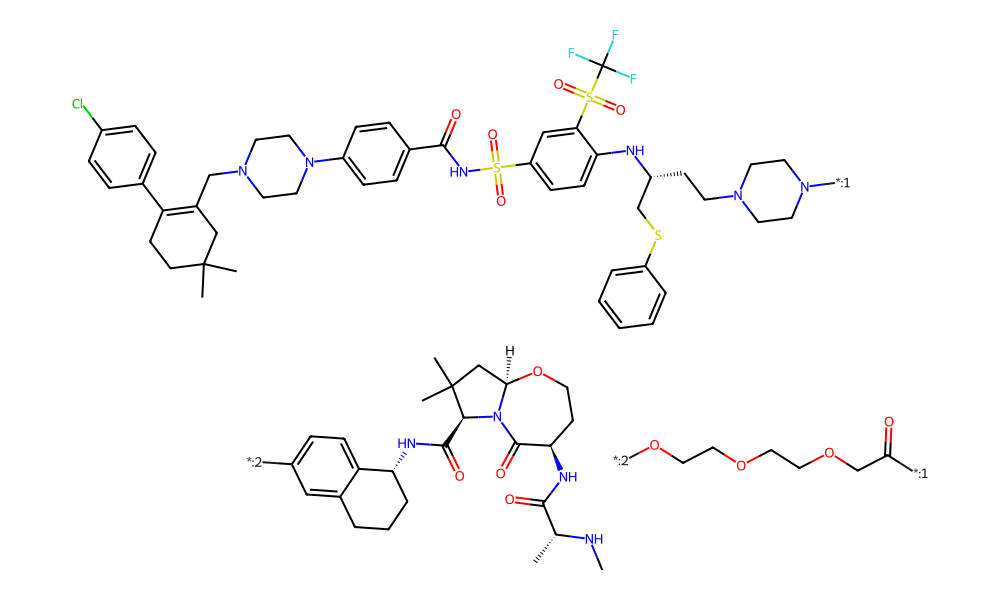

----------------------------------------------------------------------------------------------------
PROTAC:  COc1cc(C(=O)NCCOCCNC(=O)c2ccc(-c3ccc(N4CCN(C)CC4)c(NC(=O)c4c[nH]c(=O)cc4C(F)(F)F)c3)cc2)ccc1NC(=O)C1NC(CC(C)(C)C)C(C#N)(c2ccc(Cl)cc2F)C1c1cccc(Cl)c1F
Ligands: CN1CCN(c2ccc([*:1])cc2NC(=O)c2c[nH]c(=O)cc2C(F)(F)F)CC1.COc1cc(C(=O)[*:2])ccc1NC(=O)C1NC(CC(C)(C)C)C(C#N)(c2ccc(Cl)cc2F)C1c1cccc(Cl)c1F.O=C(NCCOCCN[*:2])c1ccc([*:1])cc1
Pred:    CC(C)(C)NC(=O)C(c1c(C(=O)[*:2])[nH]c2cc(Cl)ccc12)N(C=O)Cc1cc(F)c(F)c(F)c1.O=C(NCCOCCN[*:2])c1ccc([*:1])cc1.N#Cc1ccc(NC2CCC(NC(=O)c3ccc([*:1])cc3)C2)cc1Cl


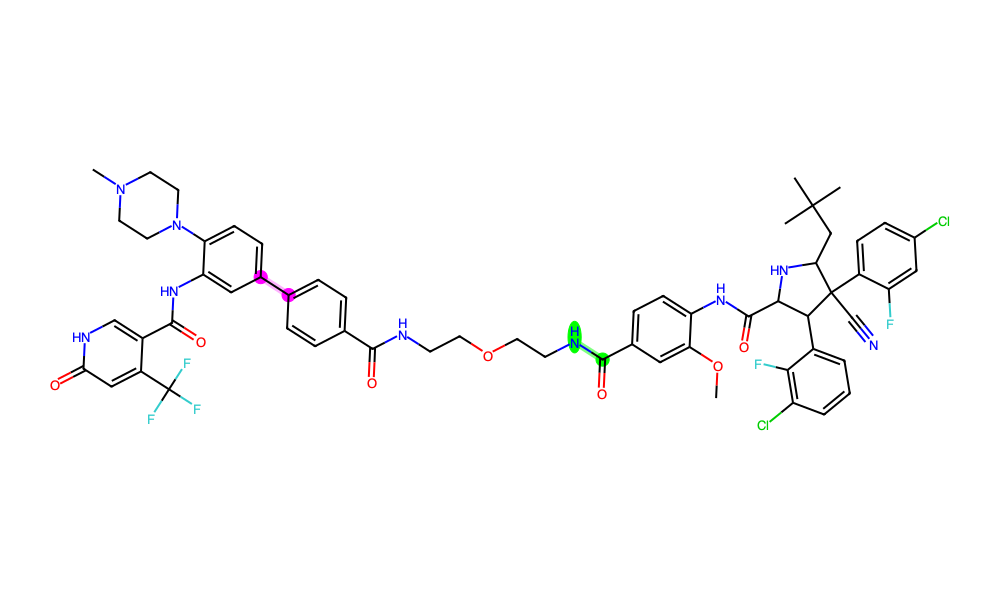

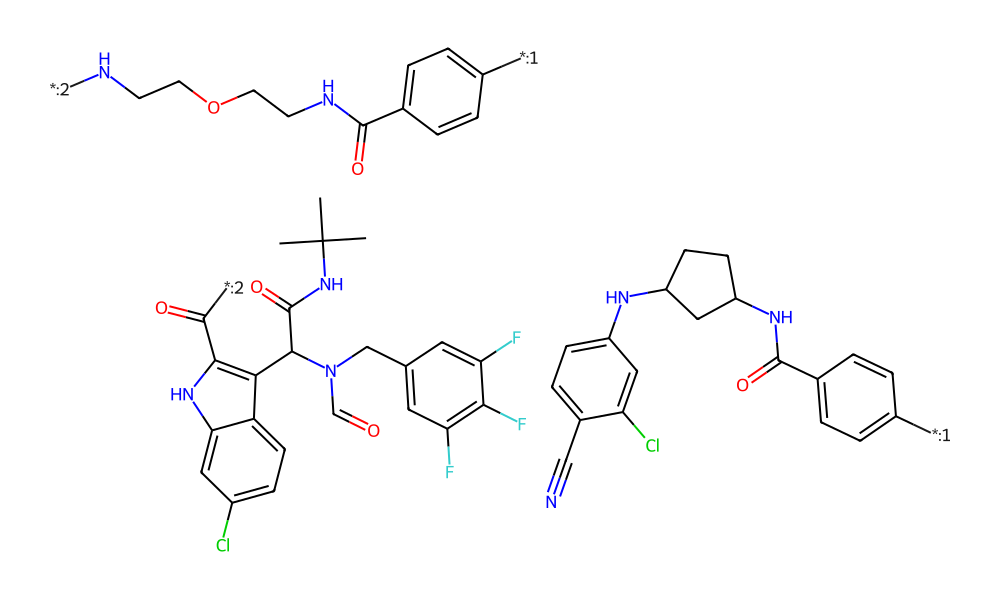

----------------------------------------------------------------------------------------------------
PROTAC:  Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@@H](CC(=O)N2CCC(N3CCC(C#Cc4ccc(C(=O)N[C@H]5C(C)(C)[C@H](Oc6ccc(C#N)c(Cl)c6)C5(C)C)cc4)CC3)CC2)c2ccc(Cl)cc2)C(C)C)on1
Ligands: CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1.Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)[*:2])C(C)C)on1.O=C(C[C@H](N[*:2])c1ccc(Cl)cc1)N1CCC(N2CCC(C#C[*:1])CC2)CC1
Pred:    Cc1cc([C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)[*:2])C(C)C)on1.O=C(C[C@H](N[*:2])c1ccc(Cl)cc1)N1CCC(N2CCC(C#C[*:1])CC2)CC1.CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1


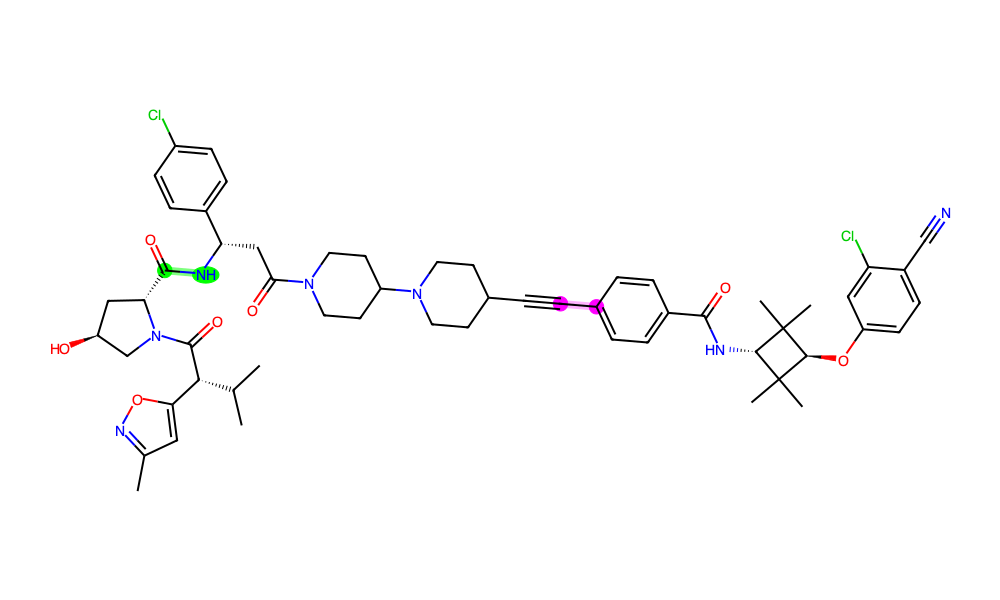

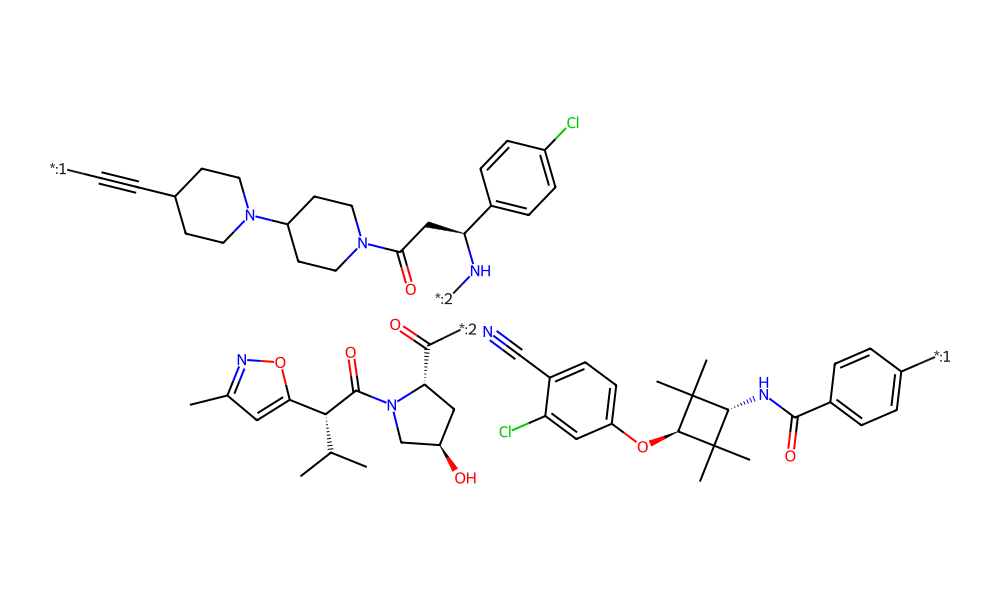

----------------------------------------------------------------------------------------------------
PROTAC:  Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)N[C@@H](CC(=O)N2CC(N3CCC(C#Cc4ccc(C(=O)N[C@H]5C(C)(C)[C@H](Oc6ccc(C#N)c(Cl)c6)C5(C)C)cc4)CC3)C2)c2ccccc2)C(C)C)on1
Ligands: CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1.Cc1cc([C@H](C(=O)N2C[C@@H](O)C[C@@H]2C(=O)[*:2])C(C)C)on1.O=C(C[C@H](N[*:2])c1ccccc1)N1CC(N2CCC(C#C[*:1])CC2)C1
Pred:    Cc1cc([C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)[*:2])C(C)C)on1.O=C(C[C@H](N[*:2])c1ccccc1)N1CC(N2CCC(C#C[*:1])CC2)C1.CC1(C)[C@H](NC(=O)c2ccc([*:1])cc2)C(C)(C)[C@H]1Oc1ccc(C#N)c(Cl)c1


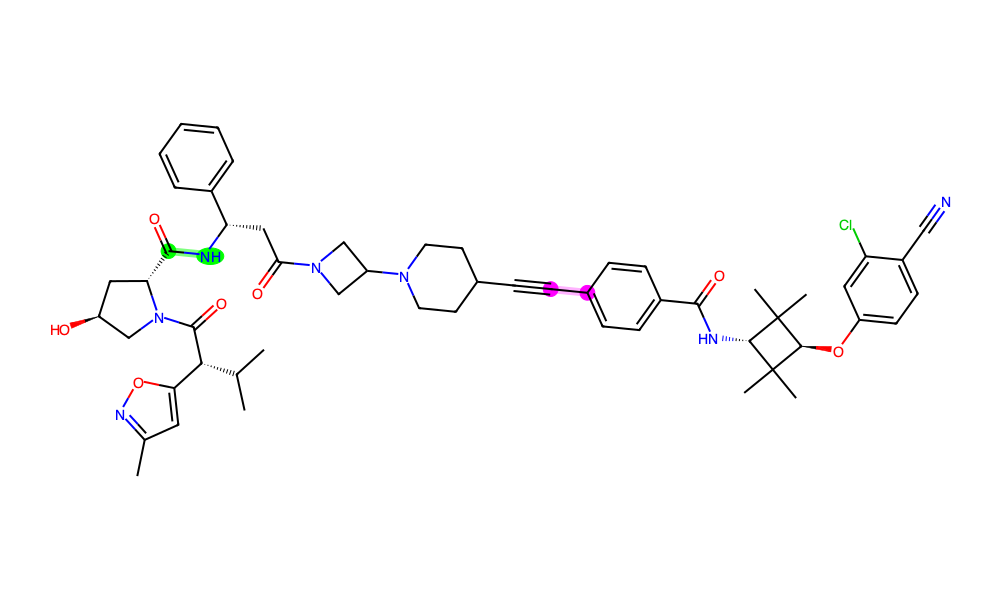

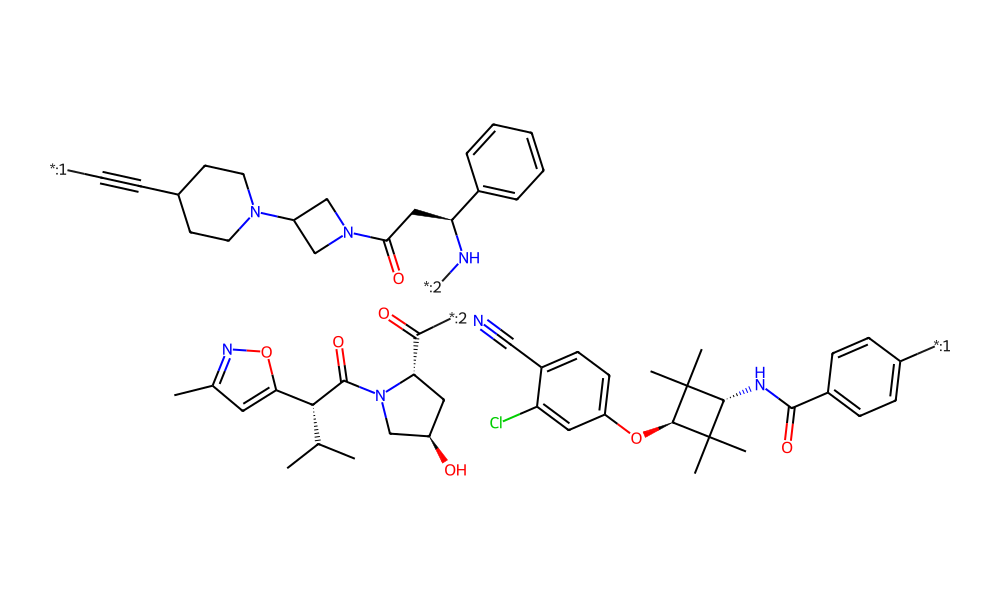

--------------------------------------------------------------------------------
Number of failed reassembly predictions with only linker not in train: 14 (6.64% of failing, 0.25% of total)
--------------------------------------------------------------------------------
PROTAC:  Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCOCCOCCOCCNC(=O)CN3CCOc4cc(N(CCC#N)C(=O)CCl)ccc43)CC2)n1
Ligands: Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CCO[*:1])CC2)n1.N#CCCN(c1ccc2c(c1)OCCN2CC(=O)NCCOCCOCC[*:1])[*:2].O=C(CCl)[*:2]
Pred:    O=C(CCl)[*:2].CN(CCOCCOCCOCCN[*:2])C[*:1].Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3Cl)s2)cc(N2CCN(CC(=O)[*:1])CC2)n1


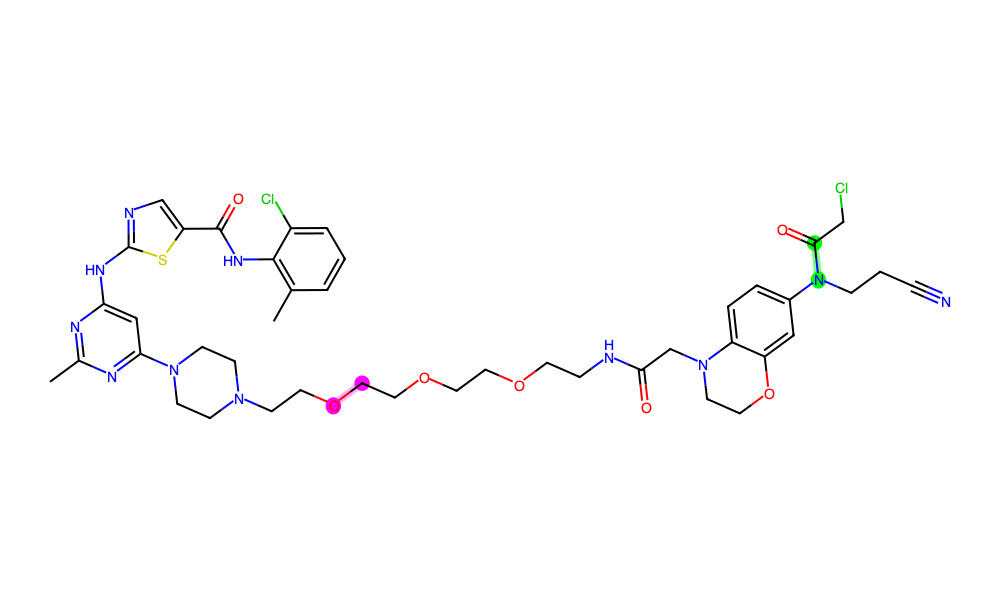

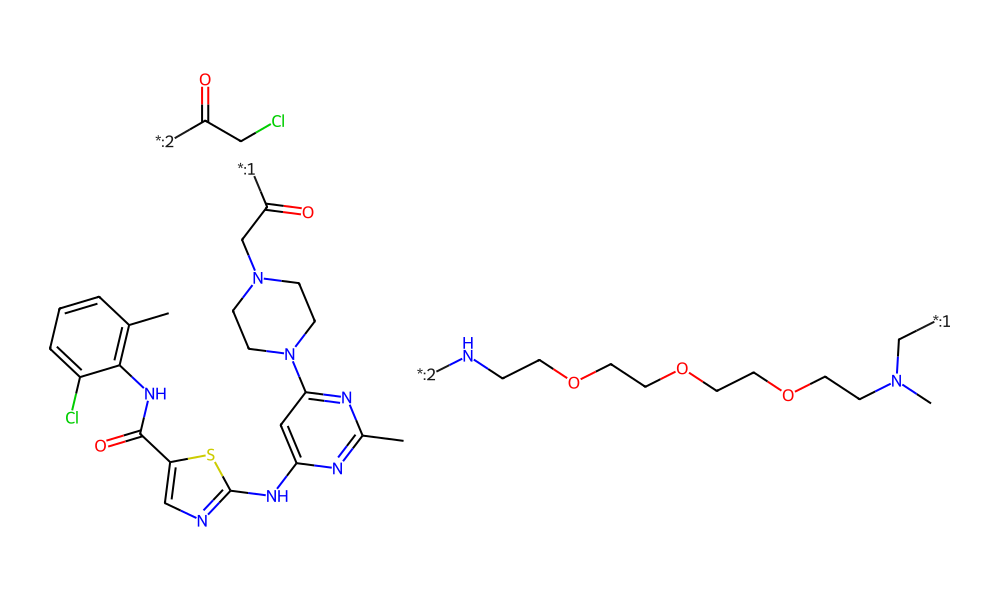

----------------------------------------------------------------------------------------------------
PROTAC:  Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCCOCCCCOCCCCOCCCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)C(C)(C)C)cc1
Ligands: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N[*:2])C(C)(C)C)cc1.O=C(CCCCCOCCCCOCCCCOCCCCN[*:1])[*:2].O=C1CCC(N2C(=O)c3cccc([*:1])c3C2=O)C(=O)N1
Pred:    O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(CCO[*:2])COCCCC[*:1].Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CO[*:1])C(C)(C)C)cc1


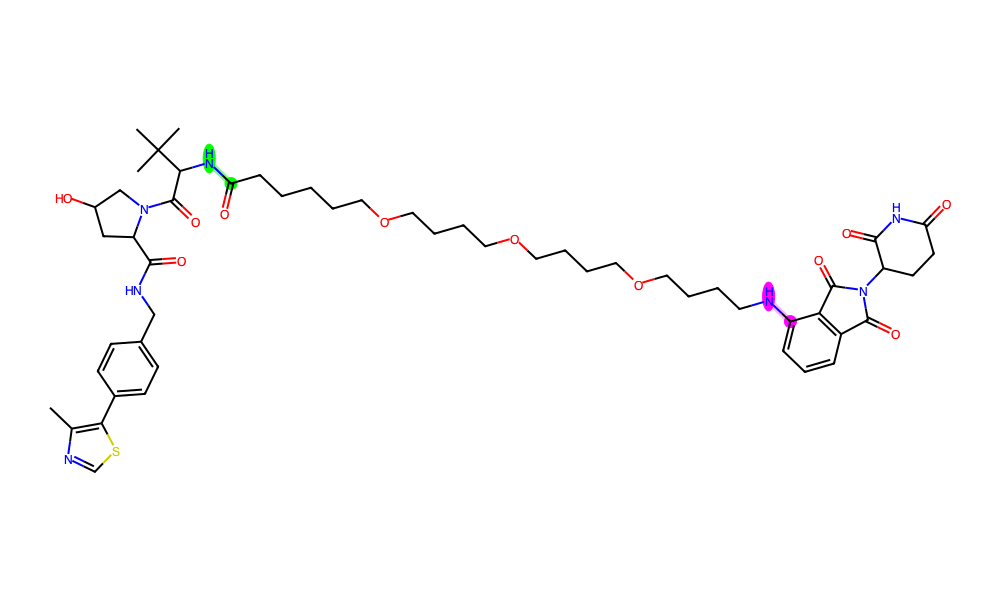

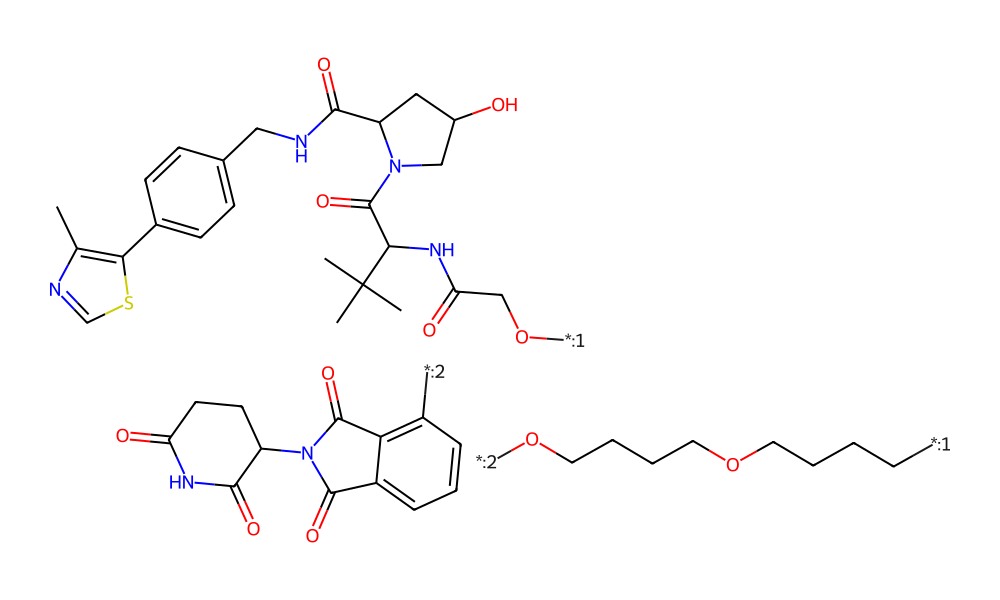

----------------------------------------------------------------------------------------------------
PROTAC:  COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5)c(F)c4)c3n2)ccc1OCCCN1CCN(CCCCCCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)CC1
Ligands: COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5)c(F)c4)c3n2)ccc1OCC[*:1].Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N[*:2])C(C)(C)C)cc1.O=C(CCCCCCCCCN1CCN(C[*:1])CC1)[*:2]
Pred:    Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CO[*:2])C(C)(C)C)cc1.C(CCCN1CCN([*:1])CC1)CCC[*:2].COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5)c(F)c4)c3n2)ccc1OCC[*:1]


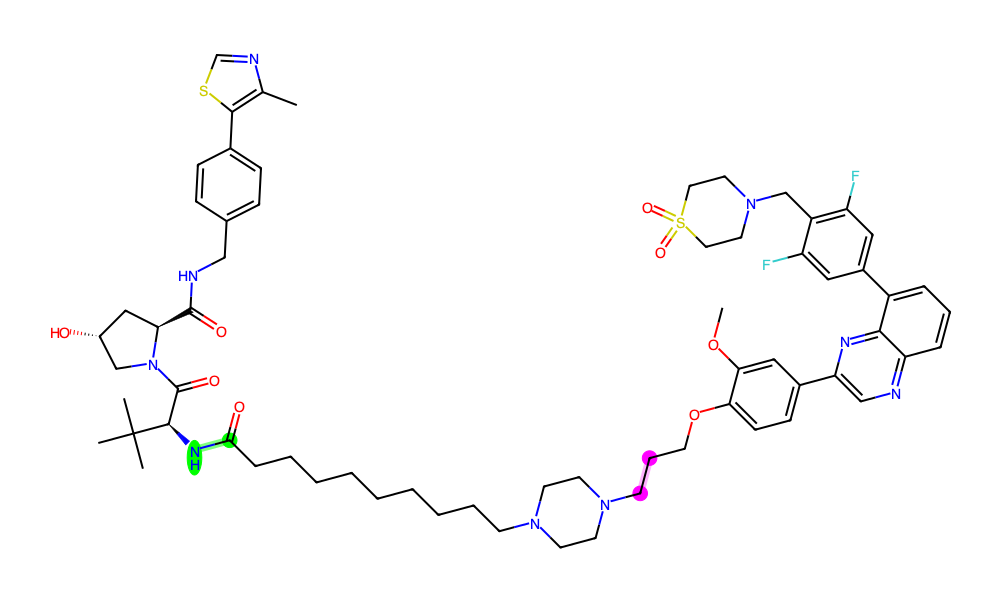

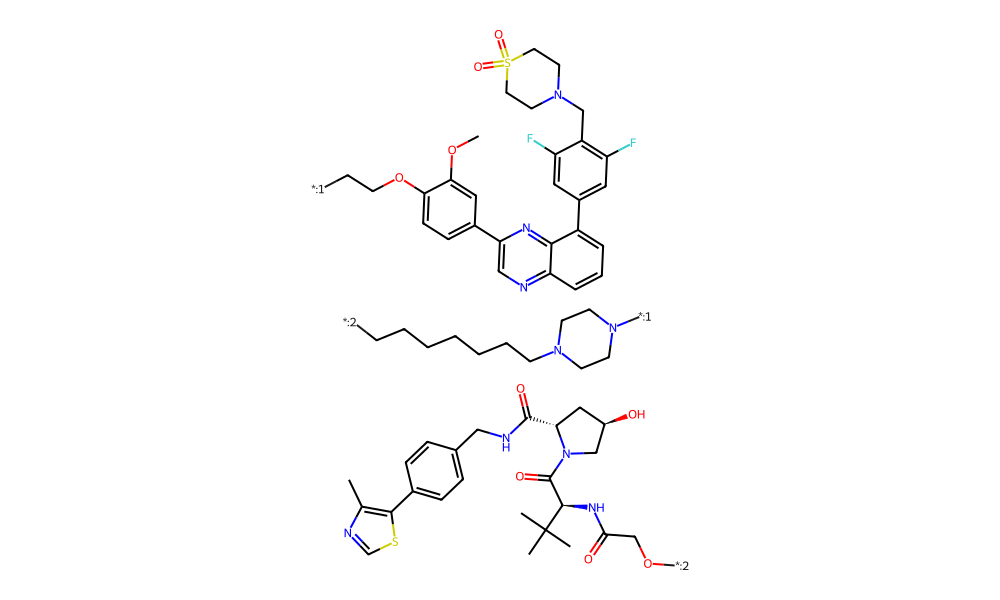

----------------------------------------------------------------------------------------------------
PROTAC:  COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5)c(F)c4)c3n2)ccc1OCCCN1CCN(CCCCCCCCCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)CC1
Ligands: COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5)c(F)c4)c3n2)ccc1OCC[*:1].Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(N[*:2])C(C)(C)C)cc1.O=C(CCCCCCCCCN1CCN(C[*:1])CC1)[*:2]
Pred:    Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)CO[*:2])C(C)(C)C)cc1.C(CCCN1CCN([*:1])CC1)CCC[*:2].COc1cc(-c2cnc3cccc(-c4cc(F)c(CN5CCS(=O)(=O)CC5)c(F)c4)c3n2)ccc1OCC[*:1]


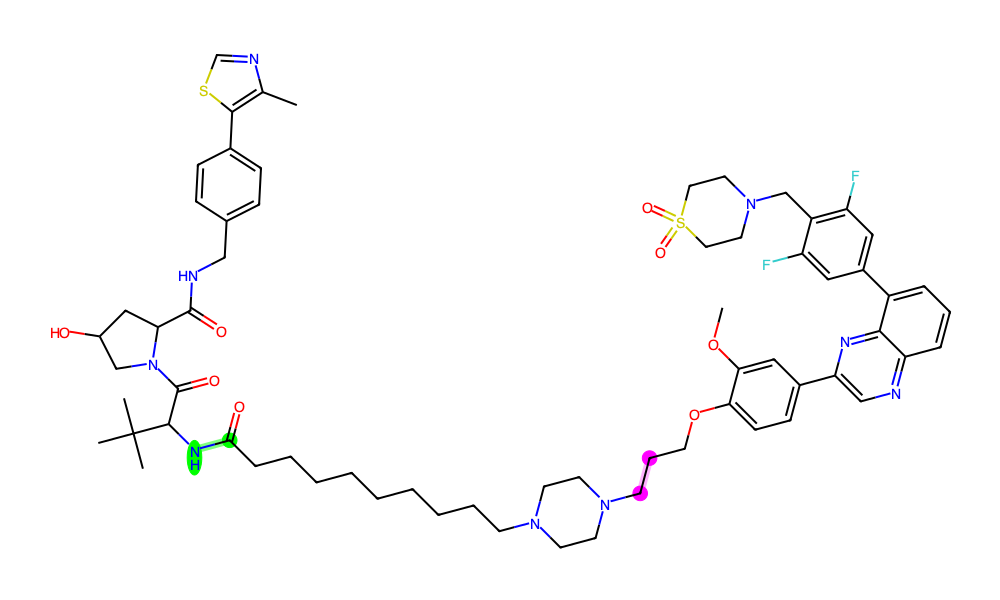

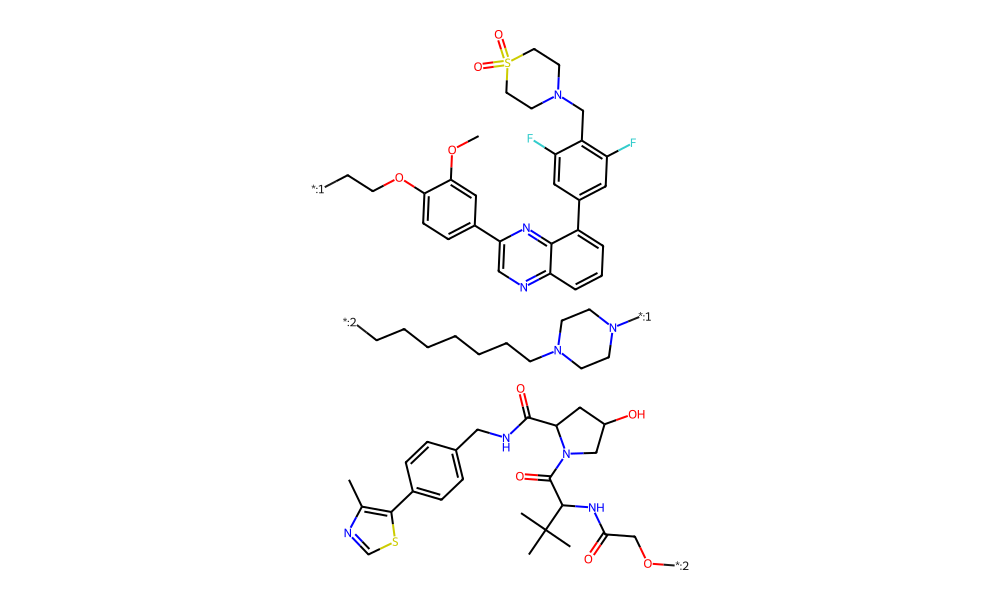

----------------------------------------------------------------------------------------------------
PROTAC:  Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCOCCCCOCCCCOCCCCNc2cccc3c2C(=O)N(C2CCC(=O)NC2=O)C3=O)C(C)(C)C)cc1
Ligands: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N[*:2])C(C)(C)C)cc1.O=C(CCCCCOCCCCOCCCCOCCCCN[*:1])[*:2].O=C1CCC(N2C(=O)c3cccc([*:1])c3C2=O)C(=O)N1
Pred:    O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(CCO[*:2])COCCCC[*:1].Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CO[*:1])C(C)(C)C)cc1


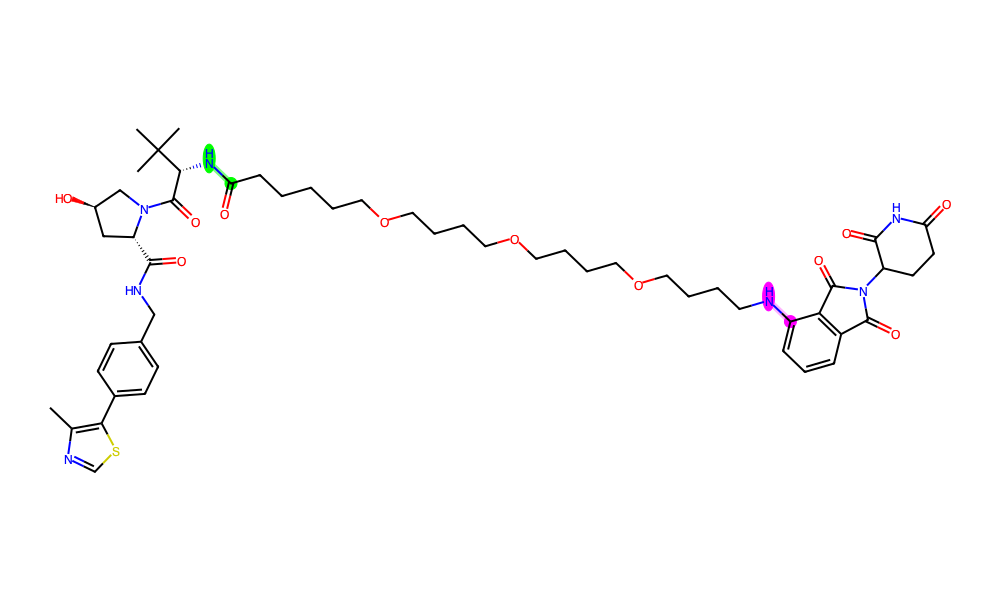

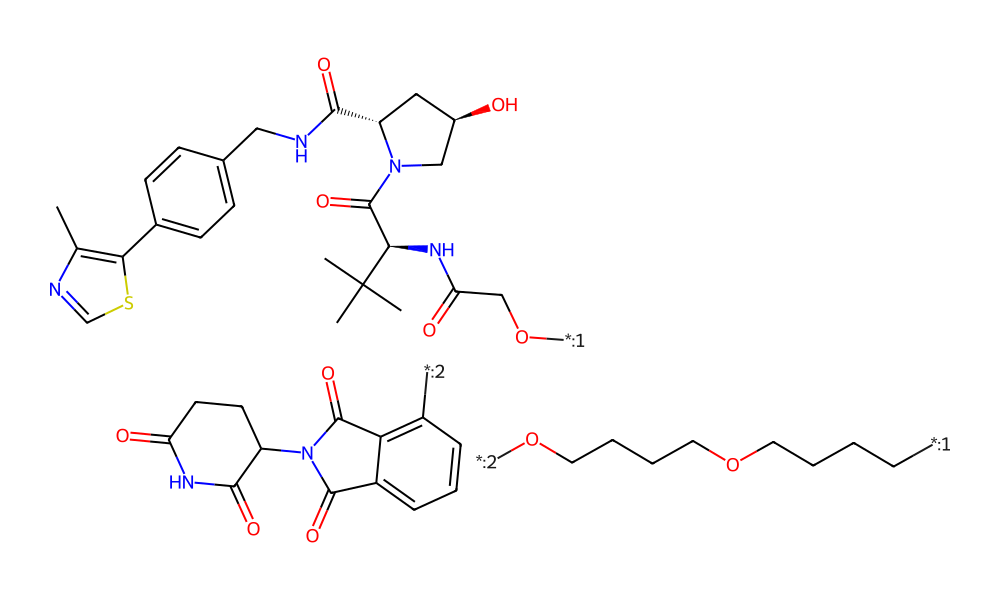

--------------------------------------------------------------------------------
Number of failed reassembly predictions with only poi not in train: 68 (32.23% of failing, 1.20% of total)
--------------------------------------------------------------------------------
PROTAC:  NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CCCN(C(=O)COCCOCCOCCOCCOCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)C2)c1N
Ligands: NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CCCN([*:1])C2)c1N.O=C(COCCOCCOCCOCCOCCN[*:2])[*:1].O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1
Pred:    O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C(COCCOCCOCCOCCOCCN[*:2])[*:1].NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn(C2CCCN([*:1])C2)c1N


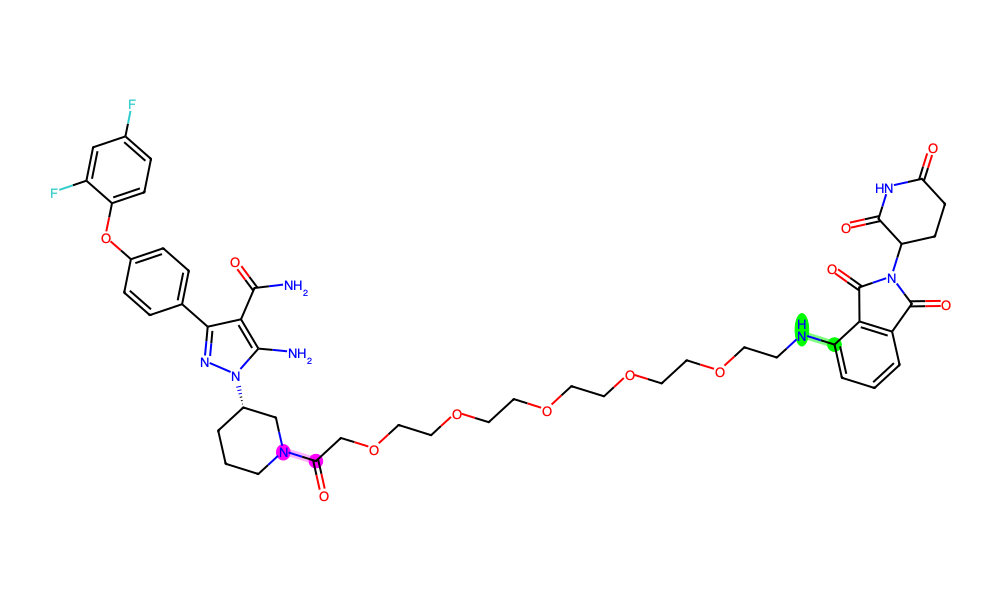

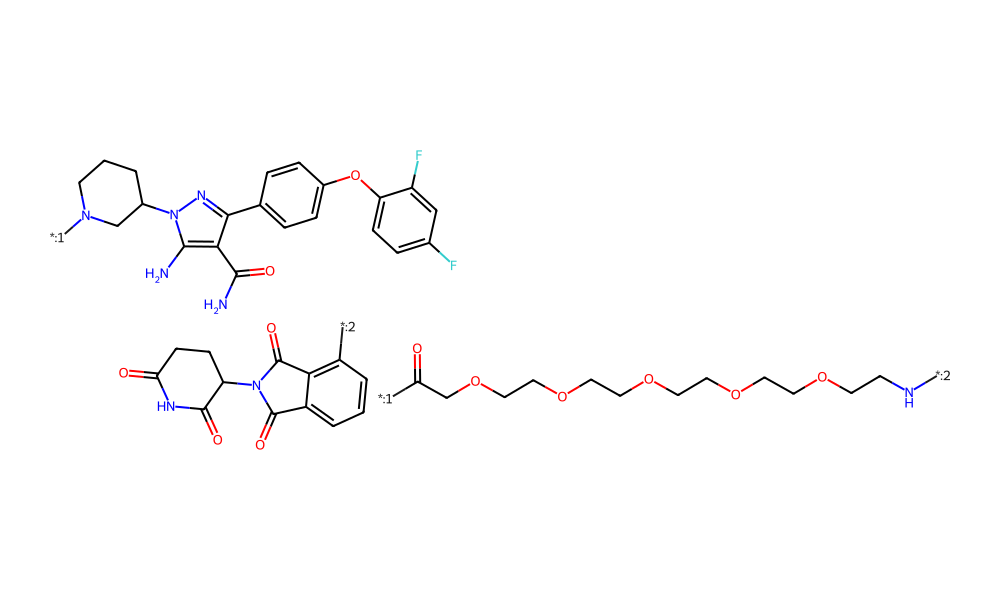

----------------------------------------------------------------------------------------------------
PROTAC:  CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(C)C4CCN(C(=O)CCCCNc5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)ccc32)c1F
Ligands: CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(C)C4CCN([*:1])CC4)ccc32)c1F.O=C(CCCCN[*:2])[*:1].O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1
Pred:    O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.O=C(CCCCN[*:2])N1CCC(N[*:1])CC1.Cc1ccc(F)c(S(=O)(=O)Nc2ccc(-c3nc(OCC4CN([*:1])CCO4)c4cn[nH]c4n3)cc2)c1


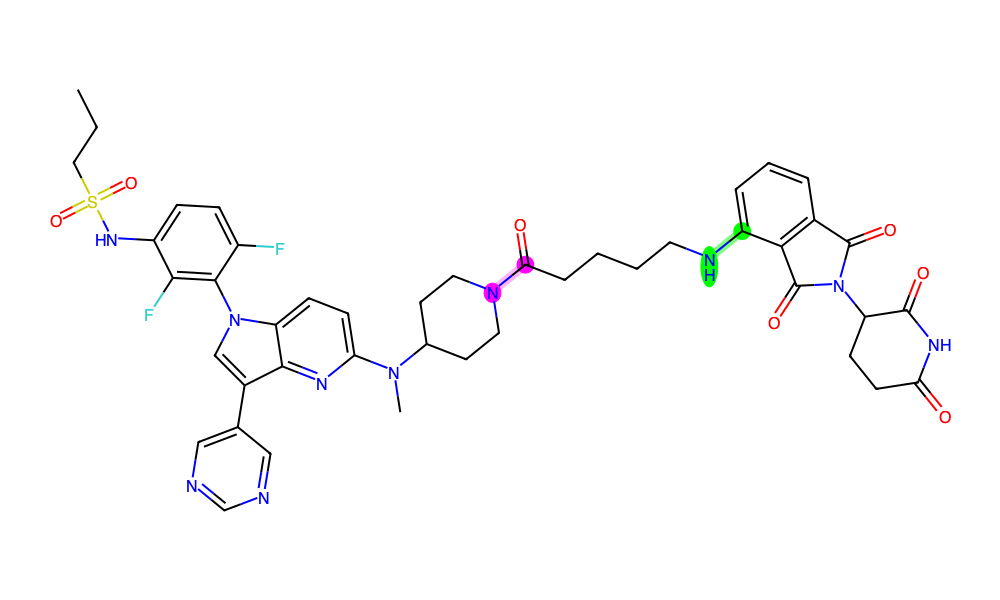

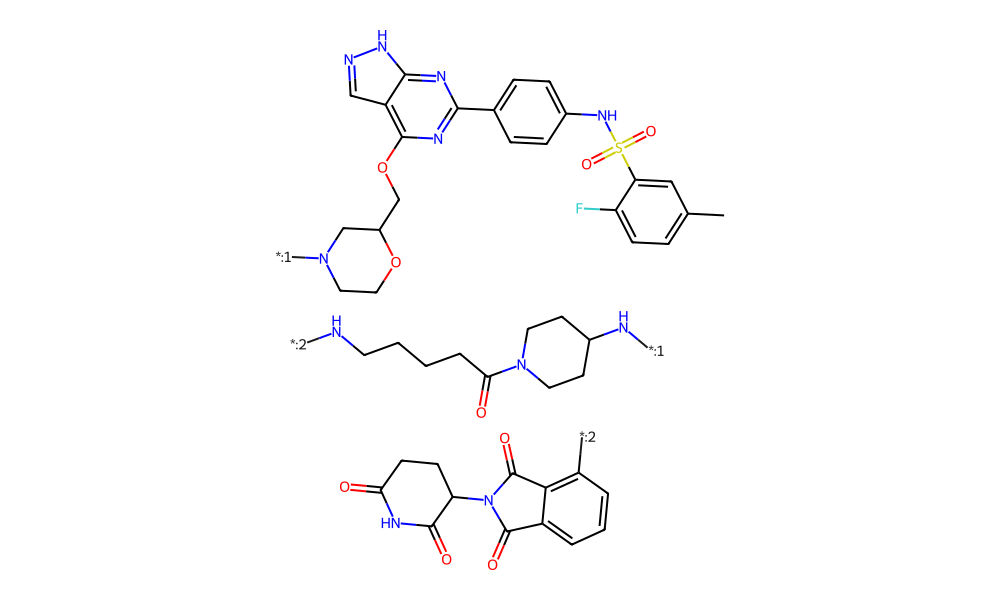

----------------------------------------------------------------------------------------------------
PROTAC:  CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(C)C4CCN(C(=O)CCOCCOCCOCCOCC#Cc5cccc6c5CN(C5CCC(=O)NC5=O)C6=O)CC4)ccc32)c1F
Ligands: CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(C)C4CCN([*:1])CC4)ccc32)c1F.O=C(CCOCCOCCOCCOCC#C[*:2])[*:1].O=C1CCC(N2Cc3c(cccc3[*:2])C2=O)C(=O)N1
Pred:    O=C1CCC(N2Cc3c(cccc3[*:2])C2=O)C(=O)N1.O=C(CCOCCOCCOCCOCC#C[*:2])N1CCC(N2CCC(C#C[*:1])CC2)CC1.Cc1ccc(F)c(S(=O)(=O)Nc2ccc(-c3nc(OCC4CN([*:1])CCO4)c4cn[nH]c4n3)cc2)c1


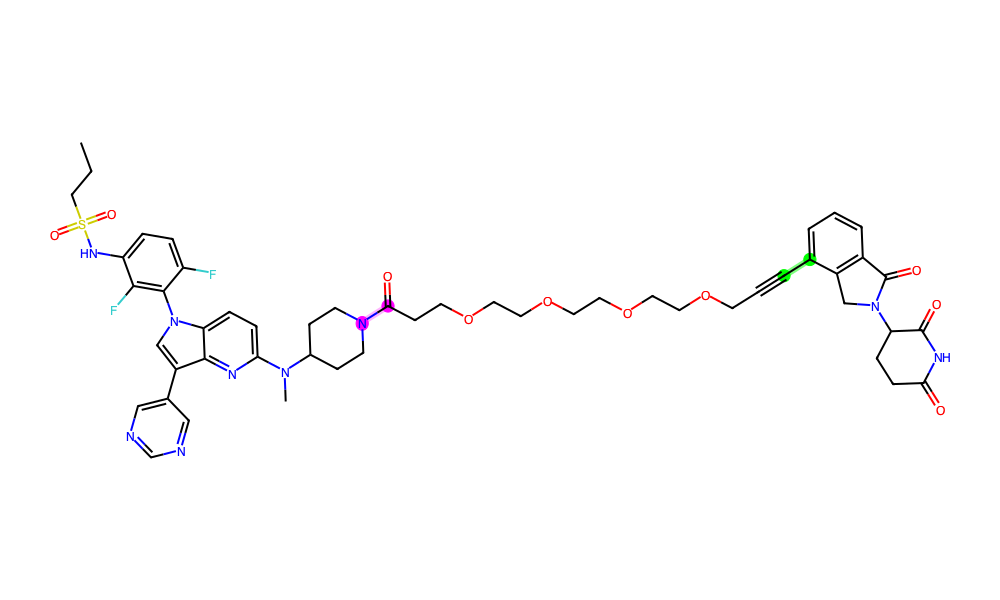

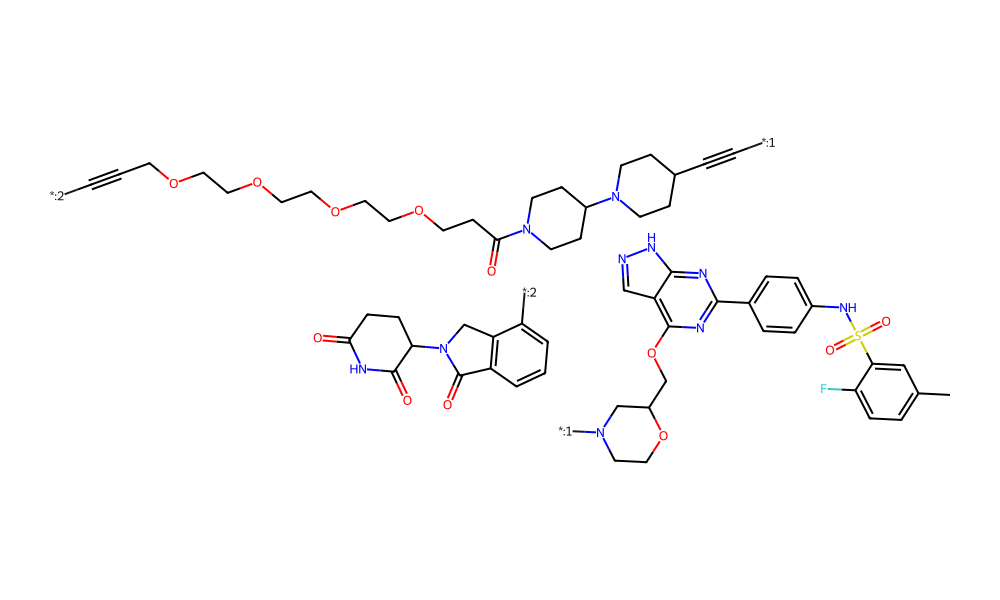

----------------------------------------------------------------------------------------------------
PROTAC:  COc1cc(/C=C2\SC(=O)N(CCOCCC(=O)N[C@H](C(=O)N3C[C@H](O)C[C@H]3C(=O)NCc3ccc(-c4scnc4C)cc3)C(C)(C)C)C2=O)ccc1Oc1ccc(C#N)cc1C(F)(F)F
Ligands: COc1cc(/C=C2\SC(=O)N([*:1])C2=O)ccc1Oc1ccc(C#N)cc1C(F)(F)F.Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N[*:2])C(C)(C)C)cc1.O=C(CCOCC[*:1])[*:2]
Pred:    COc1cc(/C=C2\SC(=O)N([*:2])C2=O)ccc1Oc1ccc(C#N)cc1C(F)(F)F.O=C(CCOCC[*:1])[*:2].Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CO[*:1])C(C)(C)C)cc1


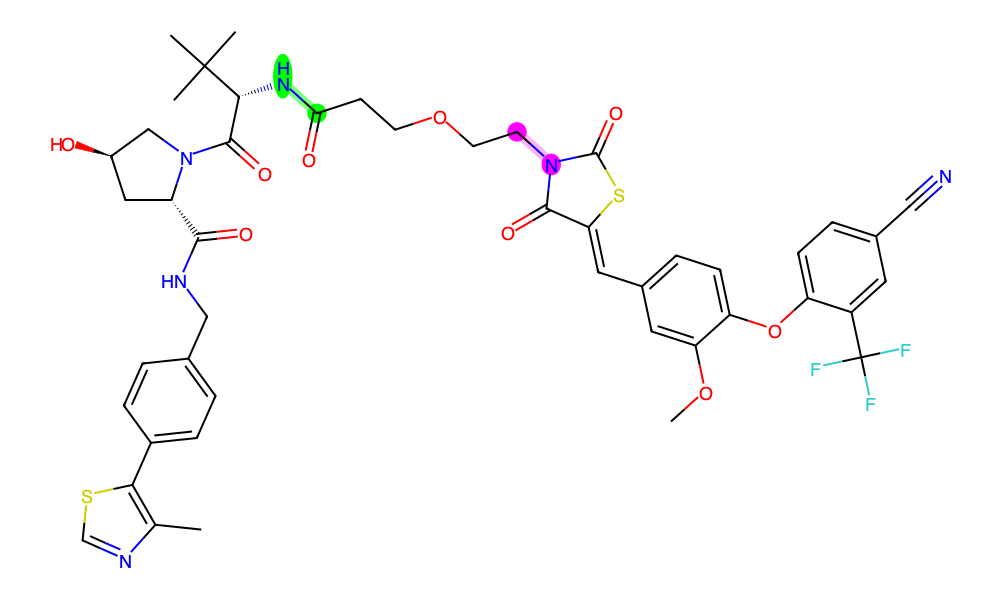

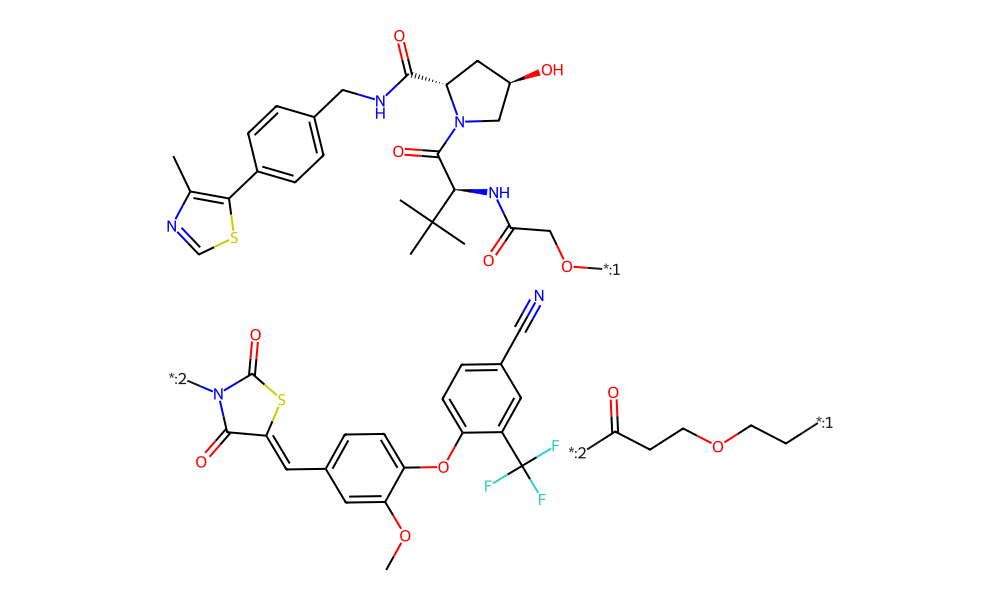

----------------------------------------------------------------------------------------------------
PROTAC:  NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CCCN(C(=O)OCCOCCOCCOCCOCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)C2)c1N
Ligands: C(COCCOCCOCCOCCO[*:1])N[*:2].NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CCCN(C(=O)[*:1])C2)c1N.O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1
Pred:    O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.C(COCCOCCOCCOCCO[*:1])N[*:2].NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn(C2CCCN(C(=O)[*:1])C2)c1N


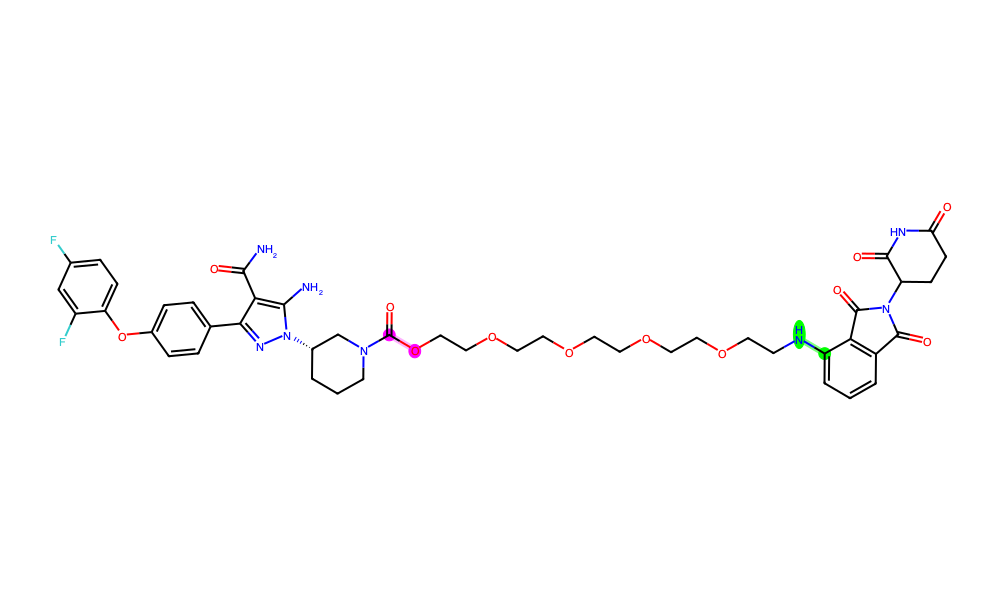

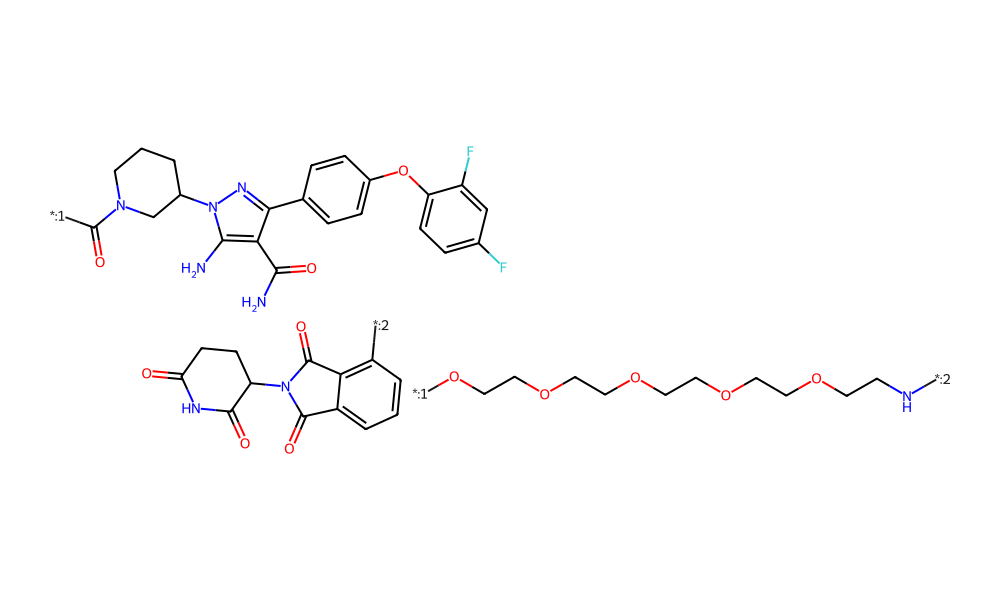

In [ ]:
from itertools import combinations
from IPython.display import Image
import cairosvg

def display_svg_as_png(svg_data: str):
    png_data = cairosvg.svg2png(bytestring=svg_data.encode('utf-8'))
    display(Image(data=png_data))


def display_df(df, max_displays=5):
    num_displayed = 0
    for i, row in df.sample(n=len(df), random_state=16).iterrows():
        protac_smiles = row['protac_smiles']
        ligands_smiles = row['label_smiles']
        pred_smiles = row['default_pred_n0']
        
        ligands = split_prediction(ligands_smiles)

        print(f"PROTAC:  {protac_smiles}")
        print(f"Ligands: {ligands_smiles}")
        print(f"Pred:    {pred_smiles}")

        svg = get_mapped_protac_img(
            protac_smiles,
            e3_smiles=ligands['e3'],
            linker_smiles=ligands['linker'],
            poi_smiles=ligands['poi'],
            w=1000,
            h=600,
            legend="",
            useSVG=True,
            display_image=False,
        )
        display_svg_as_png(svg)

        pred_mol = Chem.MolFromSmiles(pred_smiles)
        if pred_mol is not None:
            display_mol(pred_mol, w=1000, h=600, display_svg=False)
        else:
            preds = split_prediction(pred_smiles)
            e3_mol = Chem.MolFromSmiles(preds['e3']) if preds['e3'] is not None else None
            linker_mol = Chem.MolFromSmiles(preds['linker']) if preds['linker'] is not None else None
            poi_mol = Chem.MolFromSmiles(preds['poi']) if preds['poi'] is not None else None
            if e3_mol is not None:
                display_mol(e3_mol, w=1000, h=600, display_svg=False)
            else:
                print(f"Failed E3: {pred_smiles.split('.')[0]}")
                print(f"E3 label:  {ligands['e3']}")
            if linker_mol is not None:
                display_mol(linker_mol, w=1000, h=600, display_svg=False)
            else:
                print(f"Failed Linker: {pred_smiles.split('.')[1]}")
                print(f"Linker label:  {ligands['linker']}")
            if poi_mol is not None:
                display_mol(poi_mol, w=1000, h=600, display_svg=False)
            else:
                print(f"Failed POI: {pred_smiles.split('.')[-1]}")
                print(f"POI label:  {ligands['poi']}")
            
        num_displayed += 1
        if num_displayed == max_displays:
            break

        print('-' * 100)

# tmp = failed_reassembly[(~failed_reassembly['e3_in_train']) & (~failed_reassembly['poi_in_train']) & (~failed_reassembly['linker_in_train'])]
# print('-' * 80)
# print(f"Number of failed reassembly predictions with neither E3, Linker, nor POI in train: {len(tmp)} ({len(tmp) / len(failed_reassembly):.2%})")
# print('-' * 80)
# display_df(tmp, max_displays=5)

# # Get all pair combinations of ['e3', 'linker', 'poi']
# for l1, l2 in list(combinations(['e3', 'linker', 'poi'], 2)):
#     # print(f"Number of failed reassembly predictions with {l1} not in train and {l2} not in train
#     tmp = failed_reassembly[(~failed_reassembly[f'{l1}_in_train']) & (~failed_reassembly[f'{l2}_in_train'])].copy()
#     print('-' * 80)
#     print(f"Number of failed reassembly predictions with neither {l1.upper()} nor {l2.upper()} in train: {len(tmp)} ({len(tmp) / len(failed_reassembly):.2%})")
#     print('-' * 80)
#     display_df(tmp, max_displays=5)

for l in ['e3', 'linker', 'poi']:
    other_ligands = [x for x in ['e3', 'linker', 'poi'] if x != l]
    tmp = failed_reassembly[(~failed_reassembly[f'{l}_in_train']) & (failed_reassembly[f'{other_ligands[0]}_in_train']) & (failed_reassembly[f'{other_ligands[1]}_in_train'])]
    print('-' * 80)
    print(f"Number of failed reassembly predictions with only {l} not in train: {len(tmp)} ({len(tmp) / len(failed_reassembly):.2%} of failing, {len(tmp) / len(df_scores):.2%} of total)")
    print('-' * 80)
    display_df(tmp, max_displays=5)

---

In [ ]:
protac = "CN[C@@H](C)C(=O)N[C@H]1CCO[C@H]2CC(C)(C)[C@@H](C(=O)N[C@@H]3CCCc4cc(OCCOCCOCC(=O)N5CCN(CC[C@H](CSc6ccccc6)Nc6ccc(S(=O)(=O)NC(=O)c7ccc(N8CCN(CC9=C(c%10ccc(Cl)cc%10)CCC(C)(C)C9)CC8)cc7)cc6S(=O)(=O)C(F)(F)F)CC5)ccc43)N2C1=O"
label = "CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCN([*:1])CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1.CN[C@@H](C)C(=O)N[C@H]1CCO[C@H]2CC(C)(C)[C@@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O.O=C(COCCOCCO[*:2])[*:1]"
pred = "CN[C@H](C)C(=O)N[C@@H]1CCO[C@@H]2CC(C)(C)[C@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O.O=C(COCCOCCO[*:2])[*:1].CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCN([*:1])CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1"


CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCN([*:1])CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
O=C(COCCOCCO[*:2])[*:1]


CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCN([*:1])CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1
CN[C@@H](C)C(=O)N[C@H]1CCO[C@H]2CC(C)(C)[C@@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O
CN[C@H](C)C(=O)N[C@@H]1CCO[C@@H]2CC(C)(C)[C@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O
O=C(COCCOCCO[*:2])[*:1]


## Legacy Code

In [ ]:
csv_files = [f"../logs/{file}" for file in os.listdir("../logs") if file.endswith("-scores.csv")]
csv_file = [f for f in csv_files if "PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles" in f][0]

for ligand in ['protac', 'e3', 'poi', 'linker']:
    df = pd.read_csv(csv_file)

    # Get all columns that start with "default_pred_n"
    columns = [col for col in df.columns if col.startswith("beam_search_decoding_pred_n")]

    df = df[columns]

    # Remove the "default_pred_n0_" from the column names
    df.columns = df.columns.str.replace("default_pred_n0_", "")

    # Filter columns with "heavy_atoms_difference" and "num_fragments" and "has_three_substructures" and "is_fixed"
    df = df[df.columns[~df.columns.str.contains("heavy_atoms_difference|num_fragments|has_three_substructures|is_fixed|graph")]]

    # Filter all columns that do not contain "e3" or "poi" or "linker"
    if ligand == 'protac':
        df = df[df.columns[~df.columns.str.contains("e3|poi|linker")]]
        title = "Top-1 Mean PROTAC Metrics"
    elif ligand == 'e3':
        df = df[df.columns[df.columns.str.contains("e3")]]
        title = "Top-1 Mean E3 Metrics"
    elif ligand == 'poi':
        df = df[df.columns[df.columns.str.contains("poi_")]]
        title = "Top-1 Mean Warhead Metrics"
    elif ligand == 'linker':
        df = df[df.columns[df.columns.str.contains("linker")]]
        title = "Top-1 Mean Linker Metrics"

    # Remove the "default_pred_n0" column
    df = df[df.columns[~df.columns.str.contains("default_pred_n0")]]

    # Title case the column names
    df.columns = df.columns.str.split("_").str.join(" ").str.title()
    # Remove the "fixed" from the column names
    df.columns = df.columns.str.replace("Fixed", "(fixed)")

    # First convert boolean values to numeric (True = 1, False = 0)
    df = df.astype(float)

    # Bar-plot the values of the DataFrame
    # plt.figure(figsize=(20, 10))
    ax = sns.barplot(data=df, orient='h', errorbar='ci', color='C0')
    plt.xlabel("")
    plt.ylabel("")
    plt.title(title)
    plt.xlim(0, 1.1)
    plt.grid(axis='x', alpha=0.5)
    # For each bar in the plot, add the value at x=0.5, use ax.patches to get the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.2%}", (0.05, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=10, color='white')

    # Convert the x-axis to percentage
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
    plt.show()

In [ ]:
checkpoint_dir = "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/"

df = score_df[score_df['model_name'] == checkpoint_dir + "PROTAC-Splitter-EncoderDecoder-lr_reduce-rand-smiles"].copy()

# df['model_name'] = df['model_name'].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")

df = df[df['strategy'] == 'default']

# Filter metrics "heavy_atoms_difference" and "num_fzragments" and "has_three_substructures" and "is_fixed"
df = df[~df['metric'].str.contains("heavy_atoms_difference|num_fragments|has_three_substructures|is_fixed")]

# Filter all metrics that do not contain "e3" or "poi" or "linker"
df = df[~df['metric'].str.contains("e3|poi|linker")]

std_df = pd.DataFrame({
    'metric': df[df['reduce'] == 'std']['metric'],
    'std': df[df['reduce'] == 'std']['value'],
})

# Merge the standard deviation values with the main DataFrame
df = df.merge(std_df, on='metric', how='left')

df = df[df['reduce'] == 'mean']

# Title the metric names and remove the "fixed" suffix
df['metric'] = df['metric'].str.split("_").str.join(" ").str.title()
# df['metric'] = df['metric'].str.replace("Fixed", "(fixed)")
df['metric'] = df['metric'].str.replace(" Fixed", "")

# Convert the value column to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df['std'] = pd.to_numeric(df['std'], errors='coerce')

# Calculate the lower and upper bounds for the error bars
df['error_lower'] = df['value'] - df['std']
df['error_upper'] = df['value'] + df['std']
# Cap the upper to 1.0
df['error_upper'] = df['error_upper'].clip(upper=1.0)
# Cap the lower to 0.0
df['error_lower'] = df['error_lower'].clip(lower=0.0)

display(df)

# Bar-plot the values of the metrics with fixed as hue
# plt.figure(figsize=(15, 5))
# ax = sns.barplot(data=df, y='metric', x='value', hue='fixed', orient='h', errorbar=lambda x: (x['value'] - x['std'], x['value'] + x['std']))
ax = sns.barplot(data=df, y='metric', x='value', hue='fixed', orient='h', 
                 xerr=np.array([df['error_lower'], df['error_upper']]))
plt.title("")
plt.xlabel("")
plt.ylabel("Top-1 Mean Metric Value")
plt.xlim(0, 1.1)
plt.grid(axis='both', alpha=0.5)
# Convert the y-axis to percentage
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))

# # Add error bars manually
# for i, bar in enumerate(ax.patches):
#     width = bar.get_width()
#     std = df.iloc[i // 2]['std']  # Adjust index for hue
#     ax.errorbar(width, bar.get_y() + bar.get_height() / 2, xerr=std, fmt='none', c='black')

# Set the legend title to "Fixed Metric"
plt.legend(title="Fixed Metric", loc='upper right', labels=["No", "Yes"])
# Move the legend external and to the bottom, with two columns
plt.legend(title="Fixed Metric", loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=10)

plt.savefig("top_1_mean_metric.pdf", bbox_inches='tight')
plt.show()

In [ ]:
# Create a bar plot of the top-1 performance for each model
for model_name in score_df['model_name'].unique():
    if 'e3-wh-labels' in model_name:
        continue

    # Isolate the generation model_name
    df = score_df[score_df['model_name'] == model_name].copy()

    # Isolate the Top-1 and Mean values
    df = df[df['reduce'] == 'mean']
    df = df[df['top_n'] == 1]
    # df = df[df['fixed'] == False]

    df = df[['metric', 'value', 'strategy']]
    
    # Only include metrics: valid, reassembly, all_ligands_equal, heavy_atoms_difference
    metrics_to_plot = ['valid', 'reassembly', 'all_ligands_equal', 'heavy_atoms_difference_norm']
    metrics_to_plot += [f"{metric}_fixed" for metric in metrics_to_plot]
    df = df[df['metric'].isin(metrics_to_plot)]

    # Title the metric column
    df['metric'] = df['metric'].str.split("_").str.join(" ").str.title()
    df['metric'] = df['metric'].str.replace("Fixed", "(fixed)")

    # Title the strategy column
    df['strategy'] = df['strategy'].str.split("_").str.join(" ").str.title()

    # Sort the DataFrame by metric
    df = df.sort_values('metric')
    
    # Set the value column to numeric
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    sns.barplot(y='metric', x='value', hue='strategy', data=df, orient='h')
    # # Remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-" from the model_name
    model_name = model_name.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")
    plt.title(f"Top-1 Model Performance - {model_name}")
    plt.grid(axis='x', alpha=0.5)
    # Set the legend outside the plot on the bottom, with 4 columns
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
    # Remove both the x and y axis labels
    plt.xlabel(None)
    plt.ylabel(None)
    # Change the x-axis to a percentage
    plt.xticks(ticks=np.linspace(0, 1, 11), labels=[f"{int(i * 100)}%" for i in np.linspace(0, 1, 11)])
    plt.show()


# Create a bar plot of the top-1 performance for each model
for model_name in score_df['model_name'].unique():
    if 'e3-wh-labels' in model_name:
        continue

    # Isolate the generation model_name
    df = score_df[score_df['model_name'] == model_name].copy()

    # Isolate the Top-1 and Mean values
    df = df[df['reduce'] == 'mean']
    df = df[df['top_n'] == 5]
    # df = df[df['fixed'] == False]

    df = df[['metric', 'value', 'strategy']]
    
    # Only include metrics: valid, reassembly, all_ligands_equal, heavy_atoms_difference
    metrics_to_plot = ['valid', 'reassembly', 'all_ligands_equal', 'heavy_atoms_difference_norm']
    metrics_to_plot += [f"{metric}_fixed" for metric in metrics_to_plot]
    df = df[df['metric'].isin(metrics_to_plot)]

    # Title the metric column
    df['metric'] = df['metric'].str.split("_").str.join(" ").str.title()
    df['metric'] = df['metric'].str.replace("Fixed", "(fixed)")

    # Title the strategy column
    df['strategy'] = df['strategy'].str.split("_").str.join(" ").str.title()

    # Sort the DataFrame by metric
    df = df.sort_values('metric')
    
    # Set the value column to numeric
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    
    sns.barplot(y='metric', x='value', hue='strategy', data=df, orient='h')
    # # Remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-" from the model_name
    model_name = model_name.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")
    plt.title(f"Top-5 Model Performance - {model_name}")
    plt.grid(axis='x', alpha=0.5)
    # Set the legend outside the plot on the bottom, with 4 columns
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)
    # Remove both the x and y axis labels
    plt.xlabel(None)
    plt.ylabel(None)
    # Change the x-axis to a percentage
    plt.xticks(ticks=np.linspace(0, 1, 11), labels=[f"{int(i * 100)}%" for i in np.linspace(0, 1, 11)])
    # Set x-limit to 1.1 to show the full scale
    plt.xlim(0, 1.1)
    plt.show()

In [ ]:
import os
import pandas as pd

# Get all the scores files in the logs directory that have "Trial" and "scores" in their name
scores_files = [f for f in os.listdir('../logs') if 'Trial' in f and 'scores' in f and f.endswith('.csv')]
scores = pd.concat([pd.read_csv(os.path.join('../logs', f)) for f in scores_files])

print(f"Loaded {len(scores_files)} files.")
# for c in scores.columns:
#     print(c)

In [ ]:
# Rename the model_name column to remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/"
scores["model_name"] = scores["model_name"].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")

# # print(scores[[c for c in scores.columns if 'fixed_' in c and 'valid' in c]].isna().sum())
# # print(scores[[c for c in scores.columns if 'fixed_' not in c and 'valid' in c]].isna().sum())
# print(scores.groupby('model_name')[[c for c in scores.columns if 'fixed_' not in c and 'valid' in c]].sum())
# print(scores.groupby('model_name')[[c for c in scores.columns if 'fixed_' in c and 'valid' in c]].sum())

In [ ]:
from tqdm import tqdm
import pandas as pd

# Function to determine the best value for a given metric
def best_value(metric, values):
    """ Determine the best value based on metric type (boolean, higher is better, lower is better, closest to zero). """

    max_metrics = ["has_three_substructures", "has_all_attachment_points", "valid", "reassembly", "reassembly_nostereo",
                  "all_ligands_equal", "e3_valid", "e3_equal", "e3_has_attachment_point(s)",
                  "poi_valid", "poi_equal", "poi_has_attachment_point(s)",
                  "linker_valid", "linker_equal", "linker_has_attachment_point(s)", "num_fragments"]
    min_metrics = ["e3_graph_edit_distance", "e3_graph_edit_distance_norm",
                   "poi_graph_edit_distance", "poi_graph_edit_distance_norm",
                   "linker_graph_edit_distance", "linker_graph_edit_distance_norm"]
    zero_metrics = ["heavy_atoms_difference_norm", "e3_heavy_atoms_difference_norm",
                    "poi_heavy_atoms_difference_norm", "linker_heavy_atoms_difference_norm",
                    "heavy_atoms_difference", "e3_heavy_atoms_difference",
                    "poi_heavy_atoms_difference", "linker_heavy_atoms_difference"]

    max_metrics += [f"{metric}_fixed" for metric in max_metrics]
    min_metrics += [f"{metric}_fixed" for metric in min_metrics]
    zero_metrics += [f"{metric}_fixed" for metric in zero_metrics]

    if metric in max_metrics:
        values = values.fillna(False).values
        return max(values)  # Boolean or binary indicators: True (1) is better

    elif metric in min_metrics:
        values = values.fillna(max(values)).values
        return min(values)  # Lower is better

    elif metric in zero_metrics:
        values = values.fillna(min(abs(values))).values
        return min(values, key=lambda x: abs(x))  # Closest to zero is better

    else:
        return None  # If metric is unknown, return None


# Extract model names
models = scores["model_name"].unique()

# List of metrics to compute
metrics = [
    "has_three_substructures", "has_all_attachment_points", "num_fragments", "valid",
    "reassembly", "reassembly_nostereo", "heavy_atoms_difference", "heavy_atoms_difference_norm",
    "all_ligands_equal", "e3_valid", "e3_equal", "e3_has_attachment_point(s)",
    "e3_graph_edit_distance", "e3_graph_edit_distance_norm", "e3_heavy_atoms_difference", "e3_heavy_atoms_difference_norm",
    "poi_valid", "poi_equal", "poi_has_attachment_point(s)", "poi_graph_edit_distance", "poi_graph_edit_distance_norm",
    "poi_heavy_atoms_difference", "poi_heavy_atoms_difference_norm", "linker_valid", "linker_equal",
    "linker_has_attachment_point(s)", "linker_graph_edit_distance", "linker_graph_edit_distance_norm",
    "linker_heavy_atoms_difference", "linker_heavy_atoms_difference_norm"
]

pd.set_option('future.no_silent_downcasting', True)

# Create a new DataFrame to store results
results = []

beam_size = 5

# Compute Top-1 and Top-5 metrics for each model
for model in tqdm(models):
    model_df = scores[scores["model_name"] == model]

    row_top1 = {"model_name": model, "type": "default_top1"}
    row_top5 = {"model_name": model, "type": "default_top5"}
    row_fixed_top1 = {"model_name": model, "type": "fixed_top1"}
    row_fixed_top5 = {"model_name": model, "type": "fixed_top5"}

    for metric in metrics:
        pred_cols = [f"pred_n{i}_{metric}" for i in range(beam_size)]
        fixed_pred_cols = [f"fixed_pred_n{i}_{metric}" for i in range(beam_size)]

        # Compute Top-1 (prediction 0 only)
        row_top1[metric] = model_df[f"pred_n0_{metric}"].mean()
        row_fixed_top1[metric] = model_df[f"fixed_pred_n0_{metric}"].mean()

        # Compute Top-5 (best among pred_0 to pred_4)
        row_top5[metric] = model_df[pred_cols].apply(lambda x: best_value(metric, x), axis=1).mean()
        row_fixed_top5[metric] = model_df[fixed_pred_cols].apply(lambda x: best_value(metric, x), axis=1).mean()

    results.extend([row_top1, row_top5, row_fixed_top1, row_fixed_top5])

# Convert results to DataFrame
final_results_df = pd.DataFrame(results)

In [ ]:
scores_w_best = scores.copy()

# Add a column to store the best value for each metric
for metric in tqdm(metrics, desc="Computing best values"):
    scores_w_best[f"best_{metric}"] = scores_w_best[[f"pred_n{i}_{metric}" for i in range(beam_size)]].apply(lambda x: best_value(metric, x), axis=1)
    scores_w_best[f"fixed_best_{metric}"] = scores_w_best[[f"fixed_pred_n{i}_{metric}" for i in range(beam_size)]].apply(lambda x: best_value(metric, x), axis=1)

scores_w_best

In [ ]:
from matplotlib import pyplot as plt
import matplotlib as mpl
from rdkit import Chem
from rdkit.Chem import Draw

tmp = scores_w_best[scores_w_best["model_name"] == "Trial-11"]

# Rename the columns in title form
tmp.columns = [c.replace("_", " ").title() for c in tmp.columns]

# Prefix columns without "Best" with "Top-1 "
tmp.columns = ["Top-1 " + c if "Best" not in c else c for c in tmp.columns]

# Rename "Best" in columns to "Top-5"
tmp.columns = [c.replace("Best", "Top-5") for c in tmp.columns]
tmp.columns = [c.replace("Fixed Top-5", "Top-5 (fixed)") for c in tmp.columns]

# Rename "Top-1 Fixed" in columns to "Top-1 (fixed)"
tmp.columns = [c.replace("Top-1 Fixed", "Top-1 (fixed)") for c in tmp.columns]
tmp.columns = [c.replace("Top-5 Fixed", "Top-5 (fixed)") for c in tmp.columns]

# Replace "Top-1 Pred N0 " with " "
tmp.columns = [c.replace(" Pred N0 ", " ") for c in tmp.columns]

metrics_cols = ["Valid", "All Ligands Equal", "Reassembly", "Reassembly Nostereo"]
top1_cols = ["Top-1 " + c for c in metrics_cols]
top1_fix_cols = ["Top-1 (fixed) " + c for c in metrics_cols]
top5_cols = ["Top-5 " + c for c in metrics_cols]
top5_fix_cols = ["Top-5 (fixed) " + c for c in metrics_cols]

# --------------------------------------------
# Plot predictions with heavy atoms difference

def get_sub(smi, sub):
    splits = smi.split(".")
    for split in splits:
        if sub == 'linker' and "[*:2]" in split and "[*:1]" in split:
            return split
        elif sub == 'poi' and "[*:1]" in split and "[*:2]" not in split:
            return split
        elif sub == 'e3' and "[*:1]" not in split and "[*:2]" in split:
            return split

worst_df = tmp[abs(tmp["Top-1 Heavy Atoms Difference"]) > 50]
display(worst_df)
for i, row in worst_df.iterrows():
    print(row["Top-1 Heavy Atoms Difference"])
    print(row["Top-1 Heavy Atoms Difference Norm"])
    print(f'Full protac: {row["Top-1 Protac Smiles"]}')
    print(f'Full label:  {row["Top-1 Label Smiles"]}')
    print(f'Full pred:   {row["Top-1 Default Pred N0"]}')
    # Display PROTAC and its ligands
    print(row["Top-1 Protac Smiles"])
    display(Draw.MolToImage(Chem.MolFromSmiles(row["Top-1 Protac Smiles"]), size=(1000, 600)))
    display(Draw.MolToImage(Chem.MolFromSmiles(row["Top-1 Label Smiles"]), size=(1000, 600)))
    try:
        display(Draw.MolToImage(Chem.MolFromSmiles(row["Top-1 Default Pred N0"]), size=(1000, 600)))
    except Exception as e:
        print(e)
    
    print('=' * 50)
    
    for j, sub in enumerate(['e3', 'poi', 'linker']):
        lab = get_sub(row["Top-1 Label Smiles"], sub)
        if row["Top-1 Heavy Atoms Difference"] > 20:
            if sub == 'e3':
                smi = get_sub(row["Top-1 Default Pred N0"], 'poi')
            elif sub == 'poi':
                smi = get_sub(row["Top-1 Default Pred N0"], 'e3')
            else:
                smi = get_sub(row["Top-1 Default Pred N0"], 'linker')
        else:
            smi = get_sub(row["Top-1 Default Pred N0"], sub)
        print('Label:     ', lab)
        print('Prediction:', smi)
        try:
            display(Draw.MolToImage(Chem.MolFromSmiles(smi, sanitize=False), size=(1000, 600), legend=f"Ligand {sub.title()}: {smi}"))
        except:
            print('Could not display molecule')
    print('-' * 100)

# --------------------------------------------
# Top-1 scores
tmp.to_csv('~/Downloads/tmp.csv')

# Horizontal bar plot `tmp` DataFrame and use standard deviation as error bars
plt.figure(figsize=(3, 4))
sns.boxplot(data=tmp[top1_cols], orient='h', color='C0')
sns.boxplot(data=tmp[top1_fix_cols], orient='h', color='C1')
plt.yticks(rotation=0)
# plt.title("Top-1 and Top-5 scores for different metrics")
plt.grid(axis='x', alpha=0.5)
# Add the corresponding mean values on the bars at x=0.1
for i, v in enumerate(tmp[top1_cols + top1_fix_cols].mean()):
    plt.text(0.05, i, f"{v:>.2%}", va='center')
# Set the x-axis as percentage
plt.gca().xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.title("Top-1 scores")
plt.show()

# ============================================

# Create a figure with two subplots for a broken x-axis
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(6, 4), gridspec_kw={'width_ratios': [1, 1]})

# Plot on the first axis (ax1) focusing on the 0-5% range
sns.boxplot(data=tmp[top1_cols + top1_fix_cols], orient='h', ax=ax1, color='C0')
ax1.set_xlim(-0.05, 0.05)
ax1.set_xlabel("Score (0-5%)")
ax1.spines['right'].set_visible(False)
ax1.yaxis.tick_left()

# Plot on the second axis (ax2) focusing on the 90-100% range
sns.boxplot(data=tmp[top1_cols + top1_fix_cols], orient='h', ax=ax2, color='C0')
ax2.set_xlim(0.999, 1.001)
ax2.set_xlabel("Score (99-101%)")
ax2.spines['left'].set_visible(False)
ax2.yaxis.tick_right()

# Add diagonal lines to indicate the break
d = .015  # Size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the second axis
ax2.plot((-d, +d), (-d, +d), **kwargs)  # top-left diagonal
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal

# Set title and adjust layout
fig.suptitle("Top-1 Scores with Broken X-Axis")
plt.tight_layout()
plt.show()


# ============================================



# --------------------------------------------
# Top-5 scores

# Horizontal bar plot `tmp` DataFrame and use standard deviation as error bars
plt.figure(figsize=(3, 4))
sns.boxplot(data=tmp[top5_cols], orient='h', color='C0')
sns.boxplot(data=tmp[top5_fix_cols], orient='h', color='C1')
plt.yticks(rotation=0)
# plt.title("Top-1 and Top-5 scores for different metrics")
plt.grid(axis='x', alpha=0.5)
# Add the corresponding mean values on the bars at x=0.1
for i, v in enumerate(tmp[top5_cols + top5_fix_cols].mean()):
    plt.text(0.05, i, f"{v:>3.3%}", va='center')
# Set the x-axis as percentage
plt.gca().xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.title("Top-5 scores")
plt.show()

# --------------------------------------------

# Isolate the rows with "Top-5 Reassembly" and "Top-5 (fixed) Reassembly" False
tmp[(tmp["Top-1 Reassembly"] == False)]
metrics_cols = ["Heavy Atoms Difference"] #, "Heavy Atoms Difference Norm"]
top1_cols = ["Top-1 " + c for c in metrics_cols]
top1_fix_cols = ["Top-1 (fixed) " + c for c in metrics_cols]
top5_cols = ["Top-5 " + c for c in metrics_cols]
top5_fix_cols = ["Top-5 (fixed) " + c for c in metrics_cols]

# Horizontal box plot `tmp` DataFrame and use standard deviation as error bars
plt.figure(figsize=(12, 3))
sns.boxplot(data=tmp[top1_cols + top1_fix_cols + top5_cols + top5_fix_cols], orient='h', showmeans=True, meanline=True, meanprops={"color": "C0", "linestyle": "--"}, flierprops={"marker": "o", "markersize": 6, "markerfacecolor": "C1", "linestyle": "none"})

# plt.title("Top-1 and Top-5 scores for different metrics")
# Add the corresponding mean values on the bars at x=0.1
for i, c in enumerate(top1_cols + top1_fix_cols + top5_cols + top5_fix_cols):
    v = tmp[c].mean()
    if "Norm" in c:
        if v == 0:
            plt.text(0.9, i + 0.3, f"0.0%", va='center')
        else:
            plt.text(0.9, i + 0.3, f"{v:.4%}", va='center')
    else:
        if v == 0:
            plt.text(0.9, i + 0.3, "0.0", va='center')
        else:
            plt.text(0.9, i + 0.3, f"{v:.5f}", va='center')
# Set the x-axis grids every 10 units
plt.gca().xaxis.set_major_locator(mpl.ticker.MultipleLocator(10))
# Set the x-axis grids minors every 5 units
plt.gca().xaxis.set_minor_locator(mpl.ticker.MultipleLocator(5))
plt.xlim(-15, 85)
# Set the grid for the x-axis for both major and minor ticks
plt.grid(axis='x', which='both', alpha=0.5)
# Add a legend for the mean value and the dots, i.e., outliers

import matplotlib.lines as mlines

# Custom legend for mean and outliers
mean_marker = mlines.Line2D([], [], color="C0", linestyle="--", label="Mean")
outlier_marker = mlines.Line2D([], [], color="C1", marker="o", linestyle="None", markersize=6, label="Outliers")

plt.legend(handles=[mean_marker, outlier_marker], loc='lower right')

plt.show()

In [ ]:
tmp = scores_w_best.copy() #[scores_w_best["model_name"] == "Trial-11"]

# Get the rows for which all "reassembly", "reassembly_nostereo", "best_reassembly", "best_reassembly_nostereo" are False
tmp[(tmp["best_valid"]) & (tmp["best_reassembly"] == False) & (tmp["best_reassembly_nostereo"] == False) & (tmp["fixed_best_reassembly"] == False) & (tmp["fixed_best_reassembly_nostereo"] == False)]

# Get the "heavy_atoms_difference" per model
tmp = tmp.groupby("model_name")[["best_heavy_atoms_difference", "fixed_best_heavy_atoms_difference", "best_heavy_atoms_difference_norm", "fixed_best_heavy_atoms_difference_norm"]].mean()
tmp

In [ ]:
tmp = final_results_df.copy()

# Rename the model_name column to remove "/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/"
tmp["model_name"] = tmp["model_name"].str.replace("/mimer/NOBACKUP/groups/naiss2023-6-290/stefano/models/PROTAC-Splitter-", "")

# Remove columns that contain the string "graph" (they are not needed)
tmp = tmp[[c for c in tmp.columns if "graph" not in c]]

# Remove snake case and capitalize the first letter of each word in columns
tmp.columns = tmp.columns.str.replace("_", " ").str.title()

# Sort the columns alphabetically
tmp = tmp.reindex(sorted(tmp.columns), axis=1)

# Rename samples in "Type"
tmp["Type"] = tmp["Type"].str.replace("default_top1", "Top-1")
tmp["Type"] = tmp["Type"].str.replace("default_top5", "Top-5")
tmp["Type"] = tmp["Type"].str.replace("fixed_top1", "Top-1 (fixed)")
tmp["Type"] = tmp["Type"].str.replace("fixed_top5", "Top-5 (fixed)")

# # Remove rows with Type containing "fixed"
# tmp = tmp[~tmp["Type"].str.contains("fixed")]

# Put the following columns first: "Model Name", "Type", "All Ligands Equal", "Reassembly", "Reassembly Nostereo", "Heavy Atoms Difference", "Heavy Atoms Difference Norm"
first_cols = ["Model Name", "Type", "Valid", "All Ligands Equal", "Reassembly", "Reassembly Nostereo", "Heavy Atoms Difference", "Heavy Atoms Difference Norm"]
tmp = tmp[first_cols + [c for c in tmp.columns if c not in first_cols]]

# display(tmp[first_cols]) but with different precisions per column
display(tmp[first_cols].style.format({
    "All Ligands Equal": "{:.1%}",
    "Reassembly": "{:.1%}",
    "Reassembly Nostereo": "{:.1%}",
    "Heavy Atoms Difference": "{:.4f}",
    "Heavy Atoms Difference Norm": "{:.5f}"
}))

# print(tmp[first_cols].style.format({
#     "All Ligands Equal": "{:.1%}",
#     "Reassembly": "{:.1%}",
#     "Reassembly Nostereo": "{:.1%}",
#     "Heavy Atoms Difference": "{:.3f}",
#     "Heavy Atoms Difference Norm": "{:.5f}"
# }).to_latex())

# Pick the best model according to the Top-1 metric
best_model_name = tmp[tmp["Type"] == "Top-1"].sort_values("All Ligands Equal", ascending=False).iloc[0]["Model Name"]
print(f"Best model according to the Top-1 metric: \"{best_model_name}\"")

# 

Before:

<style type="text/css">
</style>
<table id="T_daddf">
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_daddf_level0_col0" class="col_heading level0 col0" >Model Name</th>
      <th id="T_daddf_level0_col1" class="col_heading level0 col1" >Type</th>
      <th id="T_daddf_level0_col2" class="col_heading level0 col2" >All Ligands Equal</th>
      <th id="T_daddf_level0_col3" class="col_heading level0 col3" >Reassembly</th>
      <th id="T_daddf_level0_col4" class="col_heading level0 col4" >Reassembly Nostereo</th>
      <th id="T_daddf_level0_col5" class="col_heading level0 col5" >Heavy Atoms Difference</th>
      <th id="T_daddf_level0_col6" class="col_heading level0 col6" >Heavy Atoms Difference Norm</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_daddf_level0_row0" class="row_heading level0 row0" >0</th>
      <td id="T_daddf_row0_col0" class="data row0 col0" >Trial-11-rand-smiles</td>
      <td id="T_daddf_row0_col1" class="data row0 col1" >Top-1</td>
      <td id="T_daddf_row0_col2" class="data row0 col2" >93.8%</td>
      <td id="T_daddf_row0_col3" class="data row0 col3" >99.1%</td>
      <td id="T_daddf_row0_col4" class="data row0 col4" >99.1%</td>
      <td id="T_daddf_row0_col5" class="data row0 col5" >-0.019</td>
      <td id="T_daddf_row0_col6" class="data row0 col6" >-0.00034</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row1" class="row_heading level0 row1" >1</th>
      <td id="T_daddf_row1_col0" class="data row1 col0" >Trial-11-rand-smiles</td>
      <td id="T_daddf_row1_col1" class="data row1 col1" >Top-5</td>
      <td id="T_daddf_row1_col2" class="data row1 col2" >99.6%</td>
      <td id="T_daddf_row1_col3" class="data row1 col3" >99.9%</td>
      <td id="T_daddf_row1_col4" class="data row1 col4" >99.9%</td>
      <td id="T_daddf_row1_col5" class="data row1 col5" >-0.002</td>
      <td id="T_daddf_row1_col6" class="data row1 col6" >-0.00003</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row2" class="row_heading level0 row2" >4</th>
      <td id="T_daddf_row2_col0" class="data row2 col0" >Trial-18-rand-smiles</td>
      <td id="T_daddf_row2_col1" class="data row2 col1" >Top-1</td>
      <td id="T_daddf_row2_col2" class="data row2 col2" >92.6%</td>
      <td id="T_daddf_row2_col3" class="data row2 col3" >98.4%</td>
      <td id="T_daddf_row2_col4" class="data row2 col4" >98.5%</td>
      <td id="T_daddf_row2_col5" class="data row2 col5" >0.002</td>
      <td id="T_daddf_row2_col6" class="data row2 col6" >0.00001</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row3" class="row_heading level0 row3" >5</th>
      <td id="T_daddf_row3_col0" class="data row3 col0" >Trial-18-rand-smiles</td>
      <td id="T_daddf_row3_col1" class="data row3 col1" >Top-5</td>
      <td id="T_daddf_row3_col2" class="data row3 col2" >99.3%</td>
      <td id="T_daddf_row3_col3" class="data row3 col3" >99.8%</td>
      <td id="T_daddf_row3_col4" class="data row3 col4" >99.8%</td>
      <td id="T_daddf_row3_col5" class="data row3 col5" >-0.003</td>
      <td id="T_daddf_row3_col6" class="data row3 col6" >-0.00007</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row4" class="row_heading level0 row4" >8</th>
      <td id="T_daddf_row4_col0" class="data row4 col0" >Trial-15-rand-smiles</td>
      <td id="T_daddf_row4_col1" class="data row4 col1" >Top-1</td>
      <td id="T_daddf_row4_col2" class="data row4 col2" >92.3%</td>
      <td id="T_daddf_row4_col3" class="data row4 col3" >98.8%</td>
      <td id="T_daddf_row4_col4" class="data row4 col4" >98.8%</td>
      <td id="T_daddf_row4_col5" class="data row4 col5" >0.028</td>
      <td id="T_daddf_row4_col6" class="data row4 col6" >0.00044</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row5" class="row_heading level0 row5" >9</th>
      <td id="T_daddf_row5_col0" class="data row5 col0" >Trial-15-rand-smiles</td>
      <td id="T_daddf_row5_col1" class="data row5 col1" >Top-5</td>
      <td id="T_daddf_row5_col2" class="data row5 col2" >99.4%</td>
      <td id="T_daddf_row5_col3" class="data row5 col3" >99.9%</td>
      <td id="T_daddf_row5_col4" class="data row5 col4" >99.9%</td>
      <td id="T_daddf_row5_col5" class="data row5 col5" >0.011</td>
      <td id="T_daddf_row5_col6" class="data row5 col6" >0.00013</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row6" class="row_heading level0 row6" >12</th>
      <td id="T_daddf_row6_col0" class="data row6 col0" >Trial-11</td>
      <td id="T_daddf_row6_col1" class="data row6 col1" >Top-1</td>
      <td id="T_daddf_row6_col2" class="data row6 col2" >93.0%</td>
      <td id="T_daddf_row6_col3" class="data row6 col3" >98.8%</td>
      <td id="T_daddf_row6_col4" class="data row6 col4" >98.9%</td>
      <td id="T_daddf_row6_col5" class="data row6 col5" >0.003</td>
      <td id="T_daddf_row6_col6" class="data row6 col6" >0.00001</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row7" class="row_heading level0 row7" >13</th>
      <td id="T_daddf_row7_col0" class="data row7 col0" >Trial-11</td>
      <td id="T_daddf_row7_col1" class="data row7 col1" >Top-5</td>
      <td id="T_daddf_row7_col2" class="data row7 col2" >99.1%</td>
      <td id="T_daddf_row7_col3" class="data row7 col3" >99.7%</td>
      <td id="T_daddf_row7_col4" class="data row7 col4" >99.7%</td>
      <td id="T_daddf_row7_col5" class="data row7 col5" >0.011</td>
      <td id="T_daddf_row7_col6" class="data row7 col6" >0.00014</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row8" class="row_heading level0 row8" >16</th>
      <td id="T_daddf_row8_col0" class="data row8 col0" >Trial-15</td>
      <td id="T_daddf_row8_col1" class="data row8 col1" >Top-1</td>
      <td id="T_daddf_row8_col2" class="data row8 col2" >92.8%</td>
      <td id="T_daddf_row8_col3" class="data row8 col3" >98.8%</td>
      <td id="T_daddf_row8_col4" class="data row8 col4" >98.8%</td>
      <td id="T_daddf_row8_col5" class="data row8 col5" >0.084</td>
      <td id="T_daddf_row8_col6" class="data row8 col6" >0.00120</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row9" class="row_heading level0 row9" >17</th>
      <td id="T_daddf_row9_col0" class="data row9 col0" >Trial-15</td>
      <td id="T_daddf_row9_col1" class="data row9 col1" >Top-5</td>
      <td id="T_daddf_row9_col2" class="data row9 col2" >99.3%</td>
      <td id="T_daddf_row9_col3" class="data row9 col3" >99.8%</td>
      <td id="T_daddf_row9_col4" class="data row9 col4" >99.8%</td>
      <td id="T_daddf_row9_col5" class="data row9 col5" >0.022</td>
      <td id="T_daddf_row9_col6" class="data row9 col6" >0.00032</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row10" class="row_heading level0 row10" >20</th>
      <td id="T_daddf_row10_col0" class="data row10 col0" >Trial-18</td>
      <td id="T_daddf_row10_col1" class="data row10 col1" >Top-1</td>
      <td id="T_daddf_row10_col2" class="data row10 col2" >93.1%</td>
      <td id="T_daddf_row10_col3" class="data row10 col3" >98.7%</td>
      <td id="T_daddf_row10_col4" class="data row10 col4" >98.8%</td>
      <td id="T_daddf_row10_col5" class="data row10 col5" >0.054</td>
      <td id="T_daddf_row10_col6" class="data row10 col6" >0.00069</td>
    </tr>
    <tr>
      <th id="T_daddf_level0_row11" class="row_heading level0 row11" >21</th>
      <td id="T_daddf_row11_col0" class="data row11 col0" >Trial-18</td>
      <td id="T_daddf_row11_col1" class="data row11 col1" >Top-5</td>
      <td id="T_daddf_row11_col2" class="data row11 col2" >99.4%</td>
      <td id="T_daddf_row11_col3" class="data row11 col3" >99.8%</td>
      <td id="T_daddf_row11_col4" class="data row11 col4" >99.8%</td>
      <td id="T_daddf_row11_col5" class="data row11 col5" >-0.001</td>
      <td id="T_daddf_row11_col6" class="data row11 col6" >-0.00002</td>
    </tr>
  </tbody>
</table>

After:

<style type="text/css">
</style>
<table id="T_fb1a3">
  <thead>
    <tr>
      <th class="blank level0" >&nbsp;</th>
      <th id="T_fb1a3_level0_col0" class="col_heading level0 col0" >Model Name</th>
      <th id="T_fb1a3_level0_col1" class="col_heading level0 col1" >Type</th>
      <th id="T_fb1a3_level0_col2" class="col_heading level0 col2" >All Ligands Equal</th>
      <th id="T_fb1a3_level0_col3" class="col_heading level0 col3" >Reassembly</th>
      <th id="T_fb1a3_level0_col4" class="col_heading level0 col4" >Reassembly Nostereo</th>
      <th id="T_fb1a3_level0_col5" class="col_heading level0 col5" >Heavy Atoms Difference</th>
      <th id="T_fb1a3_level0_col6" class="col_heading level0 col6" >Heavy Atoms Difference Norm</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th id="T_fb1a3_level0_row0" class="row_heading level0 row0" >0</th>
      <td id="T_fb1a3_row0_col0" class="data row0 col0" >Trial-11-rand-smiles</td>
      <td id="T_fb1a3_row0_col1" class="data row0 col1" >Top-1</td>
      <td id="T_fb1a3_row0_col2" class="data row0 col2" >94.1%</td>
      <td id="T_fb1a3_row0_col3" class="data row0 col3" >99.3%</td>
      <td id="T_fb1a3_row0_col4" class="data row0 col4" >99.3%</td>
      <td id="T_fb1a3_row0_col5" class="data row0 col5" >-0.017</td>
      <td id="T_fb1a3_row0_col6" class="data row0 col6" >-0.00029</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row1" class="row_heading level0 row1" >1</th>
      <td id="T_fb1a3_row1_col0" class="data row1 col0" >Trial-11-rand-smiles</td>
      <td id="T_fb1a3_row1_col1" class="data row1 col1" >Top-5</td>
      <td id="T_fb1a3_row1_col2" class="data row1 col2" >99.4%</td>
      <td id="T_fb1a3_row1_col3" class="data row1 col3" >99.9%</td>
      <td id="T_fb1a3_row1_col4" class="data row1 col4" >99.9%</td>
      <td id="T_fb1a3_row1_col5" class="data row1 col5" >-0.002</td>
      <td id="T_fb1a3_row1_col6" class="data row1 col6" >-0.00004</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row2" class="row_heading level0 row2" >4</th>
      <td id="T_fb1a3_row2_col0" class="data row2 col0" >Trial-18-rand-smiles</td>
      <td id="T_fb1a3_row2_col1" class="data row2 col1" >Top-1</td>
      <td id="T_fb1a3_row2_col2" class="data row2 col2" >93.9%</td>
      <td id="T_fb1a3_row2_col3" class="data row2 col3" >99.4%</td>
      <td id="T_fb1a3_row2_col4" class="data row2 col4" >99.4%</td>
      <td id="T_fb1a3_row2_col5" class="data row2 col5" >0.026</td>
      <td id="T_fb1a3_row2_col6" class="data row2 col6" >0.00029</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row3" class="row_heading level0 row3" >5</th>
      <td id="T_fb1a3_row3_col0" class="data row3 col0" >Trial-18-rand-smiles</td>
      <td id="T_fb1a3_row3_col1" class="data row3 col1" >Top-5</td>
      <td id="T_fb1a3_row3_col2" class="data row3 col2" >99.5%</td>
      <td id="T_fb1a3_row3_col3" class="data row3 col3" >99.9%</td>
      <td id="T_fb1a3_row3_col4" class="data row3 col4" >99.9%</td>
      <td id="T_fb1a3_row3_col5" class="data row3 col5" >0.011</td>
      <td id="T_fb1a3_row3_col6" class="data row3 col6" >0.00014</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row4" class="row_heading level0 row4" >8</th>
      <td id="T_fb1a3_row4_col0" class="data row4 col0" >Trial-15-rand-smiles</td>
      <td id="T_fb1a3_row4_col1" class="data row4 col1" >Top-1</td>
      <td id="T_fb1a3_row4_col2" class="data row4 col2" >94.1%</td>
      <td id="T_fb1a3_row4_col3" class="data row4 col3" >99.2%</td>
      <td id="T_fb1a3_row4_col4" class="data row4 col4" >99.2%</td>
      <td id="T_fb1a3_row4_col5" class="data row4 col5" >0.003</td>
      <td id="T_fb1a3_row4_col6" class="data row4 col6" >-0.00000</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row5" class="row_heading level0 row5" >9</th>
      <td id="T_fb1a3_row5_col0" class="data row5 col0" >Trial-15-rand-smiles</td>
      <td id="T_fb1a3_row5_col1" class="data row5 col1" >Top-5</td>
      <td id="T_fb1a3_row5_col2" class="data row5 col2" >99.5%</td>
      <td id="T_fb1a3_row5_col3" class="data row5 col3" >99.9%</td>
      <td id="T_fb1a3_row5_col4" class="data row5 col4" >99.9%</td>
      <td id="T_fb1a3_row5_col5" class="data row5 col5" >-0.002</td>
      <td id="T_fb1a3_row5_col6" class="data row5 col6" >-0.00004</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row6" class="row_heading level0 row6" >12</th>
      <td id="T_fb1a3_row6_col0" class="data row6 col0" >Trial-11</td>
      <td id="T_fb1a3_row6_col1" class="data row6 col1" >Top-1</td>
      <td id="T_fb1a3_row6_col2" class="data row6 col2" >94.3%</td>
      <td id="T_fb1a3_row6_col3" class="data row6 col3" >99.4%</td>
      <td id="T_fb1a3_row6_col4" class="data row6 col4" >99.4%</td>
      <td id="T_fb1a3_row6_col5" class="data row6 col5" >0.016</td>
      <td id="T_fb1a3_row6_col6" class="data row6 col6" >0.00022</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row7" class="row_heading level0 row7" >13</th>
      <td id="T_fb1a3_row7_col0" class="data row7 col0" >Trial-11</td>
      <td id="T_fb1a3_row7_col1" class="data row7 col1" >Top-5</td>
      <td id="T_fb1a3_row7_col2" class="data row7 col2" >99.5%</td>
      <td id="T_fb1a3_row7_col3" class="data row7 col3" >99.9%</td>
      <td id="T_fb1a3_row7_col4" class="data row7 col4" >99.9%</td>
      <td id="T_fb1a3_row7_col5" class="data row7 col5" >-0.000</td>
      <td id="T_fb1a3_row7_col6" class="data row7 col6" >-0.00000</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row8" class="row_heading level0 row8" >16</th>
      <td id="T_fb1a3_row8_col0" class="data row8 col0" >Trial-15</td>
      <td id="T_fb1a3_row8_col1" class="data row8 col1" >Top-1</td>
      <td id="T_fb1a3_row8_col2" class="data row8 col2" >94.0%</td>
      <td id="T_fb1a3_row8_col3" class="data row8 col3" >99.2%</td>
      <td id="T_fb1a3_row8_col4" class="data row8 col4" >99.3%</td>
      <td id="T_fb1a3_row8_col5" class="data row8 col5" >0.018</td>
      <td id="T_fb1a3_row8_col6" class="data row8 col6" >0.00028</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row9" class="row_heading level0 row9" >17</th>
      <td id="T_fb1a3_row9_col0" class="data row9 col0" >Trial-15</td>
      <td id="T_fb1a3_row9_col1" class="data row9 col1" >Top-5</td>
      <td id="T_fb1a3_row9_col2" class="data row9 col2" >99.5%</td>
      <td id="T_fb1a3_row9_col3" class="data row9 col3" >99.8%</td>
      <td id="T_fb1a3_row9_col4" class="data row9 col4" >99.8%</td>
      <td id="T_fb1a3_row9_col5" class="data row9 col5" >-0.005</td>
      <td id="T_fb1a3_row9_col6" class="data row9 col6" >-0.00014</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row10" class="row_heading level0 row10" >20</th>
      <td id="T_fb1a3_row10_col0" class="data row10 col0" >Trial-18</td>
      <td id="T_fb1a3_row10_col1" class="data row10 col1" >Top-1</td>
      <td id="T_fb1a3_row10_col2" class="data row10 col2" >94.0%</td>
      <td id="T_fb1a3_row10_col3" class="data row10 col3" >99.2%</td>
      <td id="T_fb1a3_row10_col4" class="data row10 col4" >99.2%</td>
      <td id="T_fb1a3_row10_col5" class="data row10 col5" >0.048</td>
      <td id="T_fb1a3_row10_col6" class="data row10 col6" >0.00080</td>
    </tr>
    <tr>
      <th id="T_fb1a3_level0_row11" class="row_heading level0 row11" >21</th>
      <td id="T_fb1a3_row11_col0" class="data row11 col0" >Trial-18</td>
      <td id="T_fb1a3_row11_col1" class="data row11 col1" >Top-5</td>
      <td id="T_fb1a3_row11_col2" class="data row11 col2" >99.5%</td>
      <td id="T_fb1a3_row11_col3" class="data row11 col3" >99.9%</td>
      <td id="T_fb1a3_row11_col4" class="data row11 col4" >99.9%</td>
      <td id="T_fb1a3_row11_col5" class="data row11 col5" >-0.001</td>
      <td id="T_fb1a3_row11_col6" class="data row11 col6" >-0.00003</td>
    </tr>
  </tbody>
</table>

- priotize the figures for the paper and try to get convincing arguments for the AZ guys
- barplot of trial 18 with std as error bars
- the rest of the trials, i.e., full table in an appendix
- the heavy atoms diff is important for the miss-classified ones
- planning report discuss with Christian
- make sure to 

---

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

protac = "COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc(C#CCCCCCCCCCCOc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)c2cc1C(N)=O"
wh = "COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc([*:1])c2cc1C(N)=O"
e3 = "O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1"
linker = "C(#C[*:1])CCCCCCCCCCO[*:2]"

display(Draw.MolToImage(Chem.MolFromSmiles(protac), size=(800, 400))) #, legend=f"PROTAC"))
display(Draw.MolToImage(Chem.MolFromSmiles(wh), size=(800, 400))) #, legend=f"Warhead"))
display(Draw.MolToImage(Chem.MolFromSmiles(e3), size=(800, 400))) #, legend=f"E3 ligand"))
display(Draw.MolToImage(Chem.MolFromSmiles(linker), size=(800, 400))) #, legend=f"Linker"))

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Trial-11 and Trial-11-rand-smiles is the one with the highest Re-assembly score

tmp = scores[scores["model_name"] == "Trial-11-rand-smiles"]
# tmp = tmp[~(tmp[[f"pred_n{i}_reassembly" for i in range(5)]].any(axis=1))]
tmp = tmp[~(tmp[[f"pred_n{i}_reassembly" for i in range(5)]].any(axis=1)) & ~(tmp[[f"fixed_pred_n{i}_reassembly" for i in range(5)]].any(axis=1))]
display(tmp)

# for i, row in tmp.iterrows():
#     protac_smiles = row["protac_smiles"]
#     label_smiles = row["label_smiles"]
#     # top_pred = row[[f"pred_n{i}_all_ligands_equal" for i in range(5)]].idxmax()
#     top_pred_smiles = row["default_pred_0"]
#     display(Draw.MolToImage(Chem.MolFromSmiles(protac_smiles), size=(800, 400), legend=protac_smiles))
#     display(Draw.MolToImage(Chem.MolFromSmiles(label_smiles), size=(800, 400), legend=label_smiles))
#     for name, s in zip(["e3", "linker", "poi"], top_pred_smiles.split(".")):
#         try:
#             display(Draw.MolToImage(Chem.MolFromSmiles(s), size=(800, 400), legend=f"{name.title()}: {s}"))
#         except Exception as e:
#             print(e)
#     print('-' * 200)

for idx in [4569, 3950, 3951, 5256, 5467]:
    row = scores.iloc[idx]
    protac_smiles = row["protac_smiles"]
    label_smiles = row["label_smiles"]
    top_pred_col = row[[f"pred_n{i}_reassembly" for i in range(5)]].idxmax()
    top_pred_idx = int(top_pred_col.split("pred_n")[-1][0])
    top_pred_smiles = row[f"fixed_pred_n{top_pred_idx}"]
    display(Draw.MolToImage(Chem.MolFromSmiles(protac_smiles), size=(800, 400), legend=protac_smiles))
    display(Draw.MolToImage(Chem.MolFromSmiles(label_smiles), size=(800, 400), legend=label_smiles))
    display(Draw.MolToImage(Chem.MolFromSmiles(top_pred_smiles), size=(800, 400), legend=top_pred_smiles))
    print('-' * 200)

----

In [ ]:
data_dir = '~/Downloads/protac_splitter_results/'

valid = pd.read_csv(os.path.join(data_dir, 'eval_valid.csv'))[['Step', 'Value']]
eval_reassembly = pd.read_csv(os.path.join(data_dir, 'eval_reassembly.csv'))[['Step', 'Value']]
eval_reassembly_nostereo = pd.read_csv(os.path.join(data_dir, 'eval_reassembly_nostereo.csv'))[['Step', 'Value']]
e3_equal = pd.read_csv(os.path.join(data_dir, 'e3_equal.csv'))[['Step', 'Value']]
poi_equal = pd.read_csv(os.path.join(data_dir, 'poi_equal.csv'))[['Step', 'Value']]
linker_equal = pd.read_csv(os.path.join(data_dir, 'linker_equal.csv'))[['Step', 'Value']]

linker_graph_edit_distance_norm = pd.read_csv(os.path.join(data_dir, 'linker_graph_edit_distance_norm.csv'))[['Step', 'Value']]
poi_graph_edit_distance_norm = pd.read_csv(os.path.join(data_dir, 'poi_graph_edit_distance_norm.csv'))[['Step', 'Value']]
e3_graph_edit_distance_norm = pd.read_csv(os.path.join(data_dir, 'e3_graph_edit_distance_norm.csv'))[['Step', 'Value']]

# Print the maximum value of each metric
print(f"Max percentage of valid: {valid['Value'].max():.2%}")
print(f"Max re-assembly accuracy: {eval_reassembly['Value'].max():.2%}")
print(f"Max re-assembly accuracy: {eval_reassembly_nostereo['Value'].max():.2%} (removed stereochemistry from input)")
print(f"Max percentage of linker equal: {linker_equal['Value'].max():.2%}")
print(f"Max percentage of POI equal: {poi_equal['Value'].max():.2%}")
print(f"Max percentage of E3 ligand equal: {e3_equal['Value'].max():.2%}")
# print(f"Max N-GED for linker: {linker_graph_edit_distance_norm['Value'].max():.3f}")
# print(f"Max N-GED for warhead: {poi_graph_edit_distance_norm['Value'].max():.3f}")
# print(f"Max N-GED for E3 ligand: {e3_graph_edit_distance_norm['Value'].max():.3f}")

In [ ]:
# Plot the reassembly evaluation
plt.figure(figsize=(10, 6))
sns.lineplot(x='Step', y='Value', data=eval_reassembly, label='Re-assembly', color='C0')
sns.lineplot(x='Step', y='Value', data=eval_reassembly_nostereo, label='Re-assembly (Removed Stereochemistry)', color='C1')
sns.lineplot(x='Step', y='Value', data=valid, label='Valid', color='C2')
sns.lineplot(x='Step', y='Value', data=linker_equal, label='Linker Correct', color='C3')
sns.lineplot(x='Step', y='Value', data=poi_equal, label='WH Correct', color='C4')
sns.lineplot(x='Step', y='Value', data=e3_equal, label='E3 Correct', color='C5')
# sns.lineplot(x='Step', y='Value', data=linker_graph_edit_distance_norm, label='Linker N-GED')
# sns.lineplot(x='Step', y='Value', data=poi_graph_edit_distance_norm, label='Warhead N-GED')
# sns.lineplot(x='Step', y='Value', data=e3_graph_edit_distance_norm, label='E3 N-GED')
# plt.title('Reassembly Evaluation')

plt.xlabel('Training Steps')
plt.ylabel('Evaluation Metrics')
plt.grid('both', alpha=0.5)
plt.ylim(0, 1.1)

# Set the y-axis to percentage
plt.gca().yaxis.set_major_formatter(lambda x, _: '{:.0%}'.format(x))
# The the x-axis ticks to :, format
plt.gca().xaxis.set_major_formatter(lambda x, _: '{:,}'.format(int(x)))
# Set the legend outside the plot, two columns at the bottom
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.23), ncol=3)

# Write a text of the maximum value of each metric at step 10000
plt.text(4_070, -0.58 + 0.8 + 0.01, f"Max percentage of valid PROTACs: {valid['Value'].max():.2%}", color='C2')
plt.text(4_070, -0.58 + 0.75 + 0.01, f"Max re-assembly accuracy: {eval_reassembly['Value'].max():.2%}", color='C0')
plt.text(4_070, -0.58 + 0.7 + 0.01, f"Max percentage of linker correct: {linker_equal['Value'].max():.2%}", color='C3')
plt.text(4_070, -0.58 + 0.65 + 0.01, f"Max percentage of WH correct: {poi_equal['Value'].max():.2%}", color='C4')
plt.text(4_070, -0.58 + 0.6 + 0.01, f"Max percentage of E3 ligand correct: {e3_equal['Value'].max():.2%}", color='C5')

plt.show()

In [ ]:
import os
import pandas as pd

# Get all the scores files in the logs directory
scores_files = [f for f in os.listdir('../logs') if f.endswith('scores.csv')]
scores = pd.concat([pd.read_csv(os.path.join('../logs', f)) for f in scores_files])

def convert_model_name(name):
    return [n for n in name.split('/') if 'PROTAC-Splitter' in n][0]

# Convert the model name to a more readable format
scores['model_name'] = scores['model_name'].apply(convert_model_name)
scores['model_name'].unique()

In [ ]:
scores.columns

In [ ]:
# Print the average "reassembly" per "model_name"
for i in range(5):
    scores[f'pred_n{i}_all_equal'] = scores[f'pred_n{i}_e3_equal'] & scores[f'pred_n{i}_linker_equal'] & scores[f'pred_n{i}_poi_equal']
metrics = ['valid', 'e3_valid', 'linker_valid', 'poi_valid', 'reassembly', 'reassembly_nostereo', 'e3_equal', 'linker_equal', 'poi_equal', 'all_equal', 'heavy_atoms_difference_norm', 'e3_heavy_atoms_difference_norm', 'linker_heavy_atoms_difference_norm', 'poi_heavy_atoms_difference_norm']
metrics = [f'pred_n0_{m}' for m in metrics]

# Rename the model_name to a more readable format: Replace "-standard-ChemBERTa" and "-opt25" with ""
tmp = scores.copy()
tmp['model_name'] = tmp['model_name'].str.replace('-standard-ChemBERTa', '').str.replace('-opt25', '')

# Convert the Metrics to percentage
for metric in metrics:
    tmp[metric] = tmp[metric] * 100

# Edit the columns: replace "_" with " " and capitalize the first letter
tmp.columns = [c.replace('_', ' ').capitalize() for c in tmp.columns]
metrics = [m.replace('_', ' ').capitalize() for m in metrics]

print(tmp.groupby('Model name')[metrics].mean().round(2).sort_values('Pred n0 reassembly', ascending=False).to_csv())


In [ ]:
# Get the "model_name" equal to "PROTAC-Splitter-ChemBERTa"
top_n = 5
print(f"\nTop {top_n} Reassembly Scores")
tmp = scores[scores['model_name'] == 'PROTAC-Splitter-ChemBERTa']

print(tmp[['pred_n0_reassembly', 'pred_n0_reassembly_nostereo']].mean().round(5) * 100)
print('-' * 50)

# For each row, check if any of the 5 predictions has "reassembly" set to True
tmp['reassembly'] = tmp[[f'pred_n{i}_reassembly' for i in range(5)]].any(axis=1)
tmp['reassembly_nostereo'] = tmp[[f'pred_n{i}_reassembly_nostereo' for i in range(5)]].any(axis=1)

# Print out the average reassembly scores
print(tmp[['reassembly', 'reassembly_nostereo']].mean().round(5) * 100)

In [ ]:
import sys

sys.path.append('../protac_splitter')

from protac_splitter.chemoinformatics import get_substr_match
from protac_splitter.evaluation import split_prediction

def fix_prediction(protac_smiles: str, pred_smiles: str):
    pass

In [ ]:

predictions = pd.read_csv(os.path.join('..', 'logs', 'predictions.csv'))
predictions = predictions[~predictions['label_smiles'].str.contains("\.\[Cl-\]\.")]

scores = pd.read_csv(os.path.join('..', 'logs', 'scores.csv'))
scores

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

model_scores = scores[scores['model_name'] == 'PROTAC-Splitter-ChemBERTa']

# For each row, check if any of the 5 predictions has "reassembly" set to True
model_scores['reassembly'] = model_scores[[f'pred_n{i}_reassembly' for i in range(5)]].any(axis=1)
model_scores['reassembly_nostereo'] = model_scores[[f'pred_n{i}_reassembly_nostereo' for i in range(5)]].any(axis=1)

# Get the average reassembly accuracy
print(f"Average reassembly accuracy: {model_scores['reassembly'].mean():.1%}")

# Get the heavy_atoms_difference for the rows where the reassembly is False
print(f"Average heavy_atoms_difference for reassembly=False: {model_scores[model_scores['reassembly'] == False]['heavy_atoms_difference'].mean():.1f}")
print(model_scores[(~model_scores['reassembly']) & (model_scores['valid'])]['heavy_atoms_difference'].describe())

print(f"Valid: {model_scores['valid'].mean():.1%}")

# Get the PROTAC SMILES of the absolute highest heavy_atoms_difference
row = model_scores[model_scores['heavy_atoms_difference'] == model_scores['heavy_atoms_difference'].min()]
protac_smiles = row['protac_smiles'].values[0]
label_smiles = row['label_smiles'].values[0]
pred_smiles = row['pred_smiles'].values[0]
print(f"Number of heavy atoms difference: {row['heavy_atoms_difference'].values[0]:.1f}")
print(protac_smiles)
display(Draw.MolToImage(Chem.MolFromSmiles(protac_smiles), size=(800, 300)))
print(label_smiles)
display(Draw.MolToImage(Chem.MolFromSmiles(label_smiles), size=(800, 300)))
print(pred_smiles)
display(Draw.MolToImage(Chem.MolFromSmiles(pred_smiles), size=(800, 300)))
print('-' * 80)

# For all the rows for which the Valid is False, try to display the ligands (i.e., separated by a '.')
for row in model_scores[~model_scores['valid']].itertuples():
    protac_smiles = row.protac_smiles
    label_smiles = row.label_smiles
    pred_smiles = row.pred_smiles
    print(protac_smiles)
    display(Draw.MolToImage(Chem.MolFromSmiles(protac_smiles), size=(800, 300)))
    print(label_smiles)
    display(Draw.MolToImage(Chem.MolFromSmiles(label_smiles), size=(800, 300)))
    print(pred_smiles)
    label_ligands = label_smiles.split('.')
    for i, ligand_smiles in enumerate(pred_smiles.split('.')):
        try:
            mol = Chem.MolFromSmiles(ligand_smiles)
            display(Draw.MolToImage(mol, size=(800, 300)))
        except Exception as e:
            print(f"Failed to display: {ligand_smiles}")
            print(f"Label lingand:     {label_ligands[i]}")
            print(e)
    print('-' * 80)

In [ ]:
reassembly_failed = scores[(~scores['reassembly']) & (scores['valid'])]
print(f"Number of reassembly failures: {len(reassembly_failed)} ({len(reassembly_failed) / len(scores):.1%})")
print(f"Average heavy atoms difference for reassembly failures: {reassembly_failed['heavy_atoms_difference_norm'].mean():.3f}")
print(f"Average heavy atoms difference for reassembly failures E3: {reassembly_failed['e3_heavy_atoms_difference_norm'].mean():.3f}")
print(f"Average heavy atoms difference for reassembly failures POI: {reassembly_failed['poi_heavy_atoms_difference_norm'].mean():.3f}")
print(f"Average heavy atoms difference for reassembly failures Linker: {reassembly_failed['linker_heavy_atoms_difference_norm'].mean():.3f}")

print(f'Accuracy of E3: {reassembly_failed["e3_equal"].mean():.2%}')
print(f'Accuracy of POI: {reassembly_failed["poi_equal"].mean():.2%}')
print(f'Accuracy of Linker: {reassembly_failed["linker_equal"].mean():.2%}')

# Get the combinations of the E3, POI, and Linker equal
reassembly_failed['e3_poi_linker_equal'] = reassembly_failed['e3_equal'] & reassembly_failed['poi_equal'] & reassembly_failed['linker_equal']
print(f'Accuracy of E3, POI, and Linker: {reassembly_failed["e3_poi_linker_equal"].mean():.2%}')
# Get the pairs of the E3, POI, and Linker equal
reassembly_failed['e3_poi_equal'] = reassembly_failed['e3_equal'] & reassembly_failed['poi_equal']
reassembly_failed['e3_linker_equal'] = reassembly_failed['e3_equal'] & reassembly_failed['linker_equal']
reassembly_failed['poi_linker_equal'] = reassembly_failed['poi_equal'] & reassembly_failed['linker_equal']
print(f'Accuracy of E3 and POI: {reassembly_failed["e3_poi_equal"].mean():.2%}')
print(f'Accuracy of E3 and Linker: {reassembly_failed["e3_linker_equal"].mean():.2%}')
print(f'Accuracy of POI and Linker: {reassembly_failed["poi_linker_equal"].mean():.2%}')

reassembly_failed['not_e3_not_poi_linker_equal'] = (~reassembly_failed['e3_equal']) & (~reassembly_failed['poi_equal']) & reassembly_failed['linker_equal']
reassembly_failed['e3_poi_not_linker_equal'] = reassembly_failed['e3_equal'] & reassembly_failed['poi_equal'] & (~reassembly_failed['linker_equal'])
reassembly_failed['not_e3_poi_not_linker_equal'] = (~reassembly_failed['e3_equal']) & reassembly_failed['poi_equal'] & (~reassembly_failed['linker_equal'])
reassembly_failed['e3_not_poi_not_linker_equal'] = reassembly_failed['e3_equal'] & (~reassembly_failed['poi_equal']) & (~reassembly_failed['linker_equal'])
print(f'Average of not E3, not POI, and Linker: {reassembly_failed["not_e3_not_poi_linker_equal"].mean():.2%}')
print(f'Average of E3, POI, and not Linker: {reassembly_failed["e3_poi_not_linker_equal"].mean():.2%}')
print(f'Average of not E3, POI, and not Linker: {reassembly_failed["not_e3_poi_not_linker_equal"].mean():.2%}')
print(f'Average of E3, not POI, and not Linker: {reassembly_failed["e3_not_poi_not_linker_equal"].mean():.2%}')

num_heavy_atoms = reassembly_failed[reassembly_failed['e3_poi_not_linker_equal']]['heavy_atoms_difference']
print(f"Average heavy atoms difference for E3, POI, and not Linker: {num_heavy_atoms.mean():.2f}")

for row in reassembly_failed[reassembly_failed['e3_poi_not_linker_equal']].itertuples():
    protac_smiles = row.protac_smiles
    label_smiles = row.label_smiles
    pred_smiles = row.pred_smiles
    print(protac_smiles)
    display(Draw.MolToImage(Chem.MolFromSmiles(protac_smiles), size=(800, 300)))
    print(label_smiles)
    display(Draw.MolToImage(Chem.MolFromSmiles(label_smiles), size=(800, 300)))
    # print(pred_smiles)
    label_ligands = label_smiles.split('.')
    for i, ligand_smiles in enumerate(pred_smiles.split('.')):
        if i != 1:
            continue
        try:
            mol = Chem.MolFromSmiles(ligand_smiles)
            print(f"Label ligand:     {label_ligands[i]}")
            print(f"Predicted ligand: {ligand_smiles}")
            display(Draw.MolToImage(Chem.MolFromSmiles(label_ligands[i]), size=(600, 300)))
            display(Draw.MolToImage(mol, size=(600, 300)))
        except Exception as e:
            print(f"Label lingand:     {label_ligands[i]}")
            print(f"Failed to display: {ligand_smiles}")
            print(e)
    print('-' * 80)

In [ ]:
# Define a function that swaps the attachment points of the linker in the pred_smiles
def swap_attachment_points(pred_smiles):
    ligands = pred_smiles.split('.')
    if len(ligands) != 3:
        return pred_smiles
    linker = ligands[1]
    linker = linker.replace('*:1', 'X')
    linker = linker.replace('*:2', '*:1')
    linker = linker.replace('X', '*:2')
    return '.'.join([ligands[0], linker, ligands[2]])

def is_linker_equal(row):
    pred_smiles = row.pred_smiles_swapped
    label_smiles = row.label_smiles
    pred_linker = pred_smiles.split('.')[1]
    label_linker = label_smiles.split('.')[1]
    return pred_linker == label_linker

# Apply the function to the pred_smiles
reassembly_failed['pred_smiles_swapped'] = reassembly_failed['pred_smiles'].apply(swap_attachment_points)
reassembly_failed['linker_equal_swapped'] = reassembly_failed.apply(is_linker_equal, axis=1)

reassembly_failed['e3_poi_not_linker_equal_swapped'] = reassembly_failed['e3_equal'] & reassembly_failed['poi_equal'] & (~reassembly_failed['linker_equal_swapped'])
print(f'Average of E3, POI, and not Linker: {len(reassembly_failed[reassembly_failed["e3_poi_not_linker_equal"]])} ({reassembly_failed["e3_poi_not_linker_equal"].mean():.2%})')
print(f'Average of E3, POI, and not Linker (swapped): {len(reassembly_failed[reassembly_failed["e3_poi_not_linker_equal_swapped"]])} ({reassembly_failed["e3_poi_not_linker_equal_swapped"].mean():.2%})')